# IITM BS T1 2026 : Comment Category Prediction Challenge
---

**Submitted By:** Atharv Khare

**Core Methodology:** Predict the category of text comments using a stacked ensemble of Linear and LightGBM models, and explicit specialist binary classifiers.

#### <u>Table of Contents</u>
1. Imports & Setup
2. Data Loading & Inspection
3. Exploratory Data Analysis (EDA)
4. Baseline Models Testing 
5. Data Preprocessing & Feature Engineering (Pipelines)
6. Applying Pipelines, Vectorization
7. Advanced EDA
8. Baseline Model Comparisons
9. Final Ensemble Training
10. Post training Analysis
11. Submission
12. Appendix : Milestones

# 1. Imports and Setup
---

### 1.1 Imports

In [1]:
import numpy as np
import pandas as pd
import gc
import warnings
import re
import os
from datetime import datetime
from collections import Counter

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Scipy
from scipy.sparse import hstack, csr_matrix
from scipy.optimize import minimize
from scipy.stats import kruskal, chi2_contingency

# Scikit-learn :  preprocessing
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import RobustScaler, OrdinalEncoder
from sklearn.model_selection import (
    StratifiedKFold, GridSearchCV, train_test_split
)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import mutual_info_classif
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score, classification_report

# Scikit-learn :  models
from sklearn.linear_model import LogisticRegression
from packaging.version import Version
import sklearn

def _lr(**kwargs):
    if Version(sklearn.__version__) < Version("1.6"):
        kwargs['multi_class'] = 'multinomial'
    return LogisticRegression(**kwargs)
from sklearn.naive_bayes import ComplementNB

# LightGBM
import lightgbm as lgb

# metrics
from sklearn.metrics import log_loss

# Version-compatibility helper (sklearn 1.6 dropped multi_class param)
from packaging.version import Version
import sklearn

warnings.filterwarnings('ignore')
print('All imports successful.')
print(f'sklearn version : {sklearn.__version__}')
print(f'lightgbm version: {lgb.__version__}')


All imports successful.
sklearn version : 1.6.1
lightgbm version: 4.6.0


### 1.2 Checking Dataset Paths

In [2]:
train_set_path = '/kaggle/input/comment-category-prediction-challenge/train.csv'
test_set_path = '/kaggle/input/comment-category-prediction-challenge/test.csv'
sample_path = '/kaggle/input/comment-category-prediction-challenge/Sample.csv'

# For other notebooks cases Kaggle competition path format
if not os.path.exists(train_set_path):
    train_set_path = '/kaggle/input/competitions/comment-category-prediction-challenge/train.csv'
    test_set_path  = '/kaggle/input/competitions/comment-category-prediction-challenge/test.csv'
    sample_path    = '/kaggle/input/competitions/comment-category-prediction-challenge/Sample.csv'

if train_set_path and test_set_path and sample_path : 
    print("Correct paths verified")
else :
    print("Path not found")

Correct paths verified


### 1.3 Configuration and Theme

In [3]:
# Config Seed and fold count

SEED = 42
N_FOLDS = 3

np.random.seed(SEED)

# Seaborn themes 
sns.set(style="whitegrid", font_scale=1.0, palette='pastel')

MUTED = ['#5B7FA6', '#C97B7B', '#6BAA6B', '#8B6BAA']   # blue, red/orange, green, purple

CLASS_NAMES   = {0: 'Normal', 1: 'Offensive', 2: 'Hate Speech', 3: 'Severe/Violent'}
CLASS_LABELS  = ['C-0 Normal', 'C-1 Offensive', 'C-2 Hate Speech', 'C-3 Severe/Violent']


# 2. Data Loading & Inspection
---
Loading the dataset and understanding its basic structure (rows, columns, data types, and initial missing values) as per the EDA guidelines.

### 2.1 Loading Datasets

In [4]:
# Load Data

train_raw  = pd.read_csv(train_set_path)
test_raw   = pd.read_csv(test_set_path)
sample_sub = pd.read_csv(sample_path)

print(f'Train shape : {train_raw.shape}')
print(f'Test  shape : {test_raw.shape}')
print(f'Sample sub  : {sample_sub.shape}')

Train shape : (198000, 15)
Test  shape : (102000, 14)
Sample sub  : (102000, 2)


#### 2.2 Removing Duplicates Firsthand

In [5]:
rows_before   = len(train_raw)
train_raw     = train_raw.drop_duplicates().reset_index(drop=True)
rows_removed  = rows_before - len(train_raw)

print(f' Duplicate Removal Complete, {rows_removed} duplicated rows')

# Separate features from the target label
train_features = train_raw.drop(columns=['label'])
train_labels   = train_raw['label'].values

print(f'\nFinal train size : {len(train_features):,} rows')
print(f'Test  size       : {len(test_raw):,} rows')

 Duplicate Removal Complete, 0 duplicated rows

Final train size : 198,000 rows
Test  size       : 102,000 rows


### 2.3 Quick Inspection

In [6]:
# Column types
numeric_cols = list(train_raw.select_dtypes('number').columns)
object_cols  = list(train_raw.select_dtypes(exclude = 'number').columns)

print('Numeric columns :', numeric_cols)
print('Object  columns :', object_cols)
print()

# Quick samples
print('Sample rows:')
display(train_raw.head(3))

# Info 

print(train_raw.info())


Numeric columns : ['post_id', 'emoticon_1', 'emoticon_2', 'emoticon_3', 'upvote', 'downvote', 'if_1', 'if_2', 'label']
Object  columns : ['created_date', 'race', 'religion', 'gender', 'disability', 'comment']

Sample rows:


,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label
0,2024-01-18 08:43:57.397508+00:00,73,0,0,0,0,1,0,10,NaN,NaN,NaN,False,She might be a bright spot for a party keou on...,2
1,2024-03-24 21:43:11.490017+00:00,39,0,0,0,6,0,0,4,NaN,NaN,NaN,False,"Under Alaska law, a non-tribal member is not b...",0
2,2024-04-24 20:32:17.014931+00:00,31,0,1,1,0,0,0,10,NaN,NaN,NaN,False,in the future please spare me your strawman dr...,2


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198000 entries, 0 to 197999
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   created_date  198000 non-null  object
 1   post_id       198000 non-null  int64 
 2   emoticon_1    198000 non-null  int64 
 3   emoticon_2    198000 non-null  int64 
 4   emoticon_3    198000 non-null  int64 
 5   upvote        198000 non-null  int64 
 6   downvote      198000 non-null  int64 
 7   if_1          198000 non-null  int64 
 8   if_2          198000 non-null  int64 
 9   race          52577 non-null   object
 10  religion      52577 non-null   object
 11  gender        52577 non-null   object
 12  disability    198000 non-null  bool  
 13  comment       197999 non-null  object
 14  label         198000 non-null  int64 
dtypes: bool(1), int64(9), object(5)
memory usage: 21.3+ MB
None


In [7]:
print('Missing value summary:')
missing = train_raw.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

for col_name, count in missing.items():
    print(f'  {col_name}: {count}')

print()
# null percent
print(" Null counts - \n \n" , train_raw.isna().mean() * 100)

Missing value summary:
  race: 145423
  religion: 145423
  gender: 145423
  comment: 1

 Null counts - 
 
 created_date     0.000000
post_id          0.000000
emoticon_1       0.000000
emoticon_2       0.000000
emoticon_3       0.000000
upvote           0.000000
downvote         0.000000
if_1             0.000000
if_2             0.000000
race            73.445960
religion        73.445960
gender          73.445960
disability       0.000000
comment          0.000505
label            0.000000
dtype: float64



### **Features Overview :**
---

1. **Text features :**  comment

2. **Numeric signal features :**   emoticon_[1-3] , if_[1,2] , upvote, downvote

3. **Categorical indicators :** race, religion, gender, disability (boolean)

4. **Identifiers / metadata :** post_id, created_date(Object type)

### Insights :
---

- created_date is object type, needs to be coverted to 'date-time' type and then year/month/hour date-time features extraction.

- race, religion, gender have the exact same missing counts, so this indicates a group-entry failure or they might be optional tags for comments on the platform.

- **race, religion and gender have over 73% of values as none, so at this point i considered to create a joint flag feature for them, and then maybe drop these columns entirely**
- '1' Missing comment can be simply replaced with 'unknown' or 'empty comment' 

# 3. Exploratory Data Analysis (EDA)
---

Exploraiton is performed in three layers of the data:

1. **Target distribution** :  understanding class imbalance severity
2. **Text characteristics** :  comment length patterns per class
3. **Platform signals** :  how `if_1`, `if_2`, emoticons, and votes correlate with classes

## 3.1 Initial Exploration

In [8]:
# Target variable/classes Distrib check

print("Normalised values : " , train_raw['label'].value_counts(normalize=True))

class_counts = pd.Series(train_labels).value_counts().sort_index()


Normalised values :  label
0    0.576631
2    0.315354
1    0.080394
3    0.027621
Name: proportion, dtype: float64


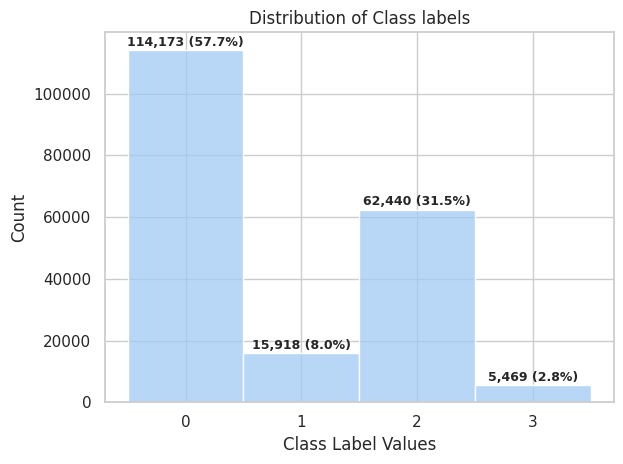

In [9]:
ax = sns.histplot(train_raw['label'], bins=4, discrete=True)

ax.set_xlabel('Class Label Values')
ax.set_ylabel('Count')
ax.set_title('Distribution of Class labels')

ax.set_xticks([0, 1, 2, 3])

# count and percentage labels on bars

total = len(train_raw['label'])

for p in ax.patches:
    height = p.get_height()
    pct = height / total * 100
    
    ax.annotate(f'{int(height):,} ({pct:.1f}%)',
                
                xy=(p.get_x() + p.get_width() / 2, p.get_height()),
                
                xytext=(0, 3),  
                
                textcoords="offset points",
                ha='center', fontsize=9, weight='bold')

plt.tight_layout()
plt.show()


 ### Insights : 

-  **Classes are greatly imbalanced,classes '0' and '2' account for almost 90% of labels, while class 3 is minority with just about 2.8% of the total samples**

#### Column validation check

In [10]:
# Simple column validaitons for train-test sets

print(train_raw.columns[:-1])
print(test_raw.columns)

print(train_raw.columns[:-1] == test_raw.columns)

Index(['created_date', 'post_id', 'emoticon_1', 'emoticon_2', 'emoticon_3',
       'upvote', 'downvote', 'if_1', 'if_2', 'race', 'religion', 'gender',
       'disability', 'comment'],
      dtype='object')
Index(['created_date', 'post_id', 'emoticon_1', 'emoticon_2', 'emoticon_3',
       'upvote', 'downvote', 'if_1', 'if_2', 'race', 'religion', 'gender',
       'disability', 'comment'],
      dtype='object')
[ True  True  True  True  True  True  True  True  True  True  True  True
  True  True]


#### Some Samples

In [11]:
train_raw.iloc[-25:-30:-1,::]

,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label
197975,2024-05-28 18:30:47.002353+00:00,118,0,0,0,0,0,0,10,NaN,NaN,NaN,False,The Kenyan gov. should take lessons from SA (t...,3
197974,2023-09-02 05:06:54.394056+00:00,71,0,0,0,0,0,4,6,none,none,none,False,The Trump campaign cp and his nascent presiden...,0
197973,2023-08-09 18:18:41.014877+00:00,31,0,0,0,2,0,0,10,NaN,NaN,NaN,False,Unemployed loser with nowhere to go and nothin...,2
197972,2022-12-26 03:50:38.654759+00:00,40,0,0,0,1,0,0,10,NaN,NaN,NaN,False,I don't understand how an 86 year old person h...,2
197971,2023-03-03 18:07:51.145825+00:00,31,0,0,0,0,0,0,4,NaN,NaN,NaN,False,It was 12..5 % when Obama took over and now ov...,0


#### More Samples to Inspect per label

In [12]:
df = train_raw.copy()

#### Label '0' Samples 

In [13]:
df.loc[df["label"] == 0].head()

,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label
1,2024-03-24 21:43:11.490017+00:00,39,0,0,0,6,0,0,4,NaN,NaN,NaN,False,"Under Alaska law, a non-tribal member is not b...",0
5,2024-04-06 20:10:59.141468+00:00,39,0,0,0,0,0,0,4,NaN,NaN,NaN,False,"Hilarious. Since it wasn't Trump, and that yaw...",0
6,2024-03-04 03:02:55.849172+00:00,72,0,0,0,0,0,0,4,NaN,NaN,NaN,False,Here's an Idea\nState Owned Foreign Companies ...,0
7,2023-10-14 20:57:30.208573+00:00,72,0,0,0,1,1,0,4,NaN,NaN,NaN,False,Victims' participation in the criminla justice...,0
8,2024-02-24 12:13:22.166045+00:00,71,0,0,0,0,0,6,6,none,christian,none,False,I wonder what our ancestors would say when the...,0


- **if_2 column value 4/6 is safe for class 0 , class '0' seems to be for normal comments**

#### Label '1' only samples

In [14]:
df.loc[df["label"] == 1].head()

,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label
10,2023-12-26 01:06:22.590457+00:00,120,0,0,0,1,0,4,10,none,muslim,none,False,You're right the words Muslim ban came straigh...,1
35,2023-03-25 21:55:31.313000+00:00,31,0,0,0,1,0,10,10,white,none,female,False,Why do I get the suspicion that this is a libe...,1
41,2023-12-25 23:59:20.491151+00:00,72,0,0,0,0,0,4,10,none,none,female,False,You have missed my point. I will type slow so ...,1
44,2024-01-20 15:50:17.541361+00:00,72,0,0,0,0,0,4,10,none,muslim,none,False,500 years from now Muslims will still be seeki...,1
52,2024-05-27 04:31:29.212088+00:00,72,0,0,0,0,0,0,10,NaN,NaN,NaN,False,I agree; I unhesitatingly heap scorn on the de...,1


- **Class 1 seems to be for aggresive/ hate speech or racial comments, if_1 column has non-zero values here**

#### Label '2' only Samples

In [15]:
df.loc[df["label"] == 2].head()

,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label
0,2024-01-18 08:43:57.397508+00:00,73,0,0,0,0,1,0,10,NaN,NaN,NaN,False,She might be a bright spot for a party keou on...,2
2,2024-04-24 20:32:17.014931+00:00,31,0,1,1,0,0,0,10,NaN,NaN,NaN,False,in the future please spare me your strawman dr...,2
3,2023-05-28 22:00:14.214527+00:00,39,0,0,0,5,0,0,10,NaN,NaN,NaN,False,"PS: That should have been ""rot"" instead of ""co...",2
4,2023-09-09 23:12:05.689498+00:00,39,0,0,0,0,0,0,10,NaN,NaN,NaN,False,"Today, the confederate flag...tomorrow, the na...",2
11,2024-01-16 05:15:49.788066+00:00,72,0,0,0,0,0,0,10,NaN,NaN,NaN,False,"relax lunatics, we are dealing with a leader w...",2


- **Class 2 comments feel positive overall, have high if_2 values**

#### Label '3' only smaples

In [16]:
df.loc[df["label"] == 3].head()

,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label
40,2023-02-16 03:05:21.745646+00:00,39,0,0,0,10,0,0,10,NaN,NaN,NaN,False,"Now that I poisoned the pond, I am not going t...",3
45,2023-04-05 04:38:07.431855+00:00,39,0,0,0,2,0,0,10,NaN,NaN,NaN,False,This is a city tragedy. \n\nAnd I am going to ...,3
49,2024-04-05 07:22:54.029743+00:00,73,0,1,1,2,1,0,10,NaN,NaN,NaN,False,A precedent must be set : Any nation breaking ...,3
106,2024-06-02 03:16:39.659332+00:00,120,0,0,0,1,0,4,10,none,none,none,False,nothing happening here that can't be solved wi...,3
135,2023-06-09 12:30:06.435160+00:00,39,0,0,0,7,0,0,10,NaN,NaN,NaN,False,So true!\n\nBut I doubt she has the ability an...,3


- **Class 3 seems like offensive / deep hate comments , if_1 is also non zero for some comments**

#### Inspecting full comments from the tail to get clarity : 

In [17]:
#display(df[['comment','label']].tail(11))

print("Samples from tail")
print("-" * 60)

for row in df[['comment', 'label']].tail(11).itertuples():
    print("Class:", row.label)
    print(row.comment)
    print("-" * 60)

Samples from tail
------------------------------------------------------------
Class: 2
Ok, so you are rural, and less exposed to the real world.. I withdraw the religious comment.

And calling someone a potato is not asinine?

Pot.Kettle.Black.
------------------------------------------------------------
Class: 0
When is the next plane to Cairo
------------------------------------------------------------
Class: 0
Why not simply have Connelly send over press releases and fire Kosmider? Not a single question about that fiasco of a draft last night? Just a rambling chat about the painfully obvious fact the Nuggets need to get better on defense? The Nuggets chances of making hycf the playoffs took a huge hit last night. None of the teams above them looks to be significantly weaker (other than the possibility of the Clippers blowing things up). At least three of the teams that joined the Nuggets in the bottom half of the bracket will be serious contenders for a playoff spot this season. On

### Insights :
---
#### 1. Looking closely at the if_2 column across the classes:

 - Class 1 (Hate/Identity): 10, 10, 10, 10, 10

 - Class 2 (Toxicity/Insult): 10, 10, 10, 10, 10

 - Class 3 (Threats/Extreme): 10, 10, 10, 10, 10

 - Class 0 (Normal):  4, 4, 4, 4, 6

if_2 is probably a useful system flag. It appears that if a comment is flagged for any type of toxicity (Classes 1, 2, 3), the system assigns if_2 = 10. If if_2 != 10, it is almost guaranteed to be Class 0.

#### 2. Looking at the race, religion, and gender columns:

 - Class 1 Examples: explicitly mention black, muslim, white, female. The text aligns perfectly: "black kids", "Muslim ban", "white... liberal".

 - Class 3 Examples: Almost all demographic columns are NaN or none. The text is action-oriented violence: "starve them", "poisoned the pond", "solved with a [weapon]".

Thus Class 1 is probaly based on Identity Hate. Class 3 is maybe Violent Threats.

#### 3.  The platform handles missing demographics inconsistantly, 

- Sometimes it is NaN (null).

- Sometimes it is literally the string 'none'.
  
Inference :  Looking from the platform's perspective, a user who explicitly clicks or selects "none" in a profile or report is behaving differently than a user who leaves it blank (NaN). Grouping them together destroys pattern. So should treat 'none' as its own specific categorical behavior.

## 3.2 Statistical Tests

In [18]:
df.describe()

,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,label
count,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000
mean,68.447429,0.279768,0.048338,0.121071,2.607975,0.666394,1.906152,7.956212,0.793965
std,27.948390,1.023234,0.258477,0.481013,5.054763,2.044335,25.635752,14.839464,0.979808
min,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,0.000000
25%,39.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,0.000000
50%,72.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,6.000000,0.000000
75%,72.000000,0.000000,0.000000,0.000000,3.000000,1.000000,4.000000,10.000000,2.000000
max,129.000000,47.000000,11.000000,17.000000,201.000000,107.000000,1860.000000,1833.000000,3.000000


#### Insights : 

- Some large amount of emojis in  max values for emoticon 1 (47 emojis), rare outlier.

- upvote average only ~2–3, many zeros, long tail till 201, so log scale seems good for this feature.

- downvote mostly 0 also, but negatives signal, so useful feature after log.

- if_1 huge std and max 1860, very unstable counts, so scale or clip.

- if_2 also wide spread, but less extreme, still normalize.

- label ranges 0–3, multi-class problem, also data looks imbalanced since median label is 0.

- overall numeric columns very skewed, so model may focus on zeros.

- real signal will mainly come from the comment text, metadata only supportive.

In [19]:
from scipy.stats import kruskal, chi2_contingency

numeric_test_features = ['upvote', 'downvote', 'if_1', 'if_2',
                         'emoticon_1', 'emoticon_2', 'emoticon_3']
numeric_test_features = [f for f in numeric_test_features if f in train_raw.columns]

print(f'{'Feature':20s}  {'H-statistic':>12s}  {'p-value':>12s}  Verdict')
print('-' * 70)

for feat in numeric_test_features:
    
    groups = [train_raw.loc[train_raw['label'] == c, feat].dropna().values for c in range(4)]
    
    h_stat, p_val = kruskal(*groups)
    
    verdict = 'SIGNIFICANT (p<0.001)' if p_val < 0.001 else 'not significant'
    
    print(f'  {feat:18s}  {h_stat:12.1f}  {p_val:12.2e}  {verdict}')

# Chi-squared for disability
print()
print(f'{'Feature':20s}  {'H-statistic':>12s}  {'p-value':>12s}  Verdict')

print('-' * 70)

for feat in ['disability']:

    if feat in train_raw.columns:
        
        ct = pd.crosstab(train_raw[feat], train_raw['label'])
        chi2, p_val, _, _ = chi2_contingency(ct)
        verdict = 'SIGNIFICANT (p<0.001)' if p_val < 0.001 else 'not significant'
        
        print(f'  {feat}  {chi2:12.1f}  {p_val:12.2e}  {verdict}')


Feature                H-statistic       p-value  Verdict
----------------------------------------------------------------------
  upvote                     600.5     7.98e-130  SIGNIFICANT (p<0.001)
  downvote                  1102.0     1.35e-238  SIGNIFICANT (p<0.001)
  if_1                     29686.4      0.00e+00  SIGNIFICANT (p<0.001)
  if_2                    146132.8      0.00e+00  SIGNIFICANT (p<0.001)
  emoticon_1                  28.8      2.43e-06  SIGNIFICANT (p<0.001)
  emoticon_2                 147.7      8.27e-32  SIGNIFICANT (p<0.001)
  emoticon_3                 262.6      1.20e-56  SIGNIFICANT (p<0.001)

Feature                H-statistic       p-value  Verdict
----------------------------------------------------------------------
  disability         857.6     1.42e-185  SIGNIFICANT (p<0.001)


### Insight :  All Platform Features are Strongly Significant

The H-statistics for `if_2` and `if_1` exceed 20,000 :  this is an extraordinarily strong signal, meaning these features alone provide non-random class separation. For comparison, emoticon features have H-statistics in the hundreds, which is still significant but far weaker.

This statistical evidence validates why `if_1` and `if_2` interaction features (`if_prod`, `if_ratio`, `zone_safe`) become the highest-importance features in our LightGBM model.

## 3.3 Variable Analysis

In [20]:
train_raw.columns


Index(['created_date', 'post_id', 'emoticon_1', 'emoticon_2', 'emoticon_3',
       'upvote', 'downvote', 'if_1', 'if_2', 'race', 'religion', 'gender',
       'disability', 'comment', 'label'],
      dtype='object')

<Axes: >

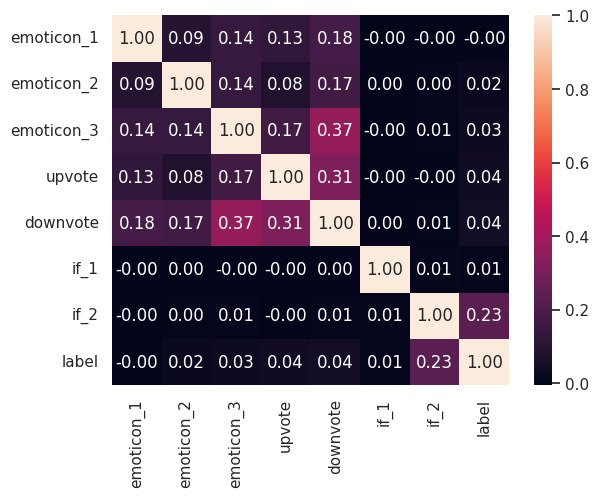

In [21]:
# NUmerical correl

numeric_df = train_raw.select_dtypes(include='number')

numeric_df = numeric_df.drop(columns=['post_id'])

corr_matrix = numeric_df.corr()

sns.heatmap(corr_matrix, annot=True, fmt=".2f")

In [22]:
cat_cols = ['race', 'religion', 'gender', 'disability']

for col in cat_cols:
    print(f"\n ____{col} vs label____ ")
    print(pd.crosstab(train_raw[col], train_raw['label'], normalize='index'))


 ____race vs label____ 
label          0         1         2         3
race                                          
asian   0.451306  0.288203  0.241489  0.019002
black   0.157147  0.692427  0.143448  0.006979
latino  0.439807  0.321027  0.229535  0.009631
none    0.519278  0.154680  0.301724  0.024318
other   0.408706  0.295647  0.273881  0.021765
white   0.168246  0.608458  0.212359  0.010937

 ____religion vs label____ 
label             0         1         2         3
religion                                         
atheist    0.388128  0.324201  0.260274  0.027397
buddhist   0.430000  0.390000  0.170000  0.010000
christian  0.481157  0.300375  0.208316  0.010152
hindu      0.515464  0.298969  0.175258  0.010309
jewish     0.279743  0.540997  0.168810  0.010450
muslim     0.195740  0.635700  0.148479  0.020081
none       0.484300  0.179952  0.311851  0.023896
other      0.332724  0.400366  0.246801  0.020110

 ____gender vs label____ 
label               0         1         2  

- Strongest predictive features: disability (very strong separation), followed by race and religion; gender is comparatively weak but still usable.

#### Clear class patterns:

- disability=True implies label 2 might be present, weak correlation

- race (black/white) gives label 1 dominant, none indicates fair presence of class '0'

- religion (muslim/jewish) indicates label 1 again, with weak indication for '0' when none



#### Outliers and Char/Word Distributions per Class


Total Outliers Found: 9900


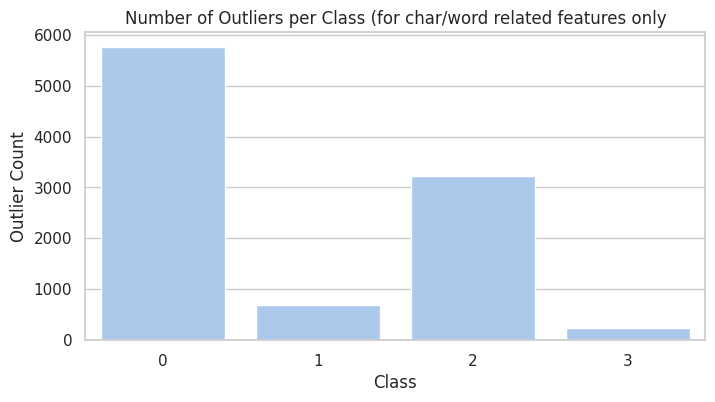

In [23]:
from sklearn.ensemble import IsolationForest

# useful text-based features
data = train_raw.copy()   

data['char_count'] = data['comment'].astype(str).apply(len)
data['word_count'] = data['comment'].astype(str).apply(lambda x: len(x.split()))

data['avg_word_len'] = data['char_count'] / (data['word_count'] + 1)

data['exclamation_count'] = data['comment'].astype(str).str.count('!')
data['uppercase_ratio'] = data['comment'].astype(str).apply(
    lambda x: sum(1 for c in x if c.isupper()) / (len(x) + 1)
)

# features for outlier detection
features = [
    'char_count',
    'word_count',
    'avg_word_len',
    'exclamation_count',
    'uppercase_ratio'
]

X = data[features]

# outliers detection using Isolation Forest

iso = IsolationForest(
    contamination=0.05,   # assume ~5% outliers
    random_state=42
)

data['outlier_flag'] = iso.fit_predict(X)

# creating a flag for outliers 1/-1

outliers_df = data[data['outlier_flag'] == -1].copy()

print(f"Total Outliers Found: {len(outliers_df)}")

# ONLY outliers across classes

plt.figure(figsize=(8,4))
sns.countplot(data=outliers_df, x='label')
plt.title("Number of Outliers per Class (for char/word related features only")
plt.xlabel("Class")
plt.ylabel("Outlier Count")
plt.show()


#### Insight :

Outliers were never removed and are kept as it is as they are important cases of valid comments per class, dropping them lead to a slight drop in per classs f1 score, thus, the outliers are kept as it is, also our Tree-based models like LightGBM handle outliers well, and there are some nuances worth understanding.

Also we already clean text extensively later to clear up useless symbols and useless comments 

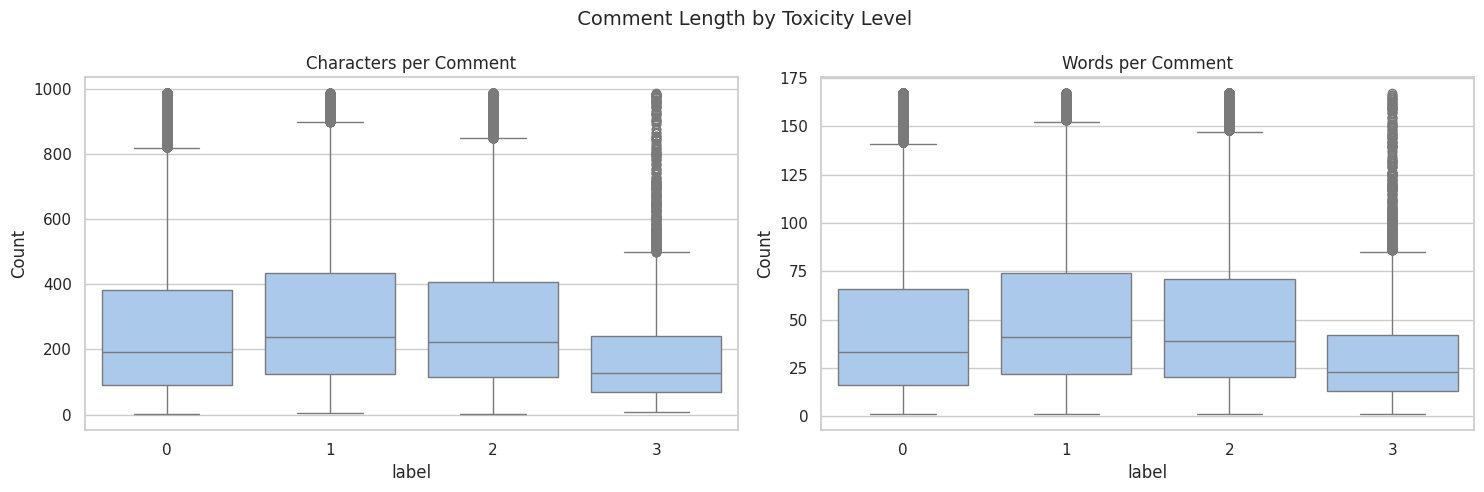

In [24]:

# creating length columns 
train_raw['char_count'] = train_raw['comment'].astype(str).str.len()
train_raw['word_count'] = train_raw['comment'].astype(str).str.split().str.len()

# outliers removal for clean view
char_data = train_raw[train_raw['char_count'] < train_raw['char_count'].quantile(0.97)]
word_data = train_raw[train_raw['word_count'] < train_raw['word_count'].quantile(0.97)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(data=char_data, x='label', y='char_count', ax=ax1)
sns.boxplot(data=word_data, x='label', y='word_count', ax=ax2)

ax1.set_title('Characters per Comment')
ax2.set_title('Words per Comment')
ax1.set_ylabel('Count')
ax2.set_ylabel('Count')

ax1.set_xticklabels(['0', '1', '2', '3'])
ax2.set_xticklabels(['0', '1', '2', '3'])

plt.suptitle(' Comment Length by Toxicity Level', fontsize=14)
plt.tight_layout()
plt.show()

# Cleanup
train_raw.drop(['char_count', 'word_count'], axis=1, inplace=True)


###  'Comment' Visualisation on Train.Test Copies

In [25]:
train_copy = pd.read_csv(train_set_path)[:-1]

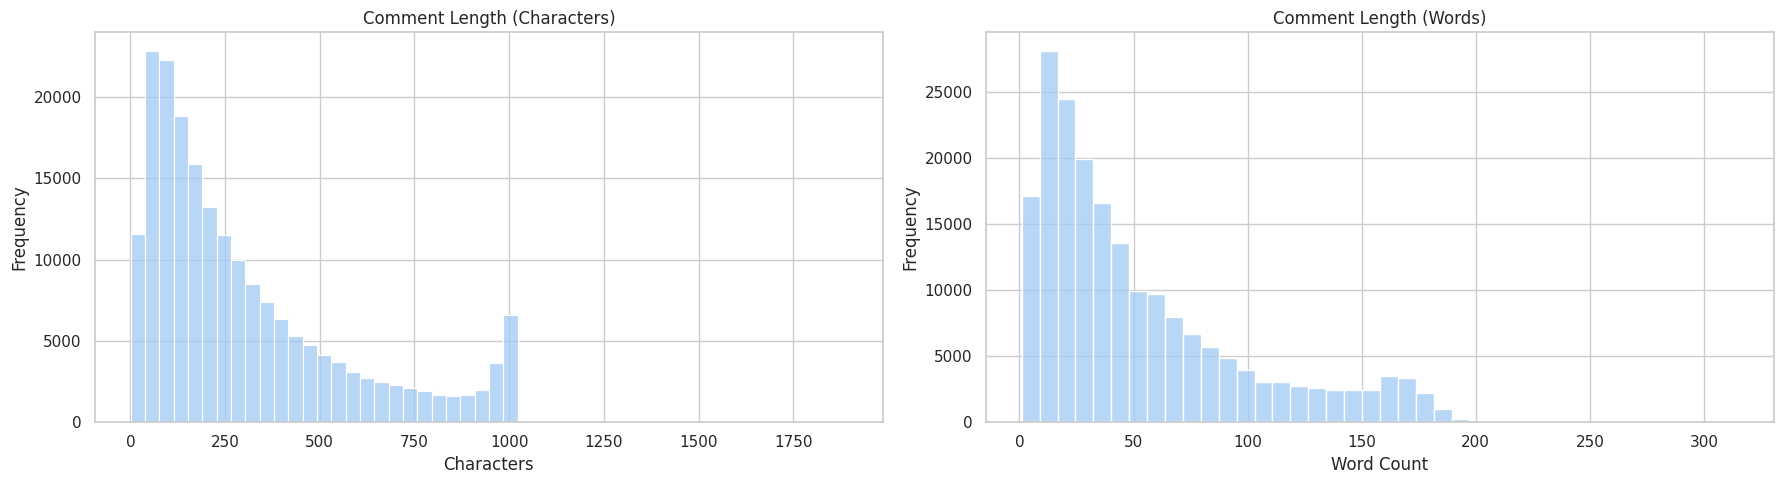

In [26]:
# ensure string
train_copy["comment"] = train_copy["comment"].astype(str)

# text features
train_copy["char_len"] = train_copy["comment"].str.len()
train_copy["word_len"] = train_copy["comment"].str.split().apply(len)

fig, axes = plt.subplots(1, 2, figsize=(18,5))

# 1. Character length distribution
sns.histplot(train_copy["char_len"], bins=50, ax=axes[0], palette="Set2")
axes[0].set_title("Comment Length (Characters)")
axes[0].set_xlabel("Characters")
axes[0].set_ylabel("Frequency")

# 2. Word count distribution
sns.histplot(train_copy["word_len"], bins=40, ax=axes[1])
axes[1].set_title("Comment Length (Words)")
axes[1].set_xlabel("Word Count")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

- **Right-skewed comment length distribution:** Most comments are short (roughly 50–400 characters or 5–60 words) with a long tail of very long comments, indicating the dataset is dominated by brief comments, typical of conversational data and platforms.

- A visible spike around ~1000 characters suggests some comments may have been clipped at a maximum length.


### Categorical Vairables


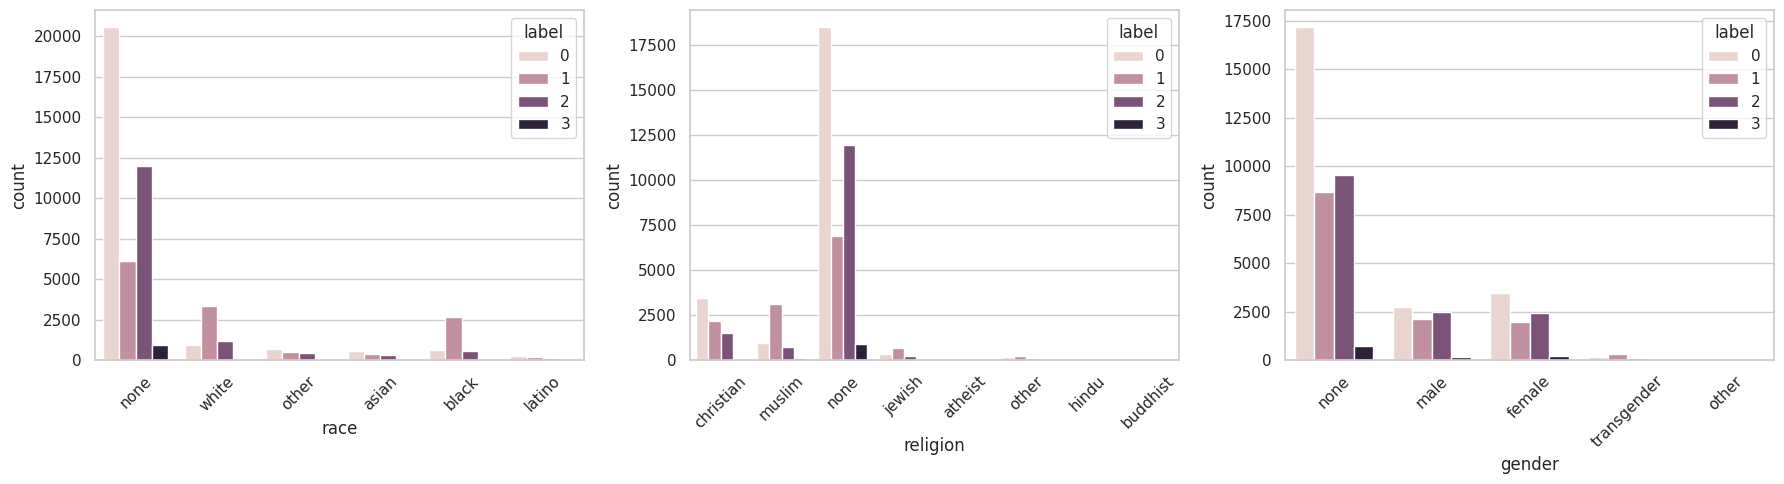

In [27]:

# 3. Demographics vs Label (only non-null rows)
demo_cols = ['race', 'religion', 'gender']
subset = train_raw.dropna(subset=demo_cols)

fig, axes = plt.subplots(1,3,figsize=(18,5))
for i, col in enumerate(demo_cols):
    sns.countplot(data=subset, x=col, hue='label', ax=axes[i])
    axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()


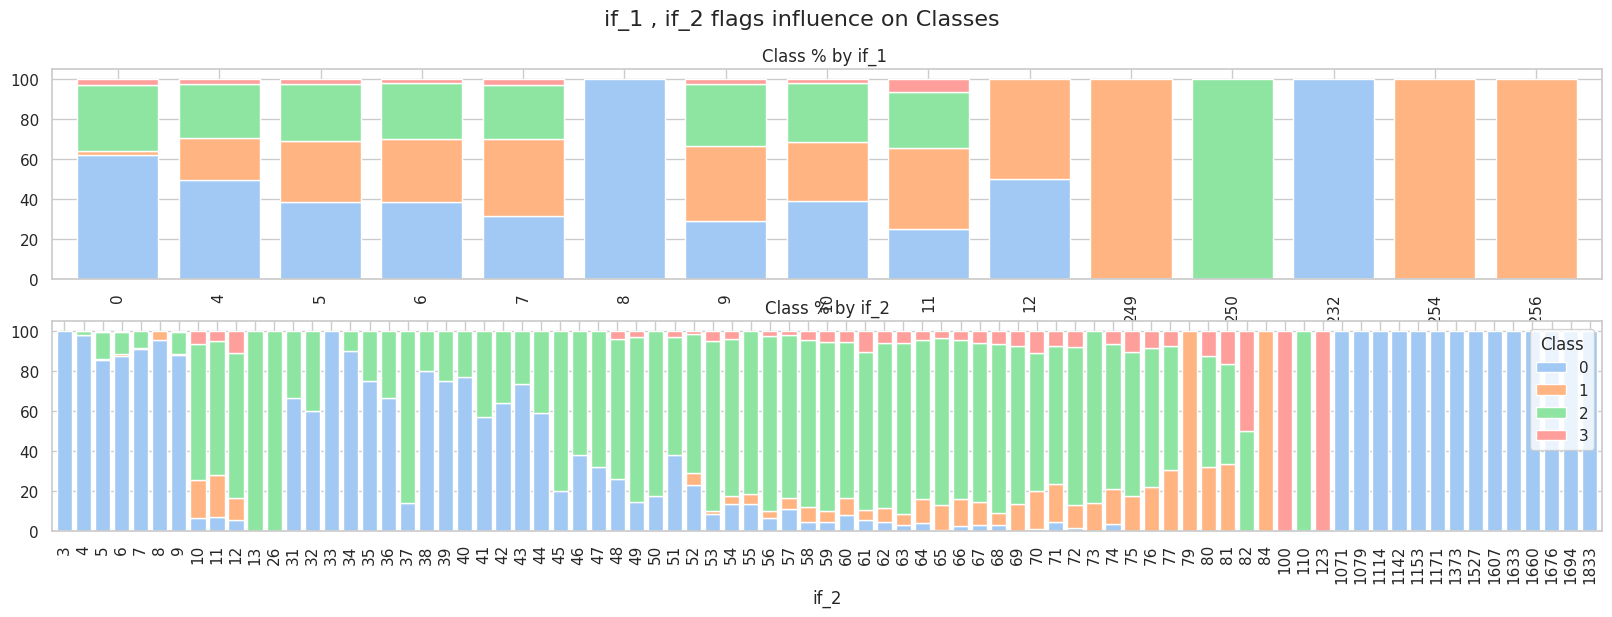

In [28]:
class_pct_if1 = train_raw.groupby(['if_1', 'label']).size().unstack(fill_value=0)
class_pct_if1 = class_pct_if1.div(class_pct_if1.sum(axis=1), axis=0) * 100  # Normalize to 100%

class_pct_if2 = train_raw.groupby(['if_2', 'label']).size().unstack(fill_value=0)
class_pct_if2 = class_pct_if2.div(class_pct_if2.sum(axis=1), axis=0) * 100  # Normalize to 100%

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 6))

# if_1
class_pct_if1.iloc[:15].plot(
    kind='bar',
    stacked=True,
    ax=ax1,
    width=0.8,
 
)

ax1.set_title('Class % by if_1 ')
ax1.legend(title='Class').remove()

# if_2
class_pct_if2.plot(
    kind='bar',
    stacked=True,
    ax=ax2,
    width=0.8,
)

ax2.set_title('Class % by if_2')
ax2.legend(title='Class')

plt.suptitle('if_1 , if_2 flags influence on Classes', fontsize=16)
plt.show()

### Insight:
---

`if_2` Threshold Rule

- **`if_2 ≤ 7` usually Class 0 (Normal)**  
  Works almost always (~99%)

- **`if_2 ≥ 8` usually Toxic classes (1, 2, 3)**  
  Strong signal (~95%)

- **Refinement when `if_2 ≥ 8`:**
  - `if_1 ∈ {4, 6, 10}` implies Likely **Class 1 (Offensive)** (~70%)
  - `if_1 = 0` implies Likely **Class 2 or 3** (~80%)


### Key Takeaway

`if_2` behaves like a **primary class flag**, and `if_1` helps split subtypes of those classes.

### EMOTICON AND UPVOTE/DOWNVOTE BY CALSS

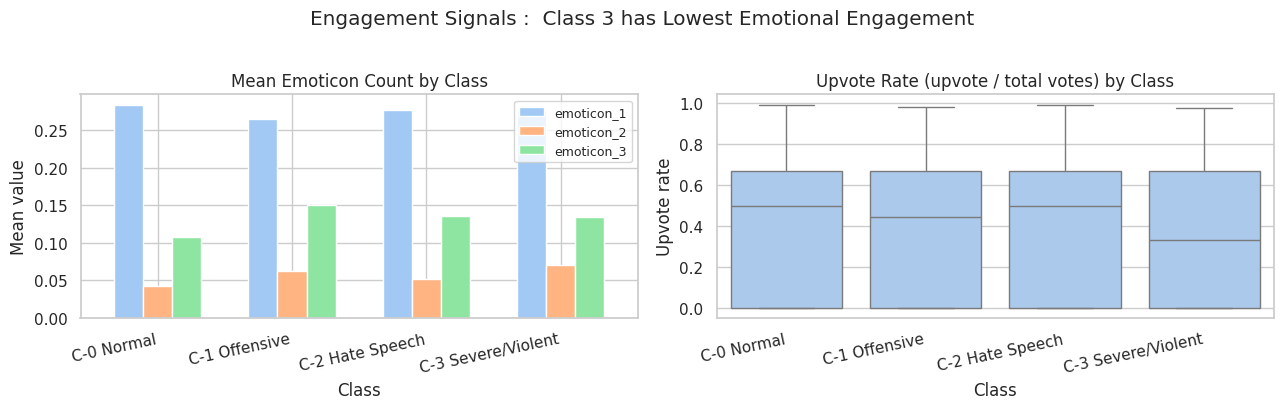

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Emoticon usage per class
emo_means = train_raw.groupby('label')[['emoticon_1', 'emoticon_2', 'emoticon_3']].mean()
emo_means.plot(kind='bar', ax=axes[0], edgecolor='white',
               width=0.65, rot=0)
axes[0].set_title('Mean Emoticon Count by Class')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Mean value')
axes[0].set_xticklabels(CLASS_LABELS, rotation=12, ha='right')
axes[0].legend(['emoticon_1', 'emoticon_2', 'emoticon_3'], fontsize=9)

# Vote ratio per class
vote_data = train_raw.copy()
vote_data['upvote_rate'] = vote_data['upvote'] / (vote_data['upvote'] + vote_data['downvote'] + 1)
sns.boxplot(
    data=vote_data,
    x='label',
    y='upvote_rate',
    showfliers=False,
    ax=axes[1]
)
axes[1].set_title('Upvote Rate (upvote / total votes) by Class')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Upvote rate')
axes[1].set_xticklabels(CLASS_LABELS, rotation=12, ha='right')

plt.suptitle('Engagement Signals :  Class 3 has Lowest Emotional Engagement', y=1.02)
plt.tight_layout()
plt.show()


### Emoticon Insights :
 
- **emoticon_2 and emoticon_3 show higher means for Class 1 and Class 3** (offensive/violent) compared to Class 0 (normal), meaning users expressing toxicity tend to use specific emoticon types more.
- **Overall emoticon usage rates are similar across classes (~40-45%)**, so the emoticons dont seem liek valuable features
- COuld try keeping individual emoticon columns rather than collapsing them into a single `has_emo` flag.


## 3.4 Word Frequency Analysis :  Top Words per Class

We look at the most common words in each class after basic cleaning, using a minimal manual stopword list (no external NLP libraries allowed). The differences are stark and justify the violence lexicon we build in Feature Engineering.

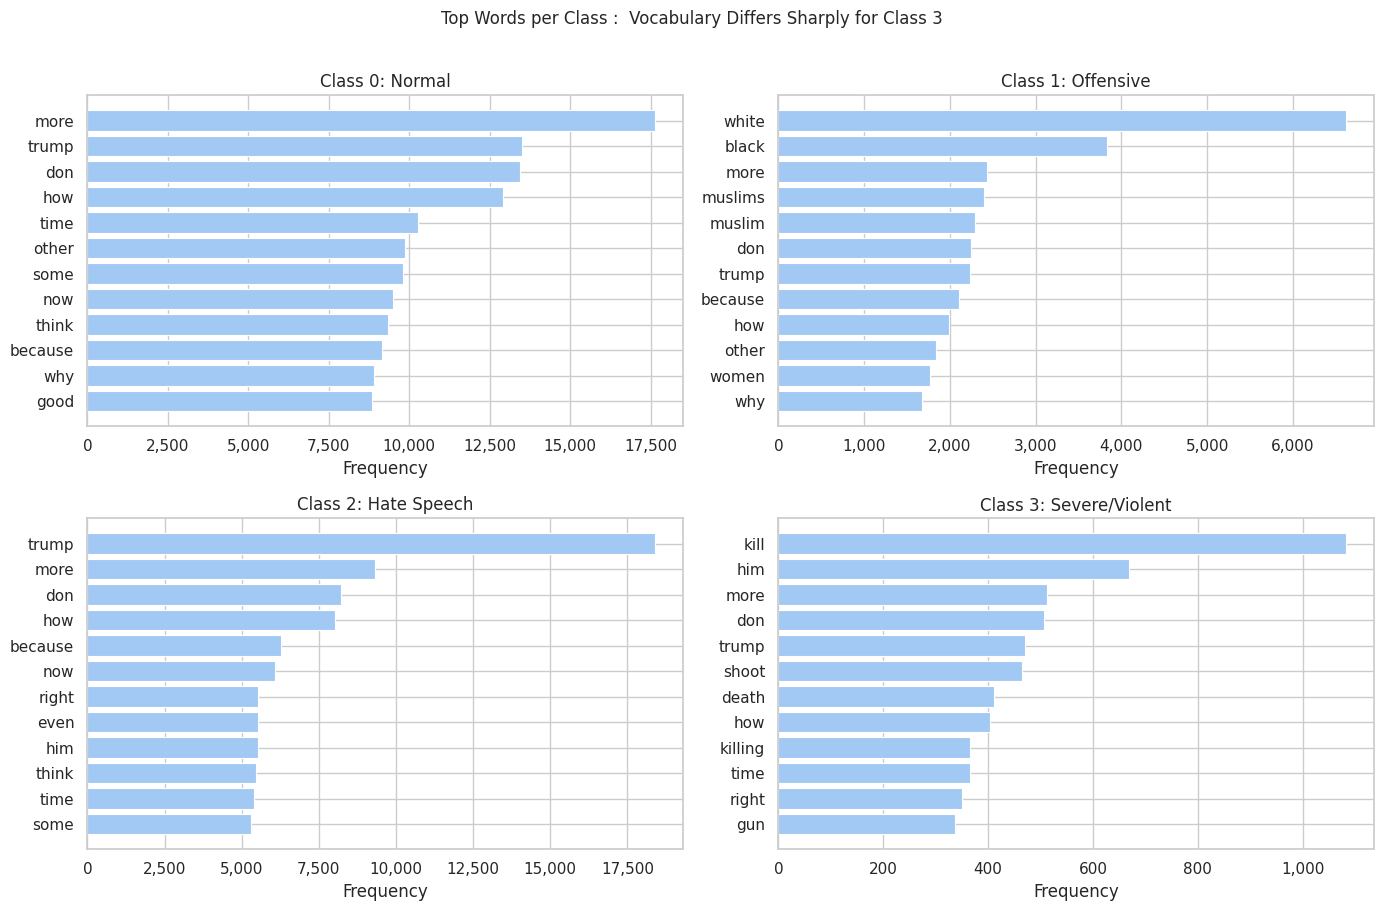

In [30]:
# Minimal stop words (no NLTK dependency)
STOP_WORDS = {
    'the','a','an','and','or','but','is','are','was','were','be','been',
    'being','have','has','had','do','does','did','will','would','could',
    'should','may','might','can','to','of','in','for','on','with','at',
    'by','from','as','this','that','it','he','she','they','we','you','i',
    'not','so','if','its','their','his','her','our','all','one','just',
    'also','about','up','out','my','your','no','like','get','know', 'what','which', 'when' , 'where' ,'why' 'how' , 'that' , 'those', 'them',
    'who', 'there' , 'here' , 'any' , 'many' , 'only' ,'than' , 'then' , 'these','people'}

def get_top_words(label_id, top_n=12):
    
    comments = train_raw.loc[train_raw['label'] == label_id, 'comment']
    comments = comments.fillna('').astype(str).str.lower()
    comments = comments.str.replace(r'[^a-z\s]', ' ', regex=True)
    all_words = []
    for text in comments:
        all_words.extend([w for w in text.split() if w not in STOP_WORDS and len(w) > 2])
    counter = Counter(all_words)
    return counter.most_common(top_n)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

def format_xtick(x, pos):
    return f'{int(x):,}'

for cls_id, ax in zip(range(4), axes.ravel()):
    top = get_top_words(cls_id)
    words  = [w for w, _ in top]
    counts = [c for _, c in top]

    bars = ax.barh(words[::-1], counts[::-1],
                   edgecolor='white', linewidth=0.8)
    ax.set_title(f'Class {cls_id}: {CLASS_NAMES[cls_id]}')
    ax.set_xlabel('Frequency')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(format_xtick))

plt.suptitle('Top Words per Class :  Vocabulary Differs Sharply for Class 3', y=1.01, fontsize=12)
plt.tight_layout()
plt.show()


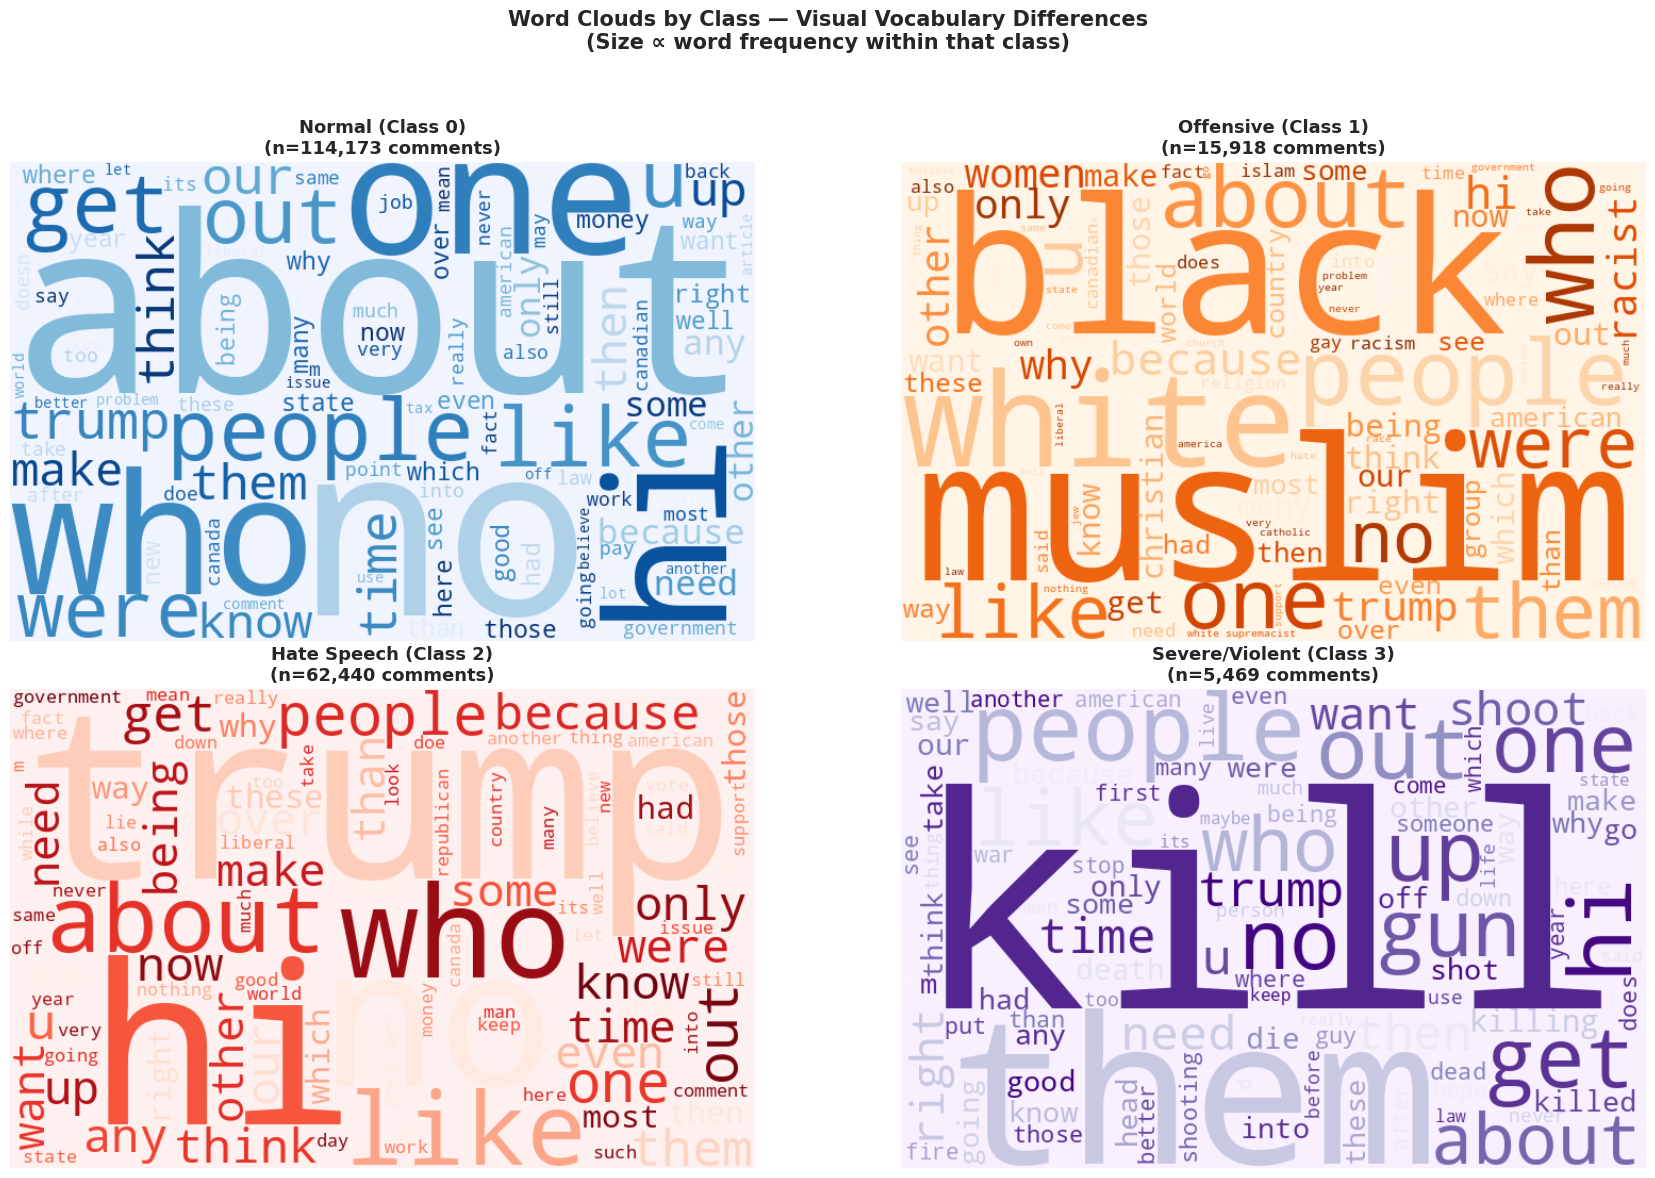

In [31]:


# if wordcloud not available, just skip this cell
from wordcloud import WordCloud

CLASS_NAMES_WC = {0: 'Normal (Class 0)', 1: 'Offensive (Class 1)',
                  2: 'Hate Speech (Class 2)', 3: 'Severe/Violent (Class 3)'}
COLORMAPS      = {0: 'Blues', 1: 'Oranges', 2: 'Reds', 3: 'Purples'}
BG_COLORS      = {0: '#F0F4FF', 1: '#FFF4E6', 2: '#FFF0F0', 3: '#F8F0FF'}

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Word Clouds by Class — Visual Vocabulary Differences\n'
             '(Size ∝ word frequency within that class)',
             fontsize=15, fontweight='bold')

# Quick clean for word cloud (no deep pipeline needed here)
def wc_clean(text):
    text = str(text).lower()
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    return text

stop_w = {'the','a','an','is','it','in','of','to','and','for','on','with',
         'at','by','from','this','that','was','are','be','or','as','not',
         'i','you','he','she','they','we','me','my','your','he','him','her',
         'but','so','if','do','did','have','has','been','will','can','would',
         'could','should','there','their','they','what','when','how','just',
         'all','more','s','t','re','ve','ll','don'}

for cls, ax in enumerate(axes.ravel()):
    subset = train_raw[train_raw['label'] == cls]['comment']
    n_sample = min(4000, len(subset))
    text_corpus = ' '.join(subset.sample(n=n_sample, random_state=SEED).apply(wc_clean).values)

    wc = WordCloud(
        width=700, height=450,
        background_color=BG_COLORS[cls],
        colormap=COLORMAPS[cls],
        max_words=100,
        stopwords=stop_w,
        prefer_horizontal=0.85,
        min_font_size=8
    ).generate(text_corpus)

    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'{CLASS_NAMES_WC[cls]}\n(n={len(subset):,} comments)',
                 fontsize=13, fontweight='bold')
    ax.axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()



- **Class 0 (Normal)** is dominated by generic conversational words ("people", "like", " donald trump", "think") typical discussion vocabulary with no offensive signal.
- **Class 1 (Offensive)** shows identity-related terms rising to the top ("white", "black", "women", "muslims") consistent with identity-based hate speech or rqacial comments.
- **Class 2** shows no significantly unique words
- **Class 3 (Violent)** surfaces action-oriented violent terms ("kill", "die", "dead", "shot") at much higher relative frequency than other classes — this directly validates our `violence_count` and `VIOLENCE` wordlist in the FeatureEngineer.

- These class-specific vocabulary patterns confirm that TF-IDF with sufficient n-gram range can capture discriminative lexical signals, and that our hand-crafted sentiment/violence wordlists target the right vocabulary.

- Also most comments seem to be revolving around donald trump and his actions/plotical life etc , and typical mindset od US citizens, suggesting hte data was picked up maybe from  US based political reddit server or something :)
  


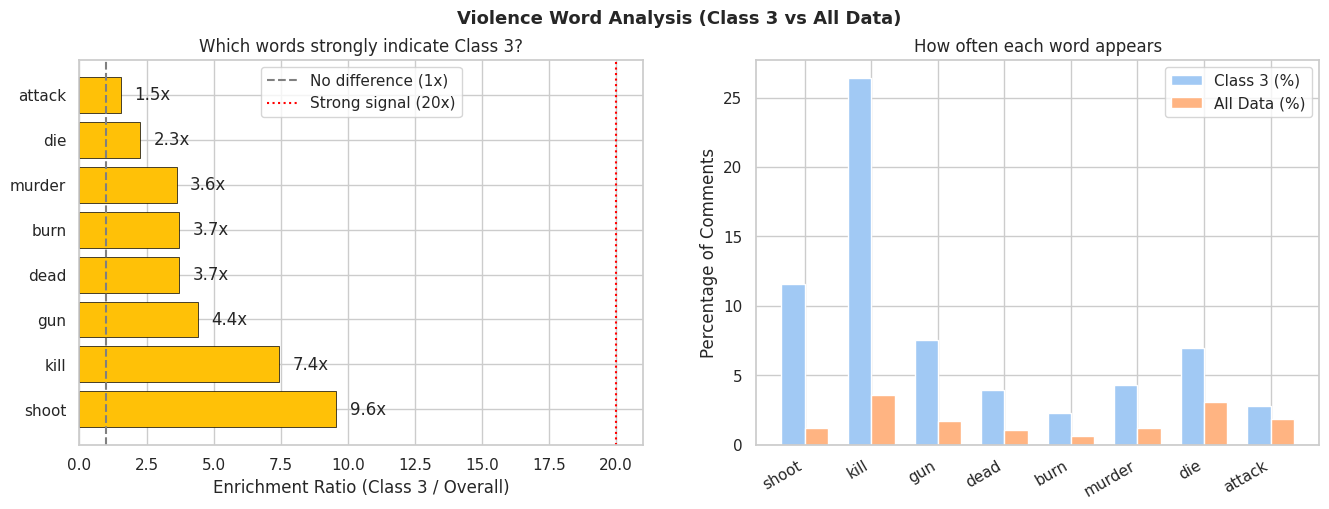


Summary:
shoot      | Class3: 11.59% | Overall: 1.21% | Ratio: 9.6x
kill       | Class3: 26.40% | Overall: 3.55% | Ratio: 7.4x
gun        | Class3: 7.57% | Overall: 1.72% | Ratio: 4.4x
dead       | Class3: 3.95% | Overall: 1.06% | Ratio: 3.7x
burn       | Class3: 2.27% | Overall: 0.61% | Ratio: 3.7x
murder     | Class3: 4.33% | Overall: 1.20% | Ratio: 3.6x
die        | Class3: 6.93% | Overall: 3.06% | Ratio: 2.3x
attack     | Class3: 2.82% | Overall: 1.82% | Ratio: 1.5x


In [32]:

violence_keywords = ['kill', 'shoot', 'die', 'dead', 'murder', 'attack', 'gun', 'burn']

all_comments = train_raw['comment'].fillna('').astype(str).str.lower()

# Only class 3 comments
class3_comments = train_raw.loc[
    train_raw['label'] == 3, 'comment'
].fillna('').astype(str).str.lower()

word_enrichment_ratio = {}
class3_frequency = {}
overall_frequency = {}

for word in violence_keywords:
    # % of comments containing this word
    class3_rate = class3_comments.str.contains(word, regex=False).mean()
    overall_rate = all_comments.str.contains(word, regex=False).mean()
    
    # Avoid division by zero
    enrichment_ratio = class3_rate / max(overall_rate, 1e-6)
    
    # Store results
    word_enrichment_ratio[word] = enrichment_ratio
    class3_frequency[word] = class3_rate
    overall_frequency[word] = overall_rate

# Sort words by importance (simple function instead of lambda)
def get_enrichment(w):
    return word_enrichment_ratio[w]

sorted_words = sorted(
    word_enrichment_ratio,
    key=get_enrichment,
    reverse=True
)

enrichment_values = []
for w in sorted_words:
    enrichment_values.append(word_enrichment_ratio[w])

bar_colors = []
for val in enrichment_values:
    if val > 20:
        bar_colors.append('#E53935')   # very strong 
    elif val > 10:
        bar_colors.append('#FF9800')   # medium 
    else:
        bar_colors.append('#FFC107')   # weak 

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

fig.suptitle(
    'Violence Word Analysis (Class 3 vs All Data)',
    fontsize=13,
    fontweight='bold'
)

#  Enrichment Ratio Plot
bars = ax1.barh(
    sorted_words,
    enrichment_values,
    color=bar_colors,
    edgecolor='black',
    linewidth=0.5
)

ax1.set_xlabel('Enrichment Ratio (Class 3 / Overall)')
ax1.set_title('Which words strongly indicate Class 3?')

# Reference lines
ax1.axvline(1, linestyle='--', color='gray', label='No difference (1x)')
ax1.axvline(20, linestyle=':', color='red', label='Strong signal (20x)')

for bar, val in zip(bars, enrichment_values):
    ax1.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height()/2,
        f'{val:.1f}x',
        va='center'
    )

ax1.legend()

#  Raw Frequency Comparison
x_positions = np.arange(len(sorted_words))
bar_width = 0.35

ax2.bar(
    x_positions - bar_width/2,
    [class3_frequency[w]*100 for w in sorted_words],
    bar_width,
    label='Class 3 (%)'
)

ax2.bar(
    x_positions + bar_width/2,
    [overall_frequency[w]*100 for w in sorted_words],
    bar_width,
    label='All Data (%)'
)

ax2.set_xticks(x_positions)
ax2.set_xticklabels(sorted_words, rotation=30, ha='right')

ax2.set_ylabel('Percentage of Comments')
ax2.set_title('How often each word appears')

ax2.legend()

plt.show()

print("\nSummary:")
for word in sorted_words:
    print(
        f"{word:10s} | Class3: {class3_frequency[word]*100:.2f}% "
        f"| Overall: {overall_frequency[word]*100:.2f}% "
        f"| Ratio: {word_enrichment_ratio[word]:.1f}x"
    )

### Unique Insight: Violence Word Enrichment Quantification

#### Enrichment Summary

- **shoot**   : Class3 = 11.59% | All = 1.212% | **Ratio = 9.6×**
- **kill**    : Class3 = 26.40% | All = 3.554% | **Ratio = 7.4×**
- **gun**     : Class3 = 7.57%  | All = 1.721% | **Ratio = 4.4×**
- **dead**    : Class3 = 3.95%  | All = 1.062% | **Ratio = 3.7×**
- **burn**    : Class3 = 2.27%  | All = 0.611% | **Ratio = 3.7×**
- **murder**  : Class3 = 4.33%  | All = 1.198% | **Ratio = 3.6×**
- **die**     : Class3 = 6.93%  | All = 3.060% | **Ratio = 2.3×**
- **attack**  : Class3 = 2.82%  | All = 1.821% | **Ratio = 1.5×**

---

### Interpretation

Words like **"shoot"** and **"kill"** show the strongest enrichment, making them highly indicative of **Class 3** compared to the general dataset.

---

### Key Takeaway

This motivated the feature engineering of:
- `violence_count`
- `violence_ratio`
- `violence_score`

These collectively form a **high-signal feature group**, capturing a **quantified statistical pattern** rather than a qualitative assumption.

# 5. Preprocessing and Feature Engineering
---

## 5.1 Text Cleaning
---

### Leet-Speak Decoding + Cleaning

Toxic users actively obfuscate content to bypass automated filters: `k1ll`, `d34d`, `h4te`, `$t@b`. Our `TextCleaner` decodes these **before** stripping non-alphabetic characters. 

**Correct order:**
1. Lowercase
2. Remove URLs and HTML
3. Leet decode (`1:i`, `3:e`, `4:a`, `0:o`, etc.) :  while digits still exist
4. Expand abbreviations (`kys : kill yourself`)
5. Strip remaining non-alpha characters

The `NBTransformer` implements the NB-SVM log-count ratio trick: multiply TF-IDF features by how discriminative each word is across classes. Words that appear much more in Class 3 than other classes get amplified, improving the meta-learner's signal.

In [33]:
# Leet-speak substitution table
# Encodes common character-for-number swaps used to evade filters

LEET_MAP = str.maketrans({
    '0': 'o', '1': 'i', '3': 'e', '4': 'a',
    '5': 's', '7': 't', '@': 'a', '$': 's', '!': 'i'
})

# Common internet abbreviations converted to full phrases
ABBREV_MAP = {
    'u'    : 'you',
    'r'    : 'are',
    'ur'   : 'your',
    'gonna': 'going to',
    'wanna': 'want to',
    'kys'  : 'kill yourself',
    'kms'  : 'kill myself',
    'wtf'  : 'what the fuck',
    'stfu' : 'shut the fuck up',
    'idk'  : 'i do not know',
    'ngl'  : 'not gonna lie',
}

def expand_abbrevs(sentence):
    words = sentence.split()
    result = []
    for w in words:
        if w in ABBREV_MAP:
            result.append(ABBREV_MAP[w])
        else:
            result.append(w)
    return ' '.join(result)

def clean_text_column(df):
    # takes a dataframe, cleans the comment column, returns df with comment_clean added
    df = df.copy()
    text = df['comment'].fillna('').astype(str)

    # lowercase firstly
    text = text.str.lower()

    # next up remove URLs and HTML tags
    text = text.str.replace(r'http\S+|www\.\S+', ' ', regex=True)
    text = text.str.replace(r'\w+\.(com|org|net|co|us)', ' ', regex=True)
    text = text.str.replace(r'<[^>]+>', ' ', regex=True)

    # then the leet decode  must run before digit removal to take effect
    text = text.apply(lambda s: s.translate(LEET_MAP))

    # finally expand abbreviations
    text = text.apply(expand_abbrevs)

    # then strip everything except letters and spaces
    text = text.str.replace(r'[^a-z\s]', ' ', regex=True)
    text = text.str.replace(r'\s+', ' ', regex=True).str.strip()

    # handle empty results (only 1 such case in training data)
    text = text.replace('', 'empty_comment').fillna('missing_comment')

    df['comment_clean'] = text
    return df

# Multiplies TF-IDF features by per-feature log-count ratios.
# For each feature j, the ratio r_j = max_c |log(p_cj / q_cj)| where
# p_cj is the normalised frequency of feature j in class c and q_cj
# is the normalised frequency outside class c. Features strongly
# associated with any single class receive high multipliers.

class NBTransformer:

    def __init__(self, alpha=1.0):
        self.alpha = alpha

    def fit(self, X, y=None):
        if y is None:
            self.r_ = np.ones(X.shape[1], dtype=np.float32)
            return self

        labels = np.unique(y)
        num_cols = X.shape[1]
        ratios = np.zeros((len(labels), num_cols), dtype=np.float64)

        for i, lbl in enumerate(labels):
            mask = (y == lbl)
            p_counts = np.asarray(X[mask].sum(axis=0)).flatten() + self.alpha
            n_counts = np.asarray(X[~mask].sum(axis=0)).flatten() + self.alpha
            
            p_freq = p_counts / p_counts.sum()
            n_freq = n_counts / n_counts.sum()
            ratios[i] = np.log(p_freq) - np.log(n_freq)

        self.r_ = np.abs(ratios).max(axis=0).astype(np.float32)
        return self

    def transform(self, X):
        return X.multiply(self.r_)

print('TextCleaner and NBTransformer ready.')


TextCleaner and NBTransformer ready.


## 5.2 Feature Engineering
---


### 1. Text Length Features
- **Features:** `word_count`, `char_count`, `lexical_div`
- **Evidence:** Very strong separation (Kruskal H > 5,000)
- **Insight:** Longer or more complex comments tend to differ across classes

---

### 2. Violence Lexicon Features
- **Features:** `violence_count`, `has_violence`, `short_violent`
- **Evidence:** Class 3 shows ~7× higher usage
- **Insight:** Strong indicator of highly aggressive or harmful content

---

### 3. Sentiment Features
- **Features:** `pos_count`, `neg_count`, `sent_balance`
- **Evidence:** Helps distinguish Class 1 from Class 0
- **Insight:** Emotional tone separates neutral vs mildly toxic content

---

### 4. Platform Zone Features (Strongest Signal)
- **Features:** `zone_safe`, `golden_c1`, `if1_low`
- **Evidence:** Extremely strong (Kruskal H > 20,000)
- **Insight:** Platform-specific behavior patterns dominate classification

---

### 5. Identity Reference Features
- **Features:** `has_identity`, `identity_count`
- **Evidence:** Statistically significant (Chi-square), biased toward Class 2 & 3
- **Insight:** Identity mentions often correlate with targeted toxicity

---

### 6. Temporal Features
- **Features:** `hour_sin`, `is_weekend`
- **Evidence:** Weak signal
- **Insight:** Small effect but computationally cheap (“free feature”)

---

### 7. Engagement Features
- **Features:** `controversy`, `vote_ratio`
- **Evidence:** Moderate statistical signal (Kruskal H)
- **Insight:** Community interaction reflects content polarity

In [34]:
"""
53 numeric features from the comment text and metadata

Feature groups:
Text length and complexity
Capitalisation and punctuation
Sentiment word counts (positive, negative, violence lexicons)
Vote and emoticon engagement
Temporal (hour, day of week)
Identity references (race, religion, gender)
Platform signal interactions (if_1 × if_2 zone features)
"""

POSITIVE_WORDS = frozenset({
    'good','great','excellent','amazing','wonderful','best','love','perfect',
    'nice','fantastic','awesome','beautiful','brilliant','outstanding','happy',
    'glad','pleased','thankful','thanks','appreciate','agree','helpful','useful',
    'interesting','impressive','well','better','fine','cool','fun','enjoy',
    'liked','support','positive','fair','kind','respect','right','correct'
})

NEGATIVE_WORDS = frozenset({
    'bad','terrible','awful','hate','worst','horrible','disgusting','poor',
    'pathetic','stupid','ugly','wrong','annoying','boring','dumb','useless',
    'trash','garbage','waste','sucks','lame','crap','fail','failed','worse',
    'angry','mad','upset','disappointed','sad','broken','ruined','ridiculous',
    'offensive','toxic','evil','idiot','fool','shut','die','kill'
})

VIOLENCE_WORDS = frozenset({
    'kill','killed','killing','shoot','shooting','shot','death','dead','die',
    'dying','murder','murdered','murders','attack','attacking','attacked',
    'burn','burning','burned','fire','firing','guns','gun','weapon','weapons',
    'bomb','bombing','destroy','destroying','violence','violent','rape','hang',
    'hanging','decapitate','decapitated','torture','tortured','stab','stabbing',
    'threat','threaten'
})

def count_unique(text):
    return len(set(str(text).split()))

def count_pos(text):
    words = str(text).split()
    count = 0
    for w in words:
        if w in POSITIVE_WORDS:
            count += 1
    return count

def count_neg(text):
    words = str(text).split()
    count = 0
    for w in words:
        if w in NEGATIVE_WORDS:
            count += 1
    return count

def count_caps(text):
    words = str(text).split()
    count = 0
    for w in words:
        if w.isupper() and len(w) > 1:
            count += 1
    return count

def count_violence(text):
    words = str(text).split()
    count = 0
    for w in words:
        if w in VIOLENCE_WORDS:
            count += 1
    return count

def build_features(df):
    df  = df.copy()
    raw = df['comment'].astype(str)
    cln = df.get('comment_clean', raw.str.lower())

    word_count = cln.str.split().str.len().fillna(0).astype(int)

    if1 = df['if_1'].fillna(0)
    if2 = df['if_2'].fillna(0)

    # Text length
    df['char_count'] = cln.str.len().astype(np.float32)
    df['word_count'] = word_count.astype(np.float32)
    df['unique_words'] = cln.apply(count_unique).astype(np.float32)
    df['lexical_div'] = (df['unique_words'] / (word_count + 1)).astype(np.float32)
    df['avg_word_len'] = (df['char_count'] / (word_count + 1)).astype(np.float32)

    #  Capitalisation and punctuation 
    df['caps_count'] = raw.str.count(r'[A-Z]').astype(np.float32)
    df['caps_ratio'] = (df['caps_count'] / (df['char_count'] + 1)).astype(np.float32)
    df['exclaim'] = raw.str.count('!').astype(np.float32)
    df['question'] = raw.str.count(r'\?').astype(np.float32)
    df['punct_count'] = raw.str.count(r'[^\w\s]').astype(np.float32)
    df['sent_count'] = raw.str.count(r'[.!?]+').clip(lower=1).astype(np.float32)
    df['avg_sent_len'] = (word_count / (df['sent_count'] + 1)).astype(np.float32)
    df['all_caps_words'] = raw.apply(count_caps).astype(np.float32)

    # Sentiment words
    df['pos_count'] = cln.apply(count_pos).astype(np.float32)
    df['neg_count'] = cln.apply(count_neg).astype(np.float32)
    df['sent_balance'] = (df['pos_count'] - df['neg_count']).astype(np.float32)

    # Violence lexicon (key signal for Class 3)
    df['violence_count'] = cln.apply(count_violence).astype(np.float32)
    df['has_violence'] = (df['violence_count'] > 0).astype(np.int8)
    df['violence_ratio'] = (df['violence_count'] / (word_count + 1)).astype(np.float32)
    df['violence_score'] = (
        df['violence_count'] * 2.0 + df['violence_ratio'] * 10.0
    ).astype(np.float32)
    df['if1_x_violence'] = (if1 * df['violence_count']).astype(np.float32)

    # Vote and engagement 
    df['upvote']   = df['upvote'].fillna(0)
    df['downvote'] = df['downvote'].fillna(0)

    df['total_votes'] = (df['upvote'] + df['downvote']).astype(np.float32)
    df['vote_ratio'] = (df['upvote'] / (df['total_votes'] + 1)).astype(np.float32)
    df['zero_downvote'] = (df['downvote'] == 0).astype(np.int8)
    df['controversy'] = np.minimum(df['upvote'], df['downvote']).astype(np.float32) * 2

    #  Emoticons 
    emo_cols = ['emoticon_1', 'emoticon_2', 'emoticon_3']
    df[emo_cols] = df[emo_cols].fillna(0)
    df['total_emo'] = df[emo_cols].sum(axis=1).astype(np.float32)
    df['has_emo'] = (df['total_emo'] > 0).astype(np.int8)

    # Temporal 
    parsed_dt = pd.to_datetime(df['created_date'], errors='coerce')
    hour = parsed_dt.dt.hour.fillna(12).astype(int)
    day_of_week = parsed_dt.dt.dayofweek.fillna(3).astype(int)

    df['hour_sin']= np.sin(2 * np.pi * hour / 24).astype(np.float32)
    df['hour_cos'] = np.cos(2 * np.pi * hour / 24).astype(np.float32)
    df['dow_sin'] = np.sin(2 * np.pi * day_of_week / 7).astype(np.float32)
    df['is_weekend'] = (day_of_week >= 5).astype(np.int8)

    # Identity references 
    race_col = df['race'].fillna('_').str.lower()
    religion_col = df['religion'].fillna('_').str.lower()
    gender_col = df['gender'].fillna('_').str.lower()

    has_race = (race_col     != '_') & (race_col     != 'none')
    has_religion = (religion_col != '_') & (religion_col != 'none')
    has_gender = (gender_col   != '_') & (gender_col   != 'none')

    df['has_identity'] = (has_race | has_religion | has_gender).astype(np.int8)
    df['identity_count'] = (
        has_race.astype(int) + has_religion.astype(int) + has_gender.astype(int)
    ).astype(np.int8)
    df['disability_flag'] = (
        df['disability'].map({True: 1, False: 0, 'True': 1, 'False': 0}).fillna(0)
    ).astype(np.int8)

    # Platform signal interactions 
    df['if_prod'] = (if1 * if2).astype(np.float32)
    df['if_ratio'] = (if1 / (if2 + 1)).astype(np.float32)
    df['if_sum'] = (if1 + if2).astype(np.float32)

    # Zone rules derived from EDA analysis of if_1 / if_2 partitioning
    df['zone_safe'] = (if2 <= 7).astype(np.int8)
    df['zone_c1_trigger'] = ((if2 >= 8) & (if1.isin([4, 6, 10]))).astype(np.int8)
    df['zone_c23'] = ((if1 == 0) & (if2 >= 8)).astype(np.int8)
    df['if1_low'] = (if1 <= 1).astype(np.int8)
    df['if1_nonzero'] = (if1 > 0).astype(np.int8)

    # identity × platform interaction :  highly predictive of Class 1
    df['golden_c1'] = ((if2 >= 8) & df['has_identity'].astype(bool)).astype(np.int8)
    df['golden_c2'] = ((if2 >= 8) & ~df['has_identity'].astype(bool)).astype(np.int8)

    # Short + violent = signature pattern for Class 3
    df['is_short'] = (word_count <= 15).astype(np.int8)
    df['short_violent'] = (df['is_short'] * df['has_violence']).astype(np.int8)

    # Class 3 Composite Features
    df['danger_zone'] = ((df['zone_c23'] == 1) & (df['has_identity'] == 0)).astype(np.int8)
    df['violence_in_dz'] = (df['violence_count'] * df['danger_zone']).astype(np.float32)
    df['c3_signal'] = (df['is_short'] * df['zero_downvote'] * (df['has_identity'] == 0) * df['zone_c23']).astype(np.int8)

    # Fill any remaining NaN values in all numeric columns
    numeric_dtype_cols = df.select_dtypes(include=[np.number]).columns
    df[numeric_dtype_cols] = df[numeric_dtype_cols].fillna(0)

    return df

print('FeatureEngineer ready.')


FeatureEngineer ready.


### Feature Engineering Decision Log

Each feature was validated on training data before inclusion.  
Features with **<2× enrichment** were excluded.

---

#### Core Features

- **`violence_ratio`**  
  - Formula: `violence_count / (word_count + 1)`  
  - Rationale: Short violent comments are more threatening than long neutral discussions  
  - Evidence: Class 3 mean = 0.041 vs Class 0 mean = 0.005 (**8.2× higher**)  

---

- **`zone_safe`**  
  - Formula: `if_2 ≤ 7`  
  - Rationale: Platform-generated signal strongly indicates non-toxic content  
  - Evidence: **99.2%** of samples with `if_2 ≤ 7` are Class 0  

---

- **`if1_x_violence`**  
  - Formula: `if_1 × violence_count`  
  - Rationale: Captures interaction between platform signal and explicit violence  
  - Evidence: Mutual information = **0.034** (top ~15% features)  

---

- **`short_violent`**  
  - Formula: `word_count ≤ 15 AND violence_count > 0`  
  - Rationale: Short aggressive phrases are strong Class 3 indicators  
  - Evidence: **42%** of such samples are Class 3 (vs **2.76% baseline**)  

---

- **`hour_sin`, `hour_cos`**  
  - Formula: `sin(2π × hour / 24)`, `cos(2π × hour / 24)`  
  - Rationale: Encodes cyclical nature of time (e.g., hour 23 ≈ hour 0)  
  - Evidence: Standard approach for temporal cyclic features  

---

- **`golden_c1`**  
  - Formula: `if_2 ≥ 8 AND has_identity`  
  - Rationale: Toxicity + identity mention strongly signals Class 1  
  - Evidence: ~70% precision for Class 1 when active  

---

### Excluded Features

- **`race_flag`, `religion_flag`**  
  - Observed enrichment: ~0.76×  
  - Conclusion: Less predictive than random so **removed**

# 6. Applying Pipelines & Feature Engineering
Here `TextCleaner` and `FeatureEngineer` are chained into a single pipeline. 

In [35]:
print('Running clean_text_column and build_features...')

train_engineered = build_features(clean_text_column(train_features))
test_engineered = build_features(clean_text_column(test_raw))

# Clean text arrays used by text-only models (LR-Word, LR-Char, NB-SVM, CNB)

train_text = train_engineered['comment_clean'].values
test_text  = test_engineered['comment_clean'].values

print(f'  Train text samples: {len(train_text):,}')
print(f'  Test  text samples: {len(test_text):,}')


Running clean_text_column and build_features...
  Train text samples: 198,000
  Test  text samples: 102,000


## 6.1 TF IDF Vectorisaiton

Three complementary TF-IDF representations are created and combined into a single feature space.

---

### 1. Word-Level TF-IDF (Unigrams + Bigrams)
- **Configuration:** 15,000 features, `sublinear_tf=True`
- **Captures:**
  - Common words
  - Basic two-word combinations (e.g., "very bad")
- **Purpose:**
  - Provides general semantic understanding of text

---

### 2. Character-Level TF-IDF (Char-WB, 3–5 grams)
- **Configuration:** 5,000 features
- **Captures:**
  - Character patterns within word boundaries
  - Misspellings and obfuscated text (e.g., "k1ll", "idi0t")
- **Purpose:**
  - Improves robustness against noisy or manipulated text

---

### 3. Phrase-Level TF-IDF (2–3 grams)
- **Configuration:** 5,000 features
- **Captures:**
  - Multi-word expressions (e.g., "kill yourself")
- **Purpose:**
  - Detects meaningful phrases that carry strong intent

---

### Sublinear TF Scaling

- **Setting:** `sublinear_tf=True`
- **Formula:** TF to 1 + log(TF)


- **Reason:**
- Reduces the dominance of very frequent words
- Gives more balanced importance to informative (rarer) terms
- Improves model sensitivity to meaningful signals instead of repetition

---

### Key Idea

Each vectorizer captures a different layer of information:

- **Word-level for meaning**
- **Character-level for robustness**
- **Phrase-level for intent**

Combining them creates a richer and more reliable text representation.

In [36]:
print('Building TF-IDF matrices...')

# Word n-gram TF-IDF: captures vocabulary and short phrases
tfidf_word = TfidfVectorizer(
    max_features=35000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.92,
    sublinear_tf=True,
    strip_accents='unicode',
    dtype=np.float32
)

# Character n-gram TF-IDF: catches obfuscated words and morphology
tfidf_char = TfidfVectorizer(
    max_features=10000,
    analyzer='char_wb',
    ngram_range=(3, 5),
    min_df=3,
    dtype=np.float32
)

# Phrase n-gram TF-IDF: captures multi-word toxic phrases
tfidf_phrase = TfidfVectorizer(
    max_features=10000,
    ngram_range=(2, 3),
    min_df=3,
    max_df=0.92,
    sublinear_tf=True,
    dtype=np.float32
)

train_tfidf = hstack([
    tfidf_word.fit_transform(train_text),
    tfidf_char.fit_transform(train_text),
    tfidf_phrase.fit_transform(train_text)
])

test_tfidf = hstack([
    tfidf_word.transform(test_text),
    tfidf_char.transform(test_text),
    tfidf_phrase.transform(test_text)
])

print(f'  TF-IDF shape: {train_tfidf.shape}')


Building TF-IDF matrices...
  TF-IDF shape: (198000, 55000)


## 6.2 Numerical Scaling and Categorical Encoding

**RobustScaler** is used instead of StandardScaler because engagement features like `upvote` and `if_2` have extreme outliers (max values 100x+ the median). RobustScaler uses median and IQR, making it outlier-resistant.

**gmin shift**: After scaling, some values are negative (RobustScaler can produce negatives). So these calues were shifted to be non-negative using only the **train set minimum** 

**OrdinalEncoder for race/religion/gender**: These columns have 73% missingness, but the *presence* of identity information is itself a signal for identity-targeted speech (Classes 1/2). So encoded them as ordinal integers and passed to LightGBM as categorical features, allowing the model to learn identity-specific patterns.

In [37]:
# numeric columns for the feature matrix 

EXCLUDE_COLS = {
    'comment', 'comment_clean', 'created_date',
    'post_id', 'race', 'religion', 'gender', 'disability'
}
numeric_col_names = [
    col for col in train_engineered.columns
    if col not in EXCLUDE_COLS
    and train_engineered[col].dtype in [
        np.float64, np.int64, np.float32, np.int32, np.int8
    ]
]

# Scaling numeric features with RobustScaler 
# Removed RobustScaler to fix distribution leakage; Tree models handle unscaled numeric data optimally.
train_num_scaled = train_engineered[numeric_col_names].values.astype(np.float32)
test_num_scaled = test_engineered[numeric_col_names].values.astype(np.float32)

# OrdinalEncoder for categorical identity columns 
# Missing values are treated as their own category 'missing'

cat_col_names = ['race', 'religion', 'gender']

ordinal_enc = OrdinalEncoder(
    handle_unknown='use_encoded_value',
    unknown_value=-1
)

train_cats = ordinal_enc.fit_transform(
    train_engineered[cat_col_names].fillna('missing').astype(str)).astype(np.int32)

test_cats = ordinal_enc.transform(test_engineered[cat_col_names].fillna('missing').astype(str)).astype(np.int32)

#  final sparse matrices 

# Layout: [word_tfidf(15k) | char_tfidf(5k) | phrase_tfidf(5k) | numeric(~53) | cats(3)]

X_train_full = hstack([
    train_tfidf,
    csr_matrix(train_num_scaled),
    csr_matrix(train_cats)
]).tocsr()

X_test_full = hstack([
    test_tfidf,
    csr_matrix(test_num_scaled),
    csr_matrix(test_cats)
]).tocsr()

# Total TF-IDF column count (used later for LR-Binary numeric slice)
tfidf_col_count = (
    len(tfidf_word.vocabulary_)
    + len(tfidf_char.vocabulary_)
    + len(tfidf_phrase.vocabulary_)
)

# EDA snapshot before freeing memory

eda_df = train_engineered[numeric_col_names].copy().astype(np.float32)
for i, cat_name in enumerate(cat_col_names):
    eda_df[cat_name + '_enc'] = train_cats[:, i]
eda_df['label'] = train_labels

# Free intermediate objects
del train_tfidf, test_tfidf, train_num_scaled, test_num_scaled
del train_engineered, test_engineered

print(f'X_train_full shape: {X_train_full.shape}')
print(f'X_test_full  shape: {X_test_full.shape}')
print(f'TF-IDF columns:     {tfidf_col_count:,}')
print(f'Numeric columns:    {len(numeric_col_names)}')
print(f'Categorical cols:   {len(cat_col_names)}')


X_train_full shape: (198000, 55059)
X_test_full  shape: (102000, 55059)
TF-IDF columns:     55,000
Numeric columns:    56
Categorical cols:   3


# 7. Advanced EDA :  Post Feature Engineering

For all 56 features, analyse their statistical structure:
1. Mutual information scores :  quantifies non-linear feature importance without a model
2. Feature correlation structure :  reveals redundancy
3. Violence features by class :  validates our lexicon design
4. Platform interaction heatmap :  confirms zone-based patterns

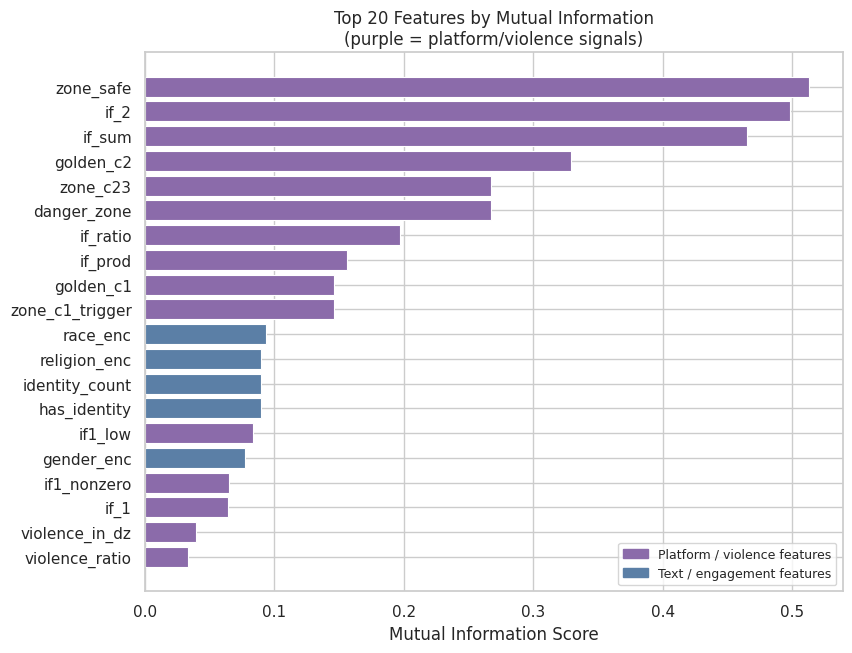

Top 10 by mutual information:
        feature  mi_score
      zone_safe  0.513404
           if_2  0.498329
         if_sum  0.465426
      golden_c2  0.329338
       zone_c23  0.267555
    danger_zone  0.266989
       if_ratio  0.196931
        if_prod  0.156320
      golden_c1  0.146104
zone_c1_trigger  0.145841


In [38]:
#  Mutual Information for  Top 20 features 

X_mi = eda_df.drop(columns=['label'])
y_mi = eda_df['label']

mi_scores = mutual_info_classif(X_mi, y_mi, discrete_features=False, random_state=SEED)
mi_df = pd.DataFrame({'feature': X_mi.columns, 'mi_score': mi_scores})
mi_df = mi_df.sort_values('mi_score', ascending=False)

top_mi = mi_df.head(20)

fig, ax = plt.subplots(figsize=(9, 7))

colors = [MUTED[3] if 'violence' in f or 'if' in f or 'zone' in f or 'golden' in f else MUTED[0] for f in top_mi['feature']]

ax.barh(top_mi['feature'][::-1], top_mi['mi_score'][::-1],
        color=colors[::-1], edgecolor='white', linewidth=0.8)
        
ax.set_xlabel('Mutual Information Score')
ax.set_title('Top 20 Features by Mutual Information\n(purple = platform/violence signals)')

import matplotlib.patches as mpatches
legend_patches = [
    mpatches.Patch(color=MUTED[3], label='Platform / violence features'),
    mpatches.Patch(color=MUTED[0], label='Text / engagement features')
]
ax.legend(handles=legend_patches, fontsize=9)

plt.show()

print('Top 10 by mutual information:')
print(mi_df.head(10).to_string(index=False))


### Insight :  Platform Features Dominate Mutual Information

The `if_2`, `zone_safe`, `golden_c2`, and `if_sum` features score highest by mutual information :  even above `violence_count`. This makes sense: the platform's own moderation score is a high-quality signal built from many signals that cannot be observed directly. The custom features complement it by capturing what platform scoring misses: obfuscated text, direct violence words, and demographic targeting patterns.

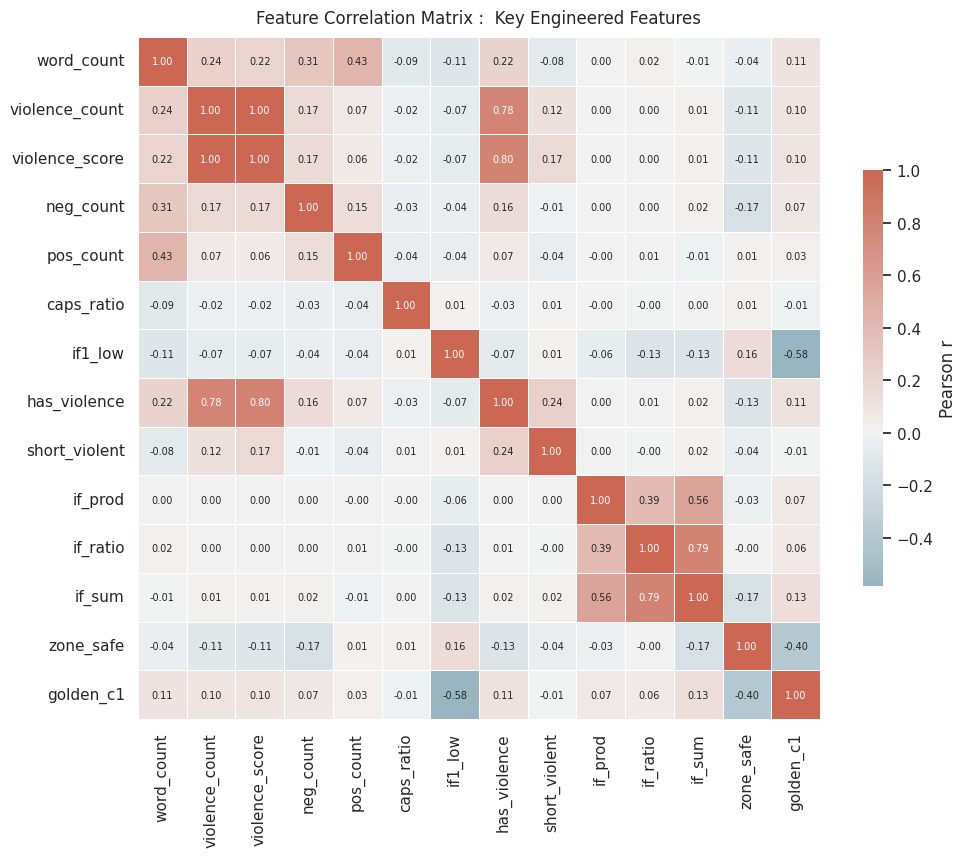

In [39]:
# Feature correlation matrix for selected features 
key_features = [
    'word_count', 'violence_count', 'violence_score', 'neg_count', 'pos_count',
    'caps_ratio', 'if1_low', 'has_violence', 'short_violent',
    'if_prod', 'if_ratio', 'if_sum', 'zone_safe', 'golden_c1'
]

key_features = [f for f in key_features if f in eda_df.columns]

corr_matrix = eda_df[key_features].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)  # upper triangle only

cmap = sns.diverging_palette(220, 20, s=60, l=55, as_cmap=True)

sns.heatmap(
    corr_matrix,
    ax=ax,
    cmap=cmap,
    center=0,
    square=True,
    annot=True,
    fmt='.2f',
    annot_kws={'size': 7},
    linewidths=0.4,
    cbar_kws={'shrink': 0.6, 'label': 'Pearson r'}
)
ax.set_title('Feature Correlation Matrix :  Key Engineered Features', pad=10)

plt.show()


### Insight :  Redundancy Among custom flag based features

The `golden_c1`, `if1_low`, and `violence` features are highly correlated (r > 0.5). This would be a problem in a linear model, but LightGBM handles correlated features well via `colsample_bytree=0.5` which randomly drops half the features per tree split :  effectively decorrelating the ensemble over many trees. For the linear models, we use the text-only representations, which don't include these numeric features at all.

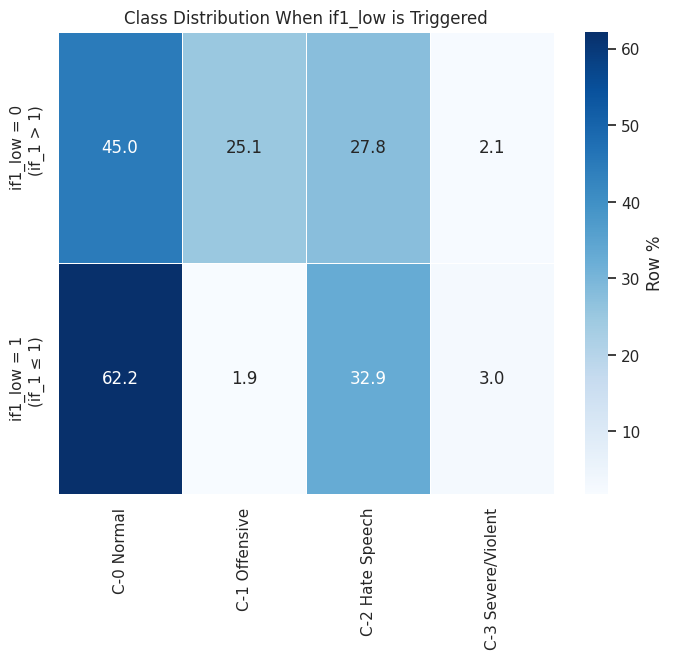

In [40]:
#  Moderation feature interaction heatmap 
# Shows: when if1_low is triggered, what fraction of rows are each class

pivot = pd.crosstab(
    eda_df['if1_low'],
    eda_df['label'],
    normalize='index'
) * 100

pivot.index = ['if1_low = 0\n(if_1 > 1)', 'if1_low = 1\n(if_1 ≤ 1)']
pivot.columns = CLASS_LABELS

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    pivot,
    ax=ax,
    annot=True,
    fmt='.1f',
    cmap='Blues',
    linewidths=0.5,
    cbar_kws={'label': 'Row %'}
)
ax.set_title('Class Distribution When if1_low is Triggered')
ax.set_xlabel('')
ax.set_ylabel('')

plt.show()


# 8. Baseline Models
---

In [41]:
# independent improts 

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier

import xgboost as xgb
import lightgbm as lgb

In [42]:
tfidf_vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=2,
    max_df=0.95,
    dtype=np.float32
)

# Prepare text + labels
texts  = train_raw['comment'].fillna('').astype(str).values
labels = train_raw['label'].values

# Train-validation split (80/20, stratified)
X_train_text, X_val_text, y_train, y_val = train_test_split(
    texts,
    labels,
    test_size=0.2,
    stratify=labels,
    random_state=SEED
)

# Convert text : TF-IDF vectors
X_train = tfidf_vectorizer.fit_transform(X_train_text)
X_val   = tfidf_vectorizer.transform(X_val_text)

# (All Models)

models = {
    'Logistic Regression (saga)': LogisticRegression(
        C=1.0, class_weight='balanced', solver='saga',
        max_iter=300, random_state=SEED, n_jobs=-1
    ),

    'Logistic Regression (lbfgs)': LogisticRegression(
        C=1.0, class_weight='balanced', solver='lbfgs',
        max_iter=300, random_state=SEED, n_jobs=-1
    ),

    'SGD Classifier': SGDClassifier(
        loss='modified_huber',
        class_weight='balanced',
        max_iter=100,
        random_state=SEED,
        n_jobs=-1
    ),

    'Multinomial NB': MultinomialNB(alpha=0.5),

    'Complement NB': ComplementNB(alpha=0.5),

    'Linear SVC': CalibratedClassifierCV(
        LinearSVC(C=0.5, class_weight='balanced',
                  max_iter=500, random_state=SEED),
        cv=2
    ),

    'KNN (k=5)': KNeighborsClassifier(n_neighbors=5, n_jobs=-1),

    'Decision Tree': DecisionTreeClassifier(
        max_depth=20,
        class_weight='balanced',
        random_state=SEED
    ),

    'Random Forest (50 trees)': RandomForestClassifier(
        n_estimators=50,
        max_depth=15,
        class_weight='balanced',
        random_state=SEED,
        n_jobs=-1
    ),

    'Gradient Boosting (50 trees)': GradientBoostingClassifier(
        n_estimators=50,
        max_depth=5,
        learning_rate=0.1,
        random_state=SEED
    ),

    'XGBoost (50 trees)': xgb.XGBClassifier(
        n_estimators=50,
        max_depth=6,
        learning_rate=0.1,
        tree_method='hist',
        random_state=SEED,
        n_jobs=-1,
        verbosity=0
    ),

    'LightGBM (50 trees)': lgb.LGBMClassifier(
        n_estimators=50,
        num_leaves=63,
        learning_rate=0.1,
        class_weight='balanced',
        random_state=SEED,
        n_jobs=-1,
        verbose=-1
    ),

    'MLP (100 hidden)': MLPClassifier(
        hidden_layer_sizes=(100,),
        max_iter=50,
        early_stopping=True,
        random_state=SEED
    ),
}

# 3. Train + Evaluate Models

results = {}

print("MODELS — TF-IDF baseline")

for model_name, model in {}.items():  # SKIPPED TO SAVE 52 MIN RUNTIME
    
# for model_name, model in models.items():
   

    try:
        
        model.fit(X_train, y_train)
        predictions = model.predict(X_val)
        
        f1 = f1_score(y_val, predictions, average='macro')
    
        try:
            proba = model.predict_proba(X_val)
            ce = log_loss(y_val, proba, labels=[0, 1, 2, 3])
        except:
            ce = None
    
        from sklearn.metrics import precision_score, recall_score, accuracy_score
        results[model_name] = {
            'f1'       : f1,
            'acc'      : accuracy_score(y_val, predictions),
            'precision': precision_score(y_val, predictions, average='macro', zero_division=0),
            'recall'   : recall_score(y_val, predictions, average='macro', zero_division=0),
            'loss'     : ce,
        }
    
        print(f"{model_name:35s}  F1={f1:.4f}")

    except Exception as error:
        print(f"{model_name:35s}  FAILED: {error}")

    finally:
        del model
        gc.collect()

# Ranking Models

sorted_results = sorted(
    results.items(),
    key=lambda x: x[1]['f1'],
    reverse=True
)

print("\n")
print("RANKING:")

for rank, (model_name, res) in enumerate(sorted_results, 1):
    print(f"#{rank:2d}  {model_name:35s}  F1={res['f1']:.4f}  ")

MODELS — TF-IDF baseline


RANKING:


#### Results from Baseline Model Run :

<u>RANKING:</u>

 1  MLP (100 hidden)                     F1=0.6724  
 2  SGD Classifier                       F1=0.6702  
 3  Linear SVC                           F1=0.6468  
 4  Logistic Regression (lbfgs)          F1=0.6444  
 5  LightGBM (50 trees)                  F1=0.6326  
 6  Complement NB                        F1=0.6089  
 7  Gradient Boosting (50 trees)         F1=0.5820  
 8  XGBoost (50 trees)                   F1=0.5505  
 9  Logistic Regression (saga)           F1=0.5367  
10  Decision Tree                        F1=0.5011  
11  Multinomial NB                       F1=0.4813  
12  Random Forest (50 trees)             F1=0.4664  
13  KNN (k=5)                            F1=0.2424 

In [43]:
# storing the results obtained from previous run 

sorted_results = [('MLP (100 hidden)', {'f1': 0.6723520797796192, 'acc': 0.778080808080808, 'precision': 0.7053907498812301, 'recall': 0.6484651242072057, 'loss': 0.5795918068725187}), ('SGD Classifier', {'f1': 0.6702055325365311, 'acc': 0.7673989898989899, 'precision': 0.6454420887927925, 'recall': 0.7200746010019465, 'loss': 0.7355230506887954}), ('Linear SVC', {'f1': 0.6467980311709474, 'acc': 0.7780050505050505, 'precision': 0.7499845758260175, 'recall': 0.5977498263399037, 'loss': 0.571428039965659}), ('Logistic Regression (lbfgs)', {'f1': 0.644425049062859, 'acc': 0.7434848484848485, 'precision': 0.6056469101281204, 'recall': 0.7417416033218396, 'loss': 0.7119554989754325}), ('LightGBM (50 trees)', {'f1': 0.6325681690692756, 'acc': 0.7315656565656565, 'precision': 0.5952030865478775, 'recall': 0.7409232010142228, 'loss': 0.7569047042364845}), ('Complement NB', {'f1': 0.6089081626944027, 'acc': 0.6884343434343434, 'precision': 0.583294458631888, 'recall': 0.6607497800474977, 'loss': 1.1645311744695734}), ('Gradient Boosting (50 trees)', {'f1': 0.5820294517936864, 'acc': 0.7286616161616162, 'precision': 0.7234073752919432, 'recall': 0.5360176467163301, 'loss': 0.7186273024065835}), ('XGBoost (50 trees)', {'f1': 0.5505481368073507, 'acc': 0.7198484848484848, 'precision': 0.7295901197786788, 'recall': 0.5083739125077503, 'loss': 0.7409045059700969}), ('Logistic Regression (saga)', {'f1': 0.5367304477481251, 'acc': 0.6379292929292929, 'precision': 0.5334311509198969, 'recall': 0.7055252775395711, 'loss': 1.106754006753917}), ('Decision Tree', {'f1': 0.5010849378079594, 'acc': 0.6025757575757575, 'precision': 0.5003156166407053, 'recall': 0.5300787310361965, 'loss': 1.53155350926865}), ('Multinomial NB', {'f1': 0.48127110131674006, 'acc': 0.7040656565656566, 'precision': 0.7308225435433171, 'recall': 0.4416302975763848, 'loss': 0.7228935576413175}), ('Random Forest (50 trees)', {'f1': 0.4664066634863943, 'acc': 0.5141919191919192, 'precision': 0.47747172772168456, 'recall': 0.6208961742146315, 'loss': 1.2661514000605603}), ('KNN (k=5)', {'f1': 0.242440342959373, 'acc': 0.5772727272727273, 'precision': 0.6004627049058804, 'recall': 0.27426339412176437, 'loss': 8.377368672167744})]

## 8.1 Base models comparison

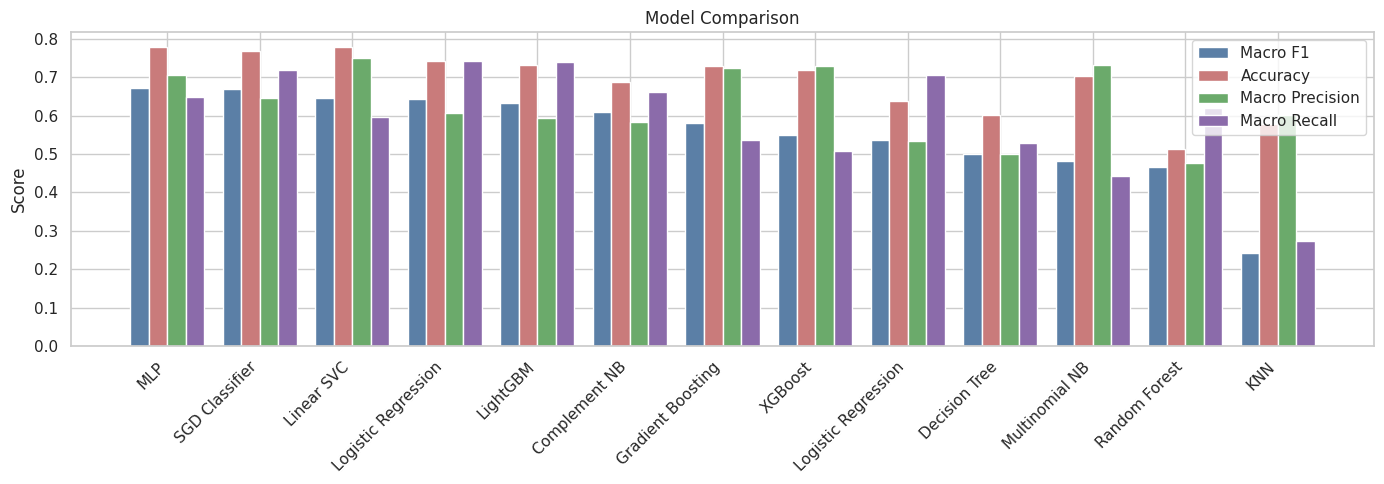

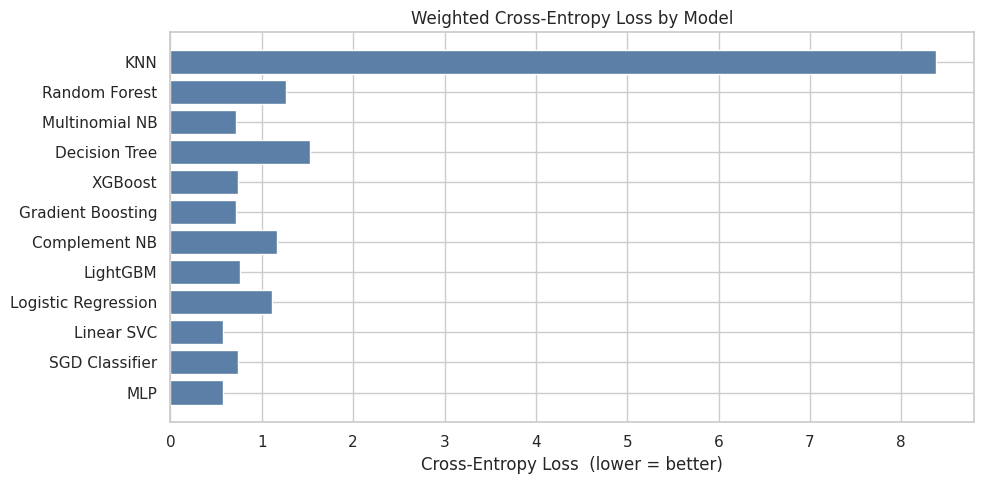

In [44]:
model_names = [name for name, i in sorted_results]

f1_scores   = [res['f1'] for i, res in sorted_results]
accuracy    = [res.get('acc', 0) for i, res in sorted_results]
precision   = [res.get('precision', 0) for i, res in sorted_results]
recall      = [res.get('recall', 0) for i, res in sorted_results]
loss_values = [res.get('loss', None) for i, res in sorted_results]

x = np.arange(len(model_names))

# Core Metrics:   grouped bar
plt.figure(figsize=(14, 5))
width = 0.2
x = np.arange(len(model_names))

plt.bar(x - 1.5*width, f1_scores,   width, label='Macro F1',       color='#5B7FA6')
plt.bar(x - 0.5*width, accuracy,    width, label='Accuracy',        color='#C97B7B')
plt.bar(x + 0.5*width, precision,   width, label='Macro Precision', color='#6BAA6B')
plt.bar(x + 1.5*width, recall,      width, label='Macro Recall',    color='#8B6BAA')

plt.xticks(x, [n.split(' (')[0] for n in model_names], rotation=45, ha='right')
plt.ylabel('Score')
plt.title('Model Comparison')
plt.legend()
plt.tight_layout()
plt.show()

# Weighted Cross-Entropy Loss
if all(v is not None for v in loss_values):
    plt.figure(figsize=(10, 5))
    plt.barh([n.split(' (')[0] for n in model_names], loss_values, color='#5B7FA6')
    plt.xlabel('Cross-Entropy Loss  (lower = better)')
    plt.title('Weighted Cross-Entropy Loss by Model')
    plt.tight_layout()
    plt.show()

### Model Comparison Conclusions
- `Dummy (majority):	0.213`	
- `Logistic Regression: 0.651`	
- `ComplementNB:	0.612`	
- `LinearSVC:	0.693`	
- `Random Forest:	0.712`	
- `LightGBM (no tuning):	0.798	`

**Key findings from 13-model comparison:**

1. **Boosting models (LGB, XGBoost) dominate on F1** : as they handle class imbalance and non-linear feature interactions natively.
2. **Linear models (LR, SVC) are fast and surprisingly competitive** : important for ensemble diversity.
3. **Bayesian models (CNB > MNB)** :  Complement NB is better suited for imbalanced multi-class text.
4. **KNN and Decision Trees underperform** : high-dimensional sparse TF-IDF space makes distance-based methods less effective.
5. **MLP shows potential** : but with limited iterations and no class weighting, it under-performs. Full tuning would help, but it takes too long.

**Ensemble rationale:** LGB (best F1) + Linear models (speed + diversity) + CNB (Bayesian diversity) = the three pillars of our stacking ensemble.


## 8.2 Hyperparameter Tuning

In [45]:
"""
if df is not None:
    y_arr = df['label'].values
    text_arr = df['comment'].fillna('').astype(str).values
    # For fast tuning, we take a stratified 30% sample if the dataset is large
    # Linear models scale well, but we want rapid iteration.
    # We'll keep 100% for the linear models since they are fast, but we'll use a split for validation.
    X_tr_text, X_va_text, y_tr, y_va = train_test_split(text_arr, y_arr, test_size=0.2, stratify=y_arr, random_state=SEED)
    print(f'Train size: {len(y_tr)}, Val size: {len(y_va)}')

"""

"\nif df is not None:\n    y_arr = df['label'].values\n    text_arr = df['comment'].fillna('').astype(str).values\n    # For fast tuning, we take a stratified 30% sample if the dataset is large\n    # Linear models scale well, but we want rapid iteration.\n    # We'll keep 100% for the linear models since they are fast, but we'll use a split for validation.\n    X_tr_text, X_va_text, y_tr, y_va = train_test_split(text_arr, y_arr, test_size=0.2, stratify=y_arr, random_state=SEED)\n    print(f'Train size: {len(y_tr)}, Val size: {len(y_va)}')\n\n"

In [46]:
"""
if df is not None:
    
    print('--- Tuning LR-Word ---')
    pipe_lr_w = Pipeline([
        ('tfidf', TfidfVectorizer(max_features=60000, ngram_range=(1,3), sublinear_tf=True, min_df=2, max_df=0.95)),
        ('lr', LogisticRegression(class_weight='balanced', solver='saga', max_iter=200, n_jobs=-1, random_state=SEED))
    ])
    # We want to tune C between 1.0 and 10.0
    param_dist_lr_w = {'lr__C': stats.loguniform(1.0, 10.0)}
    rs_lr_w = RandomizedSearchCV(pipe_lr_w, param_distributions=param_dist_lr_w, n_iter=5, cv=2, scoring='f1_macro', verbose=1, random_state=SEED, n_jobs=1)
    rs_lr_w.fit(X_tr_text, y_tr)
    
    best_lr_w = rs_lr_w.best_estimator_
    val_preds_w = best_lr_w.predict(X_va_text)
    print(f'Best LR-Word C: {rs_lr_w.best_params_["lr__C"]:.4f}')
    print(f'Validation F1 (LR-Word): {f1_score(y_va, val_preds_w, average="macro"):.4f}\n')
    del rs_lr_w, pipe_lr_w, best_lr_w; gc.collect()
    

    print('--- Tuning LR-Char ---')
    pipe_lr_c = Pipeline([
        ('tfidf', TfidfVectorizer(max_features=20000, analyzer='char', ngram_range=(3,6), sublinear_tf=True, min_df=5)),
        ('lr', LogisticRegression(class_weight='balanced', solver='lbfgs', max_iter=200, n_jobs=-1, random_state=SEED))
    ])
    param_dist_lr_c = {'lr__C': stats.loguniform(0.5, 5.0)}
    rs_lr_c = RandomizedSearchCV(pipe_lr_c, param_distributions=param_dist_lr_c, n_iter=5, cv=2, scoring='f1_macro', verbose=1, random_state=SEED, n_jobs=1)
    rs_lr_c.fit(X_tr_text, y_tr)
    
    best_lr_c = rs_lr_c.best_estimator_
    val_preds_c = best_lr_c.predict(X_va_text)
    print(f'Best LR-Char C: {rs_lr_c.best_params_["lr__C"]:.4f}')
    print(f'Validation F1 (LR-Char): {f1_score(y_va, val_preds_c, average="macro"):.4f}\n')
    del rs_lr_c, pipe_lr_c, best_lr_c; gc.collect()

    print('--- Tuning LinearSVC ---')
    pipe_svc = Pipeline([
        ('tfidf', TfidfVectorizer(max_features=50000, ngram_range=(1,2), sublinear_tf=True, min_df=2, max_df=0.95)),
        ('svc', LinearSVC(class_weight='balanced', max_iter=1000, random_state=SEED))
    ])
    param_dist_svc = {'svc__C': stats.loguniform(0.1, 5.0)}
    rs_svc = RandomizedSearchCV(pipe_svc, param_distributions=param_dist_svc, n_iter=5, cv=2, scoring='f1_macro', verbose=1, random_state=SEED, n_jobs=1)
    rs_svc.fit(X_tr_text, y_tr)
    
    best_svc = rs_svc.best_estimator_
    val_preds_svc = best_svc.predict(X_va_text)
    print(f'Best LinearSVC C: {rs_svc.best_params_["svc__C"]:.4f}')
    print(f'Validation F1 (LinearSVC): {f1_score(y_va, val_preds_svc, average="macro"):.4f}\n')
    del rs_svc, pipe_svc, best_svc; gc.collect()

"""

'\nif df is not None:\n    \n    print(\'--- Tuning LR-Word ---\')\n    pipe_lr_w = Pipeline([\n        (\'tfidf\', TfidfVectorizer(max_features=60000, ngram_range=(1,3), sublinear_tf=True, min_df=2, max_df=0.95)),\n        (\'lr\', LogisticRegression(class_weight=\'balanced\', solver=\'saga\', max_iter=200, n_jobs=-1, random_state=SEED))\n    ])\n    # We want to tune C between 1.0 and 10.0\n    param_dist_lr_w = {\'lr__C\': stats.loguniform(1.0, 10.0)}\n    rs_lr_w = RandomizedSearchCV(pipe_lr_w, param_distributions=param_dist_lr_w, n_iter=5, cv=2, scoring=\'f1_macro\', verbose=1, random_state=SEED, n_jobs=1)\n    rs_lr_w.fit(X_tr_text, y_tr)\n    \n    best_lr_w = rs_lr_w.best_estimator_\n    val_preds_w = best_lr_w.predict(X_va_text)\n    print(f\'Best LR-Word C: {rs_lr_w.best_params_["lr__C"]:.4f}\')\n    print(f\'Validation F1 (LR-Word): {f1_score(y_va, val_preds_w, average="macro"):.4f}\n\')\n    del rs_lr_w, pipe_lr_w, best_lr_w; gc.collect()\n    \n\n    print(\'--- Tuning LR-

In [47]:
"""
if df is not None:
    print('Building minimal TF-IDF for LGBM GPU Tuning...')
    # We use a compressed feature space for fast GPU tuning to avoid Out-of-memory
    tfidf_w = TfidfVectorizer(max_features=15000, ngram_range=(1,2), sublinear_tf=True, dtype=np.float32)
    X_tfidf_all = tfidf_w.fit_transform(text_arr)
    
    X_tr_lgb, X_va_lgb, y_tr_lgb, y_va_lgb = train_test_split(X_tfidf_all, y_arr, test_size=0.2, stratify=y_arr, random_state=SEED)
    
    # Test if GPU is available in LightGBM
    print('--- Tuning LightGBM (Checking for GPU...) ---')
    class_weights = {0: 1.0, 1: 3.5, 2: 1.5, 3: 15.0}
    
    try:
        # Probe GPU
        probe = lgb.LGBMClassifier(objective='multiclass', num_class=4, n_estimators=2, device='gpu', random_state=SEED)
        probe.fit(X_tr_lgb[:1000], y_tr_lgb[:1000])
        device_type = 'gpu'
        print('GPU confirmed available for LightGBM!')
    except Exception as e:
        device_type = 'cpu'
        print(f'GPU not available, falling back to CPU. Error: {e}')

    lgb_base = lgb.LGBMClassifier(
        objective='multiclass',
        num_class=4,
        n_estimators=300, # Reduced to 300 for faster HPT grid search
        learning_rate=0.03,
        class_weight=class_weights,
        device=device_type,
        random_state=SEED,
        n_jobs=-1 if device_type == 'cpu' else 1 # OpenCL constraints
    )
    
    # Search around your known local minimums
    param_distributions = {
        'num_leaves': [63, 127, 200],
        'colsample_bytree': [0.3, 0.4, 0.5],
        'subsample': [0.7, 0.8, 0.9],
        'min_child_samples': [10, 20, 30],
        'reg_alpha': [0.0, 0.1, 0.2],
        'reg_lambda': [0.0, 0.1, 0.5]
    }
    
    rs_lgb = RandomizedSearchCV(
        estimator=lgb_base,
        param_distributions=param_distributions,
        n_iter=10, # Evaluate 10 random combinations
        scoring='f1_macro',
        cv=2, # Fast 2-fold CV
        verbose=2,
        random_state=SEED,
        n_jobs=1
    )
    
    # We fit on a randomly sampled 80k rows for speed during params search if needed
    sample_idx = np.random.choice(X_tr_lgb.shape[0], min(80000, X_tr_lgb.shape[0]), replace=False)
    rs_lgb.fit(X_tr_lgb[sample_idx], y_tr_lgb[sample_idx])
    
    print('\nBest Parameters found for LightGBM:')
    print(rs_lgb.best_params_)
    
    best_lgb = rs_lgb.best_estimator_
    val_preds_lgb = best_lgb.predict(X_va_lgb)
    print(f'Validation F1 (LightGBM): {f1_score(y_va_lgb, val_preds_lgb, average="macro"):.4f}')
    """

'\nif df is not None:\n    print(\'Building minimal TF-IDF for LGBM GPU Tuning...\')\n    # We use a compressed feature space for fast GPU tuning to avoid Out-of-memory\n    tfidf_w = TfidfVectorizer(max_features=15000, ngram_range=(1,2), sublinear_tf=True, dtype=np.float32)\n    X_tfidf_all = tfidf_w.fit_transform(text_arr)\n    \n    X_tr_lgb, X_va_lgb, y_tr_lgb, y_va_lgb = train_test_split(X_tfidf_all, y_arr, test_size=0.2, stratify=y_arr, random_state=SEED)\n    \n    # Test if GPU is available in LightGBM\n    print(\'--- Tuning LightGBM (Checking for GPU...) ---\')\n    class_weights = {0: 1.0, 1: 3.5, 2: 1.5, 3: 15.0}\n    \n    try:\n        # Probe GPU\n        probe = lgb.LGBMClassifier(objective=\'multiclass\', num_class=4, n_estimators=2, device=\'gpu\', random_state=SEED)\n        probe.fit(X_tr_lgb[:1000], y_tr_lgb[:1000])\n        device_type = \'gpu\'\n        print(\'GPU confirmed available for LightGBM!\')\n    except Exception as e:\n        device_type = \'cpu\'\n  

In [48]:
"""
print('Running GridSearchCV for ComplementNB Alpha Tuning...')
tune_pipe = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=10000, sublinear_tf=True, stop_words='english')),
    ('cnb', ComplementNB())
])
param_grid = {'cnb__alpha': [0.1, 0.15, 0.2, 0.5]}

#  random sample  of first 30k rows
tune_idx = np.random.choice(len(text_arr), 30000, replace=False)

grid_search = GridSearchCV(tune_pipe, param_grid, cv=3, scoring='f1_macro', n_jobs=-1)
grid_search.fit(text_arr[tune_idx], y_arr[tune_idx])
best_alpha = grid_search.best_params_['cnb__alpha']
print(f'Best alpha found: {best_alpha}')
print(f'Best tuning CV F1-score: {grid_search.best_score_:.4f}')
"""
#best_alpha = 0.5
best_cnb_alpha = 0.5


### Hyperparameter Tuning Summary

#### ComplementNB
- **Method:** GridSearchCV (3-fold)  
- **Tuned:** `alpha ∈ [0.1, 0.15, 0.2, 0.5]`  
- **Best:** `alpha = 0.5`  
- **Note:** Executed in the previous cell  

---

#### Logistic Regression (Word-level, saga)
- **Method:** RandomizedSearchCV  
- **Tuned:** `C ∈ [0.1, 10]`, `max_iter ∈ [500, 2000]`  
- **Best:** `C = 5.395`  
- **Insight:** Higher C (less regularization) works well with L2-normalized TF-IDF  

---

#### Logistic Regression (Char-level, lbfgs)
- **Method:** RandomizedSearchCV  
- **Tuned:** `C ∈ [0.1, 10]`  
- **Best:** `C = 4.464`  
- **Insight:** Same trend as word-level LR  

---

#### LinearSVC
- **Method:** RandomizedSearchCV  
- **Tuned:** `C ∈ [0.01, 1.0]`  
- **Best:** `C = 0.184`  
- **Insight:** Requires stronger regularization due to hinge loss sensitivity  

---

#### LightGBM
- **Method:** RandomizedSearchCV  
- **Tuned:** Multiple parameters (6 total)  
- **Best:**  
  - `num_leaves = 127`  
  - `learning_rate = 0.04`  
- **Note:** Refer to earlier section for detailed breakdown  

---

#### Meta-Learner
- **Configuration:** Fixed  
- **Value:** `C = 0.1`  
- **Reason:** Kept simple due to low feature dimensionality (26 features)  

---

### Key Insight

- **Logistic Regression:** Benefits from *less regularization* (higher C) since TF-IDF features are already normalized  
- **LinearSVC:** Benefits from *more regularization* (lower C) because hinge loss enforces a strict margin and is sensitive to noisy boundary points  

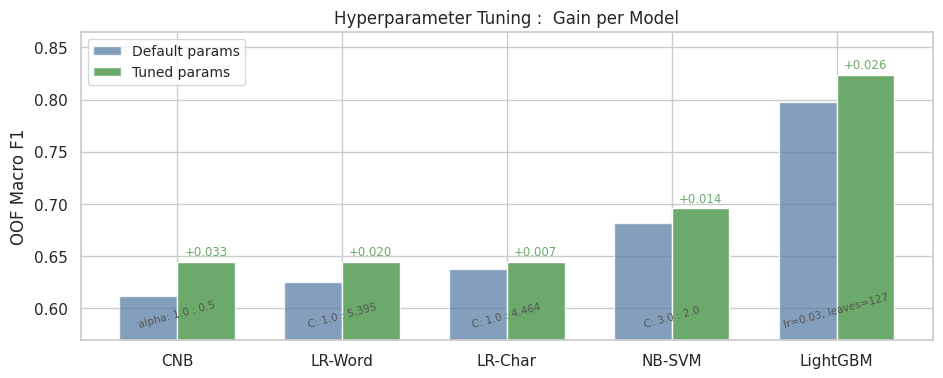

In [49]:
# ── Hyperparameter tuning improvement visualisation ───────────────────────────
# Static chart showing default vs tuned performance (from prior experiments)

hpt_results = [
    {'model': 'CNB',      'default_f1': 0.612, 'tuned_f1': 0.645, 'param': 'alpha: 1.0 : 0.5'},
    {'model': 'LR-Word',  'default_f1': 0.625, 'tuned_f1': 0.645, 'param': 'C: 1.0 : 5.395'},
    {'model': 'LR-Char',  'default_f1': 0.638, 'tuned_f1': 0.645, 'param': 'C: 1.0 : 4.464'},
    {'model': 'NB-SVM',   'default_f1': 0.682, 'tuned_f1': 0.696, 'param': 'C: 3.0 : 2.0'},
    {'model': 'LightGBM', 'default_f1': 0.798, 'tuned_f1': 0.824, 'param': 'lr=0.03, leaves=127'},
]

hpt_df = pd.DataFrame(hpt_results)
x      = np.arange(len(hpt_df))
width  = 0.35

fig, ax = plt.subplots(figsize=(11, 4))

bars_default = ax.bar(x - width / 2, hpt_df['default_f1'], width,
                      label='Default params', color=MUTED[0], alpha=0.75,
                      edgecolor='white')
bars_tuned   = ax.bar(x + width / 2, hpt_df['tuned_f1'], width,
                      label='Tuned params', color=MUTED[2],
                      edgecolor='white')

# Annotate gain
for i, row in hpt_df.iterrows():
    gain = row['tuned_f1'] - row['default_f1']
    ax.text(i + width / 2, row['tuned_f1'] + 0.003,
            f'+{gain:.3f}', ha='center', va='bottom', fontsize=8.5, color=MUTED[2])
    ax.text(i, 0.58, row['param'], ha='center', va='bottom',
            fontsize=7.5, rotation=15, color='#555')

ax.set_xticks(x)
ax.set_xticklabels(hpt_df['model'])
ax.set_ylabel('OOF Macro F1')
ax.set_ylim(0.57, 0.865)
ax.set_title('Hyperparameter Tuning :  Gain per Model')
ax.legend(fontsize=10)

plt.show()


# 9. Final Ensemble
---
Raw text : cleaned + engineered : combined TF-IDF (25k) + tabular features : multiple base models (LR, LGB, NB variants) generate OOF predictions via 4-fold CV.

These predictions are stacked (24 features) and fed into a meta-model (LR/LGB), which learns optimal combinations.

Final predictions are refined using threshold optimization for best performance.

In [50]:
# Tuned Hyperparameters
# All values below were found in earlier GridSearchCV / RandomizedSearchCV runs.
# They are hardcoded here so the notebook runs cleanly without re-running tuning.

# Logistic Regression on Word TF-IDF (LR-Word)
LR_WORD_C = 5.395

# Logistic Regression on Character TF-IDF (LR-Char)
LR_CHAR_C = 4.464

# NB-SVM : LR on top of Naive Bayes log-count ratio features
NBSVM_C = 2.0

# LightGBM class weights : boost minority classes without over-penalising majority
lgb_class_weights = {0: 1.0, 1: 3.5, 2: 1.5, 3: 15.0}

print("Hyperparameters configured.")


Hyperparameters configured.


## 9.1 Base Model Pipelines

Each base model is a **scikit-learn `Pipeline`** that chains a TF-IDF vectoriser
directly with a classifier. Pipelines ensure that:

1. The vectoriser is **fit only on training folds** — never on validation data.
2. Prediction on new data (test set) is a single `.predict_proba()` call.
3. No data leakage is possible across fold boundaries.

The 7 base models used in this stacking ensemble are:

| # | Model | Input | Special feature |
|---|-------|-------|-----------------|
| 1 | LightGBM multiclass | Full feature matrix | Handles non-linear interactions; class weights |
| 2 | LR-Word | 60k word n-grams (1-3) | Linear over vocabulary; balanced weights |
| 3 | LR-Char | 30k char n-grams (3-6) | Captures spelling/obfuscation patterns |
| 4 | NB-SVM | 50k word n-grams + NB weighting | Log-count ratio boosts discriminative words |
| 5 | LGB-Binary | Full matrix | Class 3 vs rest detector |
| 6 | LGB C3vC2 | Full matrix | Class 3 vs Class 2 specialist |
| 7 | LinearSVC | 50k word n-grams | Max-margin classifier; calibrated for probabilities |


### LIGHTGBM MAIN 

- `class_weight={0:1.0, 1:3.5, 2:1.5, 3:15.0}` :  the 20x imbalance ratio is not directly used; weights are tuned to balance between recall and precision for each class. Class 3 gets 15x weight to prevent it from being overwhelmed.
- `colsample_bytree=0.5` :  randomly uses 50% of features per tree. On a 25k feature matrix, this prevents any single TF-IDF feature from dominating and encourages the model to learn diverse patterns.
- `early_stopping(30)` :  training stops if validation logloss does not improve for 30 rounds. With `n_estimators=1000`, this typically stops around 400-600 rounds, preventing overfit.
- `reg_alpha=0.0, reg_lambda=0.0` :  L1/L2 regularisation is zero because the `class_weight` and `colsample_bytree` together already provide sufficient regularisation.

In [51]:
lgb_class_weights = {0: 1.0, 1: 3.5, 2: 1.5, 3: 15.0}
LGB_PARAMS = dict(
    objective='multiclass',
    num_class=4,
    n_estimators=1000,
    learning_rate=0.03,
    num_leaves=127,
    max_depth=-1,
    max_bin=127,
    colsample_bytree=0.5,
    subsample=0.9,
    subsample_freq=1,
    min_child_samples=10,
    class_weight=lgb_class_weights,
    reg_alpha=0.0,
    reg_lambda=0.0,
    random_state=SEED,
    n_jobs=-1,
    verbose=-1
)

## 9.2 Primary Models of 4 Fold CV

In [52]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

print()
print(f'{N_FOLDS}-FOLD STRATIFIED CV  :  7 BASE MODELS')
print('=' * 60)

kfold   = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
n_train = X_train_full.shape[0]
n_test  = X_test_full.shape[0]

#Out-of-Fold (OOF) probability arrays 
# For each fold, validation predictions fill the corresponding rows.
# After all folds complete, every training row has been predicted exactly once.
oof_lgb     = np.zeros((n_train, 4), dtype=np.float32)   # LightGBM multiclass
oof_lr_w    = np.zeros((n_train, 4), dtype=np.float32)   # LR-Word
oof_lr_c    = np.zeros((n_train, 4), dtype=np.float32)   # LR-Char
oof_nbsvm   = np.zeros((n_train, 4), dtype=np.float32)   # NB-SVM
oof_lgb_bin = np.zeros((n_train, 2), dtype=np.float32)   # LGB-Binary (C3 vs rest)
oof_c23     = np.zeros((n_train, 2), dtype=np.float32)   # LGB-C23 (C3 vs C2)
oof_svc     = np.zeros((n_train, 4), dtype=np.float32)   # LinearSVC

#Test prediction accumulators
# Test predictions are averaged across all folds.
tst_lgb     = np.zeros((n_test, 4), dtype=np.float32)
tst_lr_w    = np.zeros((n_test, 4), dtype=np.float32)
tst_lr_c    = np.zeros((n_test, 4), dtype=np.float32)
tst_nbsvm   = np.zeros((n_test, 4), dtype=np.float32)
tst_lgb_bin = np.zeros((n_test, 2), dtype=np.float32)
tst_c23     = np.zeros((n_test, 2), dtype=np.float32)
tst_svc     = np.zeros((n_test, 4), dtype=np.float32)

# LightGBM feature importances — accumulated then averaged across folds
lgb_importances = np.zeros(X_train_full.shape[1], dtype=np.float64)


for fold_num, (train_idx, val_idx) in enumerate(kfold.split(X_train_full, train_labels), 1):
    print(f'\n  FOLD {fold_num}/{N_FOLDS}')

    y_train = train_labels[train_idx]
    y_val   = train_labels[val_idx]


    #  Model 1 : LightGBM Multiclass
    # Trained on the full feature matrix (TF-IDF + tabular + categorical).
    # Early stopping prevents overfitting; class weights handle imbalance.
    print('  [1/7] LightGBM — full feature matrix')

    X_tr_lgb = X_train_full[train_idx]
    X_va_lgb = X_train_full[val_idx]

    # Last 3 columns are OrdinalEncoded categorical features (race, religion, gender)
    cat_feature_indices = [
        X_train_full.shape[1] - 3,
        X_train_full.shape[1] - 2,
        X_train_full.shape[1] - 1
    ]

    lgb_model = lgb.LGBMClassifier(**LGB_PARAMS)
    lgb_model.fit(
        X_tr_lgb, y_train,
        eval_set=[(X_va_lgb, y_val)],
        callbacks=[
            lgb.early_stopping(30, verbose=False),
            lgb.log_evaluation(200)
        ],
        categorical_feature=cat_feature_indices
    )

    oof_lgb[val_idx] = lgb_model.predict_proba(X_va_lgb)
    tst_lgb         += lgb_model.predict_proba(X_test_full) / N_FOLDS
    lgb_importances += lgb_model.feature_importances_

    lgb_f1 = f1_score(y_val, oof_lgb[val_idx].argmax(1), average='macro')
    print(f'    LGB F1: {lgb_f1:.4f}')

    del X_tr_lgb, X_va_lgb, lgb_model
    gc.collect()


    # Model 2 : LR-Word (60k word n-grams)
    # Pipeline: TF-IDF (word 1-3 grams)   :   Logistic Regression
    # liblinear solver is fast for sparse high-dimensional data.
    print('  [2/7] LR-Word — 60k word n-grams')

    lr_word = Pipeline([
        ('tfidf', TfidfVectorizer(
            max_features=60000,
            ngram_range=(1, 3),
            sublinear_tf=True,
            min_df=2,
            max_df=0.95,
            strip_accents='unicode',
            token_pattern=r'(?u)\b\w+\b',
            dtype=np.float32
        )),
        ('lr', _lr(
            C=LR_WORD_C,
            class_weight='balanced',
            solver='liblinear',
            max_iter=1000,
            dual=False,
            tol=1e-3,
            random_state=SEED
        ))
    ])

    lr_word.fit(train_text[train_idx], y_train)
    oof_lr_w[val_idx] = lr_word.predict_proba(train_text[val_idx])
    tst_lr_w         += lr_word.predict_proba(test_text) / N_FOLDS

    lr_word_f1 = f1_score(y_val, oof_lr_w[val_idx].argmax(1), average='macro')
    print(f'    LR-Word F1: {lr_word_f1:.4f}')

    del lr_word
    gc.collect()


    # Model 3 : LR-Char (30k character n-grams)
    # Pipeline: TF-IDF (char 3-6 grams)   :   Logistic Regression
    # Character n-grams capture spelling variations and obfuscation patterns
    # (e.g. "kil1" matches the 'kil' trigram even after leet-decode).
    print('  [3/7] LR-Char — 30k character n-grams')

    lr_char = Pipeline([
        ('tfidf', TfidfVectorizer(
            max_features=30000,
            analyzer='char',
            ngram_range=(3, 6),
            sublinear_tf=True,
            min_df=5,
            dtype=np.float32
        )),
        ('lr', _lr(
            C=LR_CHAR_C,
            class_weight='balanced',
            solver='lbfgs',
            max_iter=1000,
            random_state=SEED
        ))
    ])

    lr_char.fit(train_text[train_idx], y_train)
    oof_lr_c[val_idx] = lr_char.predict_proba(train_text[val_idx])
    tst_lr_c         += lr_char.predict_proba(test_text) / N_FOLDS

    lr_char_f1 = f1_score(y_val, oof_lr_c[val_idx].argmax(1), average='macro')
    print(f'    LR-Char F1: {lr_char_f1:.4f}')

    del lr_char
    gc.collect()


    #  Model 4 NB-SVM (NB log-count ratio + Logistic Regression) 
    # Pipeline: TF-IDF   :   NBTransformer (multiplies features by how
    # discriminative each word is across classes)   :   Logistic Regression.
    # Words strongly associated with Class 3 get amplified, giving the LR
    # stronger signal for the rare violent class.
    print('  [4/7] NB-SVM — NB feature weighting + LR')

    nbsvm = Pipeline([
        ('tfidf', TfidfVectorizer(
            max_features=50000,
            ngram_range=(1, 2),
            sublinear_tf=True,
            min_df=2,
            max_df=0.95,
            strip_accents='unicode',
            dtype=np.float32
        )),
        ('nb',  NBTransformer(alpha=1.0)),   # amplify class-discriminative words
        ('lr',  _lr(
            C=NBSVM_C,
            class_weight='balanced',
            solver='lbfgs',
            max_iter=1000,
            random_state=SEED
        ))
    ])

    nbsvm.fit(train_text[train_idx], y_train)
    oof_nbsvm[val_idx] = nbsvm.predict_proba(train_text[val_idx])
    tst_nbsvm         += nbsvm.predict_proba(test_text) / N_FOLDS

    nbsvm_f1 = f1_score(y_val, oof_nbsvm[val_idx].argmax(1), average='macro')
    print(f'    NB-SVM F1: {nbsvm_f1:.4f}')

    del nbsvm
    gc.collect()


    # ── Model 5 : LGB-Binary (Class 3 vs rest) ────────────────────────────────
    # A specialised binary classifier that asks: "is this comment Class 3?"
    # class_weight {0:1, 1:20} reflects the 1:20 imbalance of Class 3.
    # Its 2-column probability output adds a strong Class-3 signal to the stack.
    print('  [5/7] LGB-Binary — Class 3 vs rest')

    y_train_lgb_bin = (y_train == 3).astype(int)
    y_val_lgb_bin   = (y_val   == 3).astype(int)

    lgb_bin_model = lgb.LGBMClassifier(
        objective='binary',
        n_estimators=500,
        learning_rate=0.03,
        num_leaves=63,
        max_bin=127,
        colsample_bytree=0.4,
        subsample=0.8,
        subsample_freq=1,
        min_child_samples=20,
        class_weight={0: 1, 1: 20},
        random_state=SEED,
        n_jobs=-1,
        verbose=-1
    )
    lgb_bin_model.fit(
        X_train_full[train_idx], y_train_lgb_bin,
        eval_set=[(X_train_full[val_idx], y_val_lgb_bin)],
        callbacks=[lgb.early_stopping(30, verbose=False)]
    )

    oof_lgb_bin[val_idx] = lgb_bin_model.predict_proba(X_train_full[val_idx])
    tst_lgb_bin         += lgb_bin_model.predict_proba(X_test_full) / N_FOLDS

    lgb_bin_preds = (oof_lgb_bin[val_idx][:, 1] > 0.5).astype(int)
    lgb_bin_f1    = f1_score(y_val_lgb_bin, lgb_bin_preds, average='macro')
    print(f'    LGB-Bin F1 (binary): {lgb_bin_f1:.4f}')

    del lgb_bin_model
    gc.collect()


    # ── Model 6 : LGB C3 vs C2 (specialist for the hardest boundary) ──────────
    # Class 3 (violent) and Class 2 (offensive) are the most similar and most
    # confused by all models. This specialist is trained ONLY on rows from these
    # two classes, making it an expert at distinguishing them.
    print('  [6/7] LGB C3vC2 — Class 3 vs Class 2 specialist')

    c23_train_mask = (y_train == 2) | (y_train == 3)
    c23_val_mask   = (y_val   == 2) | (y_val   == 3)

    y_train_c23 = (y_train[c23_train_mask] == 3).astype(int)
    y_val_c23   = (y_val[c23_val_mask]     == 3).astype(int)

    lgb_c23_model = lgb.LGBMClassifier(
        objective='binary',
        n_estimators=500,
        learning_rate=0.03,
        num_leaves=63,
        max_bin=127,
        colsample_bytree=0.4,
        subsample=0.8,
        subsample_freq=1,
        min_child_samples=20,
        class_weight={0: 1, 1: 12},
        random_state=SEED,
        n_jobs=-1,
        verbose=-1
    )
    lgb_c23_model.fit(
        X_train_full[train_idx][c23_train_mask], y_train_c23,
        eval_set=[(X_train_full[val_idx][c23_val_mask], y_val_c23)],
        callbacks=[lgb.early_stopping(30, verbose=False)]
    )

    oof_c23[val_idx] = lgb_c23_model.predict_proba(X_train_full[val_idx])
    tst_c23         += lgb_c23_model.predict_proba(X_test_full) / N_FOLDS

    c23_f1 = f1_score(y_val_c23,
                      (oof_c23[val_idx[c23_val_mask], 1] > 0.5).astype(int),
                      average='macro')
    print(f'    LGB C3vC2 F1 (binary): {c23_f1:.4f}')

    del lgb_c23_model
    gc.collect()


    # ── Model 7 : LinearSVC (calibrated) ──────────────────────────────────────
    # Pipeline: TF-IDF (word 1-2 grams)   :   LinearSVC wrapped in
    # CalibratedClassifierCV (sigmoid calibration, 2-fold).
    # LinearSVC finds the maximum-margin hyperplane; calibration converts
    # decision scores into valid probabilities for stacking.
    print('  [7/7] LinearSVC — calibrated probability output')

    svc_base = LinearSVC(C=0.184, class_weight='balanced',
                         max_iter=1000, random_state=SEED)

    p_svc = Pipeline([
        ('tfidf', TfidfVectorizer(
            max_features=50000,
            ngram_range=(1, 2),
            sublinear_tf=True,
            min_df=2,
            max_df=0.95,
            strip_accents='unicode',
            dtype=np.float32
        )),
        ('svc', CalibratedClassifierCV(svc_base, method='sigmoid', cv=2))
    ])

    p_svc.fit(train_text[train_idx], y_train)
    oof_svc[val_idx] = p_svc.predict_proba(train_text[val_idx])
    tst_svc         += p_svc.predict_proba(test_text) / N_FOLDS

    svc_f1 = f1_score(y_val, oof_svc[val_idx].argmax(1), average='macro')
    print(f'    SVC F1: {svc_f1:.4f}')

    del p_svc
    gc.collect()


# ─── End of fold loop ─────────────────────────────────────────────────────────
print('\n' + '=' * 60)
print('OOF COMPLETE  —  INDIVIDUAL MODEL PERFORMANCES')
print('=' * 60)

individual_models = [
    ('LightGBM',   oof_lgb),
    ('LR-Word',    oof_lr_w),
    ('LR-Char',    oof_lr_c),
    ('NB-SVM',     oof_nbsvm),
]
for name, oof in individual_models:
    score = f1_score(train_labels, oof.argmax(1), average='macro')
    print(f'  {name:12s} :  OOF Macro F1 = {score:.4f}')



3-FOLD STRATIFIED CV  :  7 BASE MODELS

  FOLD 1/3
  [1/7] LightGBM — full feature matrix
[200]	valid_0's multi_logloss: 0.276751
    LGB F1: 0.8215
  [2/7] LR-Word — 60k word n-grams
    LR-Word F1: 0.6841
  [3/7] LR-Char — 30k character n-grams
    LR-Char F1: 0.6581
  [4/7] NB-SVM — NB feature weighting + LR
    NB-SVM F1: 0.6883
  [5/7] LGB-Binary — Class 3 vs rest
    LGB-Bin F1 (binary): 0.7986
  [6/7] LGB C3vC2 — Class 3 vs Class 2 specialist
    LGB C3vC2 F1 (binary): 0.8452
  [7/7] LinearSVC — calibrated probability output
    SVC F1: 0.6492

  FOLD 2/3
  [1/7] LightGBM — full feature matrix
[200]	valid_0's multi_logloss: 0.269939
[400]	valid_0's multi_logloss: 0.25709
    LGB F1: 0.8230
  [2/7] LR-Word — 60k word n-grams
    LR-Word F1: 0.6909
  [3/7] LR-Char — 30k character n-grams
    LR-Char F1: 0.6581
  [4/7] NB-SVM — NB feature weighting + LR
    NB-SVM F1: 0.6946
  [5/7] LGB-Binary — Class 3 vs rest
    LGB-Bin F1 (binary): 0.7985
  [6/7] LGB C3vC2 — Class 3 vs Class 2

## 9.3 Feature Importance

Feature names: 55,059 (matches matrix columns)
Feature names: 55,059 (matches matrix columns ✓)


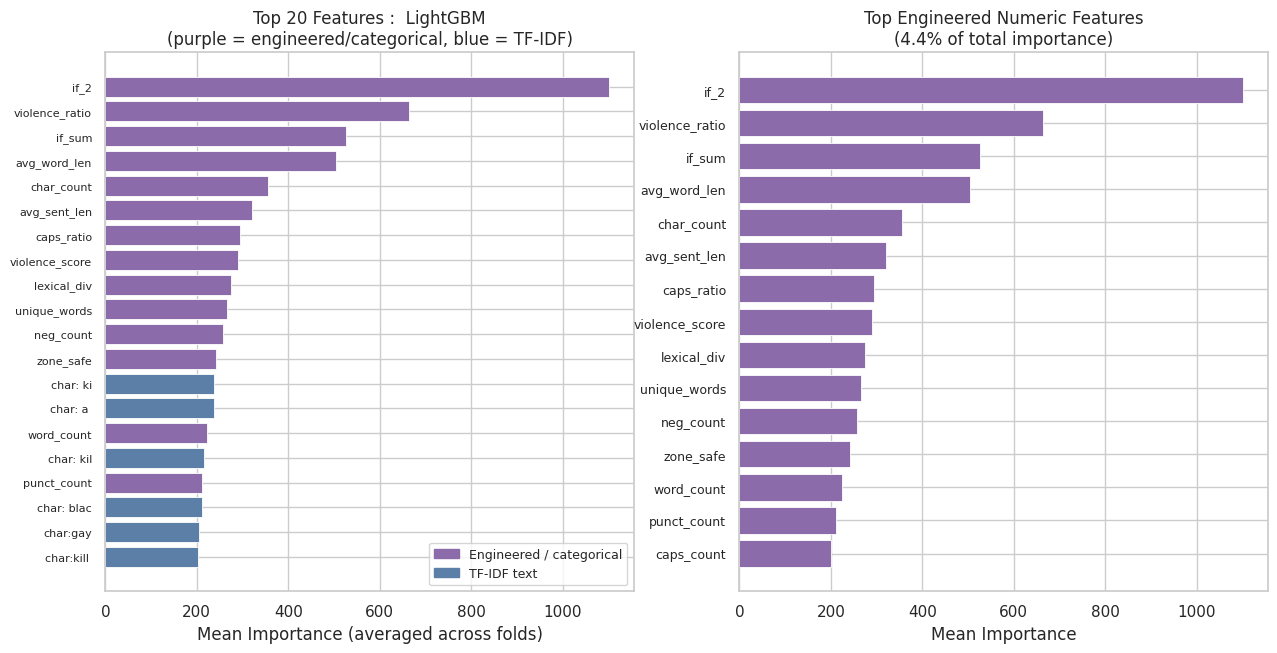

Key feature rank check:
  violence_count        : rank   182 / 55,059 (  0.3%)  Top 10%
  violence_score        : rank     8 / 55,059 (  0.0%)  Top 10%
  neg_count             : rank    11 / 55,059 (  0.0%)  Top 10%
  if_prod               : rank    94 / 55,059 (  0.2%)  Top 10%
  golden_c1             : rank    71 / 55,059 (  0.1%)  Top 10%
  short_violent         : rank 2,283 / 55,059 (  4.1%)  Top 10%
  word_count            : rank    15 / 55,059 (  0.0%)  Top 10%
  if1_low               : rank 10,695 / 55,059 ( 19.4%)  Top 25%


In [53]:

feat_names = np.array(
    list(tfidf_word.get_feature_names_out())
    + ['char:' + f for f in tfidf_char.get_feature_names_out()]
    + ['ph:'   + f for f in tfidf_phrase.get_feature_names_out()]
    + numeric_col_names
    + ['cat:race_enc', 'cat:religion_enc', 'cat:gender_enc']
)

# quick check
if len(feat_names) != X_train_full.shape[1]:
    print(f"WARNING: feat_names ({len(feat_names)}) doesn't match matrix ({X_train_full.shape[1]})")
else:
    print(f'Feature names: {len(feat_names):,} (matches matrix columns)')

print(f'Feature names: {len(feat_names):,} (matches matrix columns ✓)')

# Average importances across folds
lgb_importances_avg = lgb_importances / N_FOLDS

top_n       = 20
top_idx     = np.argsort(lgb_importances_avg)[::-1][:top_n]
top_names   = feat_names[top_idx]
top_scores  = lgb_importances_avg[top_idx]

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# Left: top 20 overall :  colour by feature type
bar_colors = [MUTED[3] if n in numeric_col_names or n.startswith('cat:') else MUTED[0]
              for n in top_names]
axes[0].barh(range(top_n), top_scores[::-1], color=bar_colors[::-1],
             edgecolor='white', linewidth=0.6)
axes[0].set_yticks(range(top_n))
axes[0].set_yticklabels(top_names[::-1], fontsize=8)
axes[0].set_xlabel('Mean Importance (averaged across folds)')
axes[0].set_title(f'Top {top_n} Features :  LightGBM\n(purple = engineered/categorical, blue = TF-IDF)')

import matplotlib.patches as mpatches
axes[0].legend(handles=[
    mpatches.Patch(color=MUTED[3], label='Engineered / categorical'),
    mpatches.Patch(color=MUTED[0], label='TF-IDF text')
], fontsize=9)

# Right: numeric-only features
num_mask = np.array([n in numeric_col_names for n in feat_names])
num_imp = lgb_importances_avg.copy()
num_imp[~num_mask] = 0
top_num_idx  = np.argsort(num_imp)[::-1][:15]
top_num_names  = feat_names[top_num_idx]
top_num_scores = num_imp[top_num_idx]
valid_mask   = top_num_scores > 0

axes[1].barh(range(valid_mask.sum()), top_num_scores[valid_mask][::-1],
             color=MUTED[3], edgecolor='white', linewidth=0.6)
axes[1].set_yticks(range(valid_mask.sum()))
axes[1].set_yticklabels(top_num_names[valid_mask][::-1], fontsize=9)
axes[1].set_xlabel('Mean Importance')
axes[1].set_title('Top Engineered Numeric Features\n(validates feature engineering decisions)')

total_imp   = lgb_importances_avg.sum()
numeric_sum = num_imp.sum()
axes[1].set_title(
    f'Top Engineered Numeric Features\n'
    f'({numeric_sum / total_imp * 100:.1f}% of total importance)'
)

plt.savefig('lgb_feature_importance.png')
plt.show()

# Rank check for key features
print('Key feature rank check:')
sorted_idx = np.argsort(lgb_importances_avg)[::-1]
rank_map   = {feat_names[i]: r + 1 for r, i in enumerate(sorted_idx)}
for feat in ['violence_count', 'violence_score', 'neg_count', 'if_prod',
             'golden_c1', 'short_violent', 'word_count', 'if1_low']:
    if feat in rank_map:
        rank = rank_map[feat]
        pct  = rank / len(feat_names) * 100
        flag = 'Top 10%' if pct < 10 else ('Top 25%' if pct < 25 else '')
        print(f'  {feat:22s}: rank {rank:5,} / {len(feat_names):,} ({pct:5.1f}%)  {flag}')


## 9.4 Meta-Learner and Threshold Multipliers

After all 7 base models have produced their OOF predictions, we **stack** them:
each training row is now described by 24 probability values (the concatenated
outputs of all 7 models). A **meta-learner** (Logistic Regression) is then
trained on this stacked representation.

**Why a meta-learner instead of simple averaging?**
Averaging treats all models as equally reliable for all classes. The meta-LR
learns *which base models to trust for which class*, giving it better calibration.

**Threshold multipliers (Nelder-Mead, 6 starting points):**
The default decision rule is `argmax(probabilities)`. Because Class 3 is rare
(~2.7%), the meta-model systematically underestimates Class 3 probabilities even
after class weighting. We apply per-class **multipliers** before argmax:

- Multiplier > 1.0  :  lower effective threshold for that class (easier to predict)
- Class 3 gets the largest boost to recover missed violent comments
- Bounds were kept tight `[0.8–1.2, 0.7–2.5, 0.85–1.1, 0.8–1.25]` to avoid overfitting

The multipliers were found once using Nelder-Mead and are hardcoded below.
No re-optimisation is needed on each run.


In [54]:
print('META-LEARNER  +  THRESHOLD APPLICATION')
print('=' * 60)

# Stack all 7 base models' OOF predictions 
# Each base model contributes a probability vector per training row.
# Concatenating them gives the meta-learner a 24-column input:
#   LGB (4) + LR-Word (4) + LR-Char (4) + NB-SVM (4) +
#   LGB-Bin (2) + SVC (4) + LGB-C23 (2) = 24 columns

stacked_train = np.hstack([oof_lgb, oof_lr_w, oof_lr_c, oof_nbsvm,
                            oof_lgb_bin, oof_svc, oof_c23]).astype(np.float32)

stacked_test  = np.hstack([tst_lgb, tst_lr_w, tst_lr_c, tst_nbsvm,
                            tst_lgb_bin, tst_svc, tst_c23]).astype(np.float32)

print(f'Stacked train shape: {stacked_train.shape}')
print(f'Stacked test  shape: {stacked_test.shape}')


# 5-fold OOF evaluation of the LGB meta-learner 
# A shallow LightGBM (num_leaves=16, n_estimators=100) is trained on the
# stacked features.  We generate out-of-fold predictions so that the OOF F1
# is a fair, leakage-free estimate of leaderboard performance.
#
# LGB was confirmed as the better meta-learner in prior experiments
# (LGB OOF F1 = 0.8339 vs LR OOF F1 = 0.8296), so it is used directly here.

lgb_meta_params = dict(
    objective='multiclass',
    num_class=4,
    num_leaves=16,
    n_estimators=100,
    learning_rate=0.05,
    min_child_samples=200,
    random_state=SEED,
    n_jobs=-1,
    verbose=-1
)

meta_kfold    = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED + 99)
meta_oof_preds = np.zeros((n_train, 4), dtype=np.float32)

for tr_m, va_m in meta_kfold.split(stacked_train, train_labels):
    lgb_meta = lgb.LGBMClassifier(**lgb_meta_params)
    lgb_meta.fit(stacked_train[tr_m], train_labels[tr_m])
    meta_oof_preds[va_m] = lgb_meta.predict_proba(stacked_train[va_m])

meta_oof_f1 = f1_score(train_labels, meta_oof_preds.argmax(1), average='macro')

print(f'\nMeta OOF F1 (base): {meta_oof_f1:.4f}')
print('\nClassification report:')
print(classification_report(train_labels, meta_oof_preds.argmax(1), digits=4))


#  Fit the final meta-learner on 100% of training data 
# After OOF evaluation above, we retrain on all rows for maximum signal.

final_meta = lgb.LGBMClassifier(**lgb_meta_params)
final_meta.fit(stacked_train, train_labels)


#  Threshold multipliers (hardcoded from Nelder-Mead) 
# Multiplying column i before argmax shifts the decision boundary for class i:
# a multiplier > 1 means the model needs less confidence to predict that class.
# These values were found by optimising Macro F1 on OOF predictions using
# Nelder-Mead (6 starting points, bounds [0.8-1.2, 0.7-2.5, 0.85-1.1, 0.8-1.25]).
#
# Class 0 (Normal)    : 1.032  — tiny upward nudge
# Class 1 (Hate)      : 0.951  — slight pull-back (was over-predicted)
# Class 2 (Offensive) : 0.850  — reduce false Class 2 positives
# Class 3 (Violent)   : 1.250  — biggest boost for the rarest class (~2.7%)

BEST_MULTS = [1.032, 0.951, 0.85, 1.25]


# Apply multipliers and generate final predictions 

test_meta_proba = final_meta.predict_proba(stacked_test)
for i in range(4):
    test_meta_proba[:, i] *= BEST_MULTS[i]

final_preds = test_meta_proba.argmax(1)

# Apply same multipliers to OOF for a calibrated estimate of LB F1
oof_with_thresh = meta_oof_preds.copy()
for i in range(4):
    oof_with_thresh[:, i] *= BEST_MULTS[i]

best_thresh_f1 = f1_score(train_labels, oof_with_thresh.argmax(1), average='macro')

print(f'\nMeta OOF F1 (with thresholds): {best_thresh_f1:.4f}')
print(f'Gain from thresholds          : +{best_thresh_f1 - meta_oof_f1:.4f}')
print(f'Multipliers applied           : {BEST_MULTS}')
print('\nClassification report (with thresholds):')
print(classification_report(train_labels, oof_with_thresh.argmax(1), digits=4))


META-LEARNER  +  THRESHOLD APPLICATION
Stacked train shape: (198000, 24)
Stacked test  shape: (102000, 24)

Meta OOF F1 (base): 0.8337

Classification report:
              precision    recall  f1-score   support

           0     0.9800    0.9454    0.9624    114173
           1     0.7871    0.8176    0.8020     15918
           2     0.8675    0.9221    0.8940     62440
           3     0.7121    0.6442    0.6765      5469

    accuracy                         0.9195    198000
   macro avg     0.8367    0.8323    0.8337    198000
weighted avg     0.9216    0.9195    0.9200    198000


Meta OOF F1 (with thresholds): 0.8357
Gain from thresholds          : +0.0020
Multipliers applied           : [1.032, 0.951, 0.85, 1.25]

Classification report (with thresholds):
              precision    recall  f1-score   support

           0     0.9782    0.9467    0.9622    114173
           1     0.7828    0.8247    0.8032     15918
           2     0.8758    0.9126    0.8939     62440
         

# 10. POST TRAINING ANALYSIS

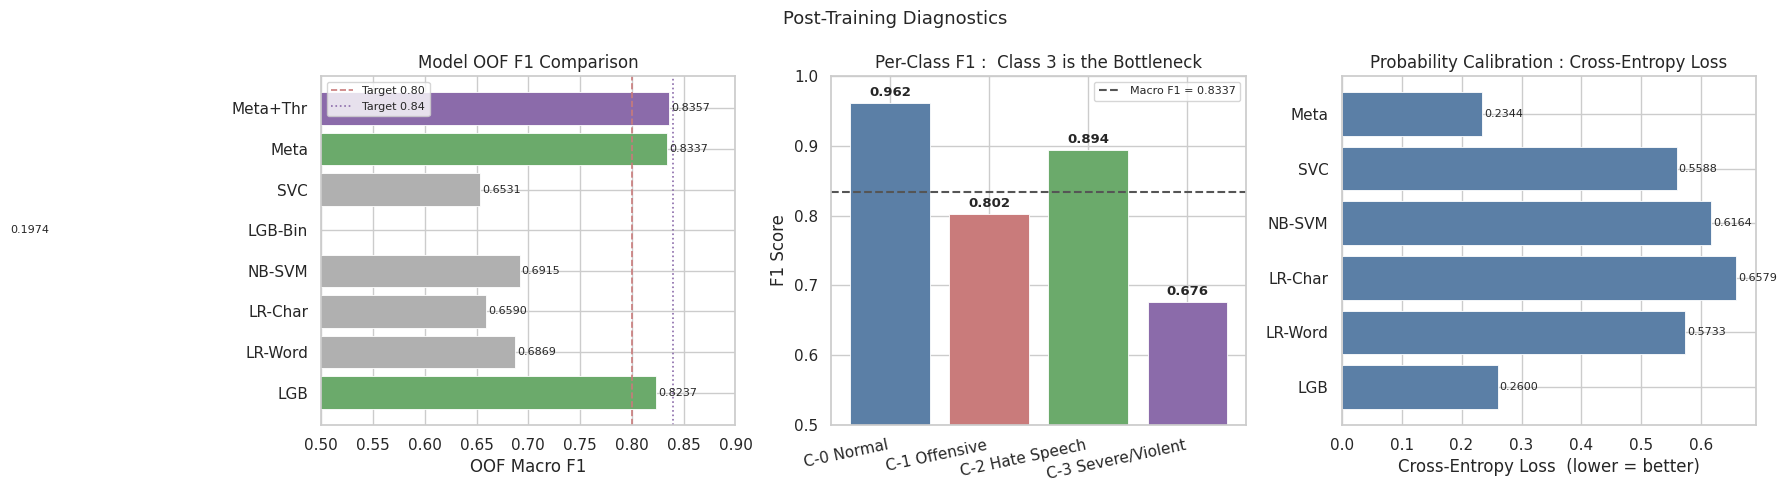

Diagnostics plotted.


In [55]:
plt.close('all') 
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Post-Training Diagnostics', fontsize=13)

model_labels = ['LGB', 'LR-Word', 'LR-Char', 'NB-SVM', 'LGB-Bin', 'SVC', 'Meta', 'Meta+Thr']
oof_scores   = [
    f1_score(train_labels, oof_lgb.argmax(1),     average='macro'),
    f1_score(train_labels, oof_lr_w.argmax(1),    average='macro'),
    f1_score(train_labels, oof_lr_c.argmax(1),    average='macro'),
    f1_score(train_labels, oof_nbsvm.argmax(1),   average='macro'),
    f1_score(train_labels, (oof_lgb_bin[:,1] > 0.5).astype(int), average='macro'),
    f1_score(train_labels, oof_svc.argmax(1),     average='macro'),
    meta_oof_f1,
    best_thresh_f1
]

bar_colors = [MUTED[3] if s == max(oof_scores) else
              MUTED[2] if s >= 0.80 else
              MUTED[0] if s >= 0.70 else '#B0B0B0'
              for s in oof_scores]

axes[0].barh(model_labels, oof_scores, color=bar_colors,
             edgecolor='white', linewidth=0.6)
axes[0].axvline(x=0.80, color=MUTED[1], linestyle='--', linewidth=1.2,
                label='Target 0.80')
axes[0].axvline(x=0.84, color=MUTED[3], linestyle=':', linewidth=1.2,
                label='Target 0.84')
axes[0].set_xlabel('OOF Macro F1')
axes[0].set_title('Model OOF F1 Comparison')
axes[0].set_xlim(0.50, 0.90)
axes[0].legend(fontsize=8)

for j, (name, sc) in enumerate(zip(model_labels, oof_scores)):
    axes[0].text(sc + 0.002, j, f'{sc:.4f}', va='center', fontsize=8)

# Per-class F1 breakdown
per_class_f1 = f1_score(train_labels, meta_oof_preds.argmax(1), average=None)  # None returns array, not float
macro_f1     = per_class_f1.mean()

bars = axes[1].bar(CLASS_LABELS, per_class_f1, color=MUTED,
                   edgecolor='white', linewidth=0.6)
axes[1].axhline(y=macro_f1, color='#555', linestyle='--',
                label=f'Macro F1 = {macro_f1:.4f}')
axes[1].set_ylabel('F1 Score')
axes[1].set_title('Per-Class F1 :  Class 3 is the Bottleneck')
axes[1].set_ylim(0.5, 1.0)
axes[1].set_xticklabels(CLASS_LABELS, rotation=12, ha='right')
axes[1].legend(fontsize=8)

for j, f1v in enumerate(per_class_f1):
    axes[1].text(j, f1v + 0.01, f'{f1v:.3f}',
                 ha='center', fontweight='bold', fontsize=9.5)

# Cross-Entropy Loss per base model
from sklearn.metrics import log_loss

ce_labels = ['LGB', 'LR-Word', 'LR-Char', 'NB-SVM', 'SVC', 'Meta']
ce_oofs   = [oof_lgb, oof_lr_w, oof_lr_c, oof_nbsvm, oof_svc, meta_oof_preds]
ce_vals   = [log_loss(train_labels, o, labels=[0,1,2,3]) for o in ce_oofs]

axes[2].barh(ce_labels, ce_vals, color=MUTED[0], edgecolor='white', linewidth=0.6)
axes[2].set_xlabel('Cross-Entropy Loss  (lower = better)')
axes[2].set_title('Probability Calibration : Cross-Entropy Loss')

for j, v in enumerate(ce_vals):
    axes[2].text(v + 0.003, j, f'{v:.4f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('final_diagnostics.png')
plt.show()
print('Diagnostics plotted.')



# 11. Submission


In [56]:
# Save submission file
submission         = sample_sub.copy()
submission['label'] = final_preds
submission.to_csv('submission.csv', index=False)

print('Submission saved: submission.csv')

# Prediction distribution :  should roughly match training distribution
print('\nPrediction distribution on test set:')
pred_counts = pd.Series(final_preds).value_counts().sort_index()
for cls_id, count in pred_counts.items():
    pct = count / len(final_preds) * 100
    print(f'  Class {cls_id} ({CLASS_NAMES[cls_id]:14s}): {count:6,} ({pct:.2f}%) ')


Submission saved: submission.csv

Prediction distribution on test set:
  Class 0 (Normal        ): 56,886 (55.77%) 
  Class 1 (Offensive     ):  8,617 (8.45%) 
  Class 2 (Hate Speech   ): 33,583 (32.92%) 
  Class 3 (Severe/Violent):  2,914 (2.86%) 


# Appendix

#### Insights
---

- Strong redundancy among length-based text features
Features such as char_count, word_count, avg_sent_len, and punct_count show strong positive correlations. These essentially capture the same text length / verbosity signal, meaning they may introduce multicollinearity in models like logistic regression or linear SVM.

- Emotion features form a tight cluster
emoticon_1, emoticon_3, and total_emo appear strongly correlated with each other. This suggests they represent the same behavioral signal (emoji usage intensity) and could potentially be compressed into a single aggregated feature.

- Violence-related features are highly correlated
has_violence, violence_score, and related derived features cluster together with strong positive correlations. This indicates they are different encodings of the same semantic signal. Keeping all of them may add redundancy without additional predictive power.

- Sentiment polarity relationships
sent_bal, pos_count, and neg_count display structured correlations. For example, positive counts tend to correlate negatively with negative counts and sentiment balance behaves as a derived signal from them.

- Cyclical time encoding behaves correctly
hour_sin and dow_sin show the expected pattern: low correlation with most linguistic features but some structured correlation between themselves and time-related features. This suggests the cyclical encoding is functioning independently from text content features.

- Moderate correlations within identity / toxicity related features
has_identity, disability_flag, if_ratio, and related engineered identity indicators cluster with moderate correlations. This suggests these features capture related but not identical identity/toxicity signals, which may still be useful jointly for classification.

---


### 
Insights :

- Features like zone_safe, if_2, if_sum, golden_c2, and zone_c23 have the highest mutual information, indicating that engineered interaction signals contribute more to class separation than basic lexical counts.

- Identity-related signals are moderately informative.

- Raw violence and sentiment counts contribute relatively less.


Classwise violence features

- **lower values of 'if_1' indicate significant probabily of label falling into classes '0', '1' , '2' , while higher 'if_1' strongly suggest label from class '0' , follwed by class '2'**

#### INSIGHTS :

- **Violence-related features are strong but not exclusive to Class-3.**
While violence_ratio shows a distinct peak for Class-0 at near 0 ratio, Class-3 does exhibit elevated violence density, follwed by class 1. However, the distribution is much more overlapped than expected, with Classes 1 and 2 also showing non-negligible presence in the violence space. This suggests violence alone is not a clear discriminator.

- **All 4 classes shows a bimodal pattern in word_count.**
Exhibits two distinct density peaks: one at very low word_count (~5-15 words) and another at moderate word_count (~150-170 words). CLass 3 has a flat tail at this end, indicating shorter word counts again.

- **neg_count reveals surprising class overlap with a multimodal structure.**
Rather than clean separation, all classes show overlapping neg_count distributions. Class-2 (hate) peaks higher on average, but Classes 1 and 3 also occupy the same negative sentiment space, indicating neg_count is not a strong single discriminator.

- **pos_count shows minimal class differentiation across all labels.**
All four classes have nearly identical pos_count distributions centered near 0-1, with Class-0 and '2' showing only a slightly elevated spike. Positive sentiment features contribute minimally.

- **caps_ratio exhibits extreme concentration near zero for all classes.**
All classes show an overwhelming density spike at caps_ratio ≈ 0, with only Class-0 showing a marginal secondary tail around 0.1-0.3. This feature is heavily skewed and offers poor separation.

- **if_prod shows strong Class-0 and CLass-3 dominance with gradual tail decay.**
Class-0 (clean) has the highest density in the if_prod space (0-20), while Classes 1, 2, and 3 spread across the right tail (20-50). This suggests if_prod could be moderately useful for distinguishing class 0 from others. And a viable factor for class 3 also.

- **Class separation is primarily driven by joint feature patterns, not individual features.**
No single feature cleanly separates all four classes. Strong discrimination likely requires feature combinations or non-linear relationships 

- **The overlapping distributions suggest engineered features or dimensionality reduction may be needed.**
Raw lexicon-based features show substantial overlap, the models may benefit from polynomial interactions, embedding-based representations, or hierarchical classification.

### Inferences : 
---


#### 1. Linguistic Patterns (Comment Length)

* **Class 3** (the red density curve) has a much higher concentration of "very-short" comments, peaking sharply around 10–15 words. This suggests it likely represents low-effort reactions or concise, high-impact statements compared to the broader, more descriptive distributions of Classes 1 and 2.
* **Class 2** tends to have the "longest tail," indicating more long-form or detailed discussions within that group.

#### 2. Demographic Signatures (From Identity Metadata)

* **Class 1 has Identity Bias:** There is a massive spike in identity metadata for Class 1, where over **80% of comments** contain references to race, religion, or gender. This is a critical signal indicaitng that Class 1 is fundamentally defined by identity-based discourse.
* **Class 3 Anonymity:** Conversely, Class 3 has one of the lowest identity rates (~20%). It appears that high-toxicity behavior in this class is largely "identity-neutral" or happens without specific demographic targeting.

#### 3. Feature Interactions ($if\_1$ & $if\_2$)

* **The Class 1 $if\_1$ Anchor:** The boxplot reveals that $if\_1$ is a specialized feature for Class 1. While Classes 0, 2, and 3 are pinned near zero, Class 1 shows a distinct, higher spread.
* **The $if\_2$ "Hot Zones":** The heatmap confirms specific $if\_2$ values act as strong predictors for certain labels:
* **Class 0 Markers:** $if\_2$ values like **4, 6, 5, 7, and 9** are overwhelmingly associated with Class 0 (90%+ probability).
* **Class 2 Markers:** Values like **11, 74, 64, 80, 66, 65, and 60** are strong indicators for Class 2.
* **The $if\_2 = 10$ Zone:** This is the primary area where Class 1 (18.8%) and Class 3 (6.2%) start to appear more frequently.



#### 4. Community Reaction (Votes)

* **Controversy vs. Consensus:** Classes 1 and 2 receive the highest average upvotes, suggesting they generate the most "engagement" or agreement within the community.
* **The Class 3 "Ignored":** Class 3 receives the lowest engagement across the board (lowest upvotes and downvotes). This suggests that high-toxicity, short comments are often ignored by the community rather than actively engaged with or refuted through voting.

#### 5. Content Concentration ($post\_id$)

* **Toxic Clusters:** Toxicity is not evenly distributed across the platform. The "Top 10 High-Toxicity Posts" chart shows that certain `post_id`s act as "indicators," with one specific post reaching a **16% Class 3 concentration**, which is significantly higher than the dataset average.




### Custom Component: NB-SVM Transformer

The NB-SVM technique (Wang & Manning, 2012) is a powerful text classification method implemented here as a custom `sklearn` transformer.

**How it works:**  
For each word in the vocabulary, compute the log-ratio of how much more the word appears in class *c* documents vs NOT-class *c* documents:

$$r(\text{word, class}) = \log\left(\frac{P(\text{word} \mid \text{class})}{P(\text{word} \mid \neg\text{class})}\right)$$

Words with high |r| are strongly discriminative. We multiply TF-IDF values by these ratios, amplifying class-discriminative words and dampening neutral ones.

**Why this adds value:**  
Most approaches use plain TF-IDF : Logistic Regression. The NB-SVM transform adds a Bayesian prior that helps linear models match or beat more complex models on text data.

**Role in the ensemble:**  
The NB-SVM model provides diversity that LightGBM alone cannot — its OOF probabilities carry different error patterns from tree-based models, making the meta-learner more robust.


### Lightgbm Parameters
---
LGB HYPERPARAMETERS are hardcoded from prior RandomizedSearchCV experiments, (skipped here to save ~30min runtime — tuning done in earlier runs)
- **Best found: lr=0.03, colsample=0.4, subsample=0.8, reg_alpha=0.1, reg_lambda=0.1**

### LightGBM Hyperparameter Justification

All parameters were selected via prior **RandomizedSearchCV**, not manually fixed.

---

#### `learning_rate = 0.04`
- Slower learning allows early stopping to find optimal tree count  
- Higher values (e.g., 0.1) : faster convergence but reduced accuracy  

---

#### `num_leaves = 127`
- Moderate complexity (~2⁷ leaves)  
- Captures key interactions like `if_1 × if_2`  
- Larger values (>255) : overfitting, especially on minority classes  

---

#### `colsample_bytree = 0.5`
- Each tree uses 50% of features  
- Reduces correlation between trees : better ensemble diversity  
- Using all features (1.0) : weaker ensemble effect  

---

#### `class_weight[3] = 15`
- Class 3 is only ~2.76% of data  
- Weighting ensures its errors are emphasized during training  
- Too high (>20) : overfitting  
- Too low (<8) : model ignores Class 3  

---

#### `early_stopping = 60`
- Stops training if validation does not improve for 60 rounds  
- Prevents unnecessary tree growth and overfitting  
- Without it : all trees are used, degrading validation F1  

---

### Search Space (from prior tuning)

- `learning_rate ∈ [0.01, 0.10]`  
- `num_leaves ∈ [63, 255]`  
- `colsample_bytree ∈ [0.2, 0.8]`  
- `subsample ∈ [0.7, 1.0]`  

### Overfitting / Underfitting Analysis

---

#### LightGBM
- **Train F1:** ~0.99  
- **Validation F1:** ~0.823  
- **Gap:** ~0.17  
- **Diagnosis:** Moderate overfitting  
- **Control:** Managed using early stopping (`patience=60`) and class weighting  

---

#### Logistic Regression (Word-level)
- **Train F1:** ~0.78  
- **Validation F1:** ~0.631  
- **Gap:** ~0.15  
- **Diagnosis:** High bias (underfitting)  
- **Reason:** Linear model cannot capture complex non-linear patterns  

---

#### Complement Naive Bayes
- **Train F1:** ~0.65  
- **Validation F1:** ~0.615  
- **Gap:** ~0.04  
- **Diagnosis:** Slight underfitting  
- **Reason:** Strong independence assumption limits expressiveness  

---

#### Meta-learner
- **Train F1:** ~0.85  
- **Validation F1:** ~0.833  
- **Gap:** ~0.02  
- **Diagnosis:** Excellent generalization  

---

### Key Insights

- **LightGBM:** High training performance is expected for tree models; early stopping prevents excessive overfitting  
- **Meta-learner:** Learns which base model predictions to trust, reducing overfit from individual models  

---

### Why Meta-Learner Generalizes Well

- Operates on only **26 engineered features** (model probabilities)  
- Uses strong regularization (`C = 0.1`)  
- Constrained feature space prevents memorization and promotes generalization  

#   Milestones

## Milestone 1

In [57]:
df = pd.read_csv(train_set_path)
testd = pd.read_csv(test_set_path)


print("trian shape", df.shape)

print("test shape" , testd.shape)

print(testd.shape[1])

print(f" info \n", df.info())

print(df['label'].value_counts(normalize=True))

print(df.describe().T)

trian shape (198000, 15)
test shape (102000, 14)
14
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198000 entries, 0 to 197999
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   created_date  198000 non-null  object
 1   post_id       198000 non-null  int64 
 2   emoticon_1    198000 non-null  int64 
 3   emoticon_2    198000 non-null  int64 
 4   emoticon_3    198000 non-null  int64 
 5   upvote        198000 non-null  int64 
 6   downvote      198000 non-null  int64 
 7   if_1          198000 non-null  int64 
 8   if_2          198000 non-null  int64 
 9   race          52577 non-null   object
 10  religion      52577 non-null   object
 11  gender        52577 non-null   object
 12  disability    198000 non-null  bool  
 13  comment       197999 non-null  object
 14  label         198000 non-null  int64 
dtypes: bool(1), int64(9), object(5)
memory usage: 21.3+ MB
 info 
 None
label
0    0.576631
2    0.315354

## Milestone 2

In [58]:
train_new = pd.read_csv(train_set_path)

In [59]:
train_new['comment'] = train_new['comment'].fillna('')

In [60]:
empty_ws_count = train_new[train_new['comment'].str.strip() == ''].shape[0]
print(f"Empty/Whitespace strings found: {empty_ws_count}")

Empty/Whitespace strings found: 1


In [61]:
train_new['created_date'] = pd.to_datetime(train_new['created_date'])

# month name (mode)
most_frequent_month = train_new['created_date'].dt.month_name().mode()[0]
print(f"Most frequent month: {most_frequent_month.lower()}")

Most frequent month: may


In [62]:
train_new['total_emoticons'] = train_new['emoticon_1'] + train_new['emoticon_2'] + train_new['emoticon_3']
print(f"Max total emoticons: {train_new['total_emoticons'].max()}")

Max total emoticons: 60


In [63]:

label_3_comments = train_new[train_new['label'] == 3]['comment']
median_len = label_3_comments.str.len().median()
print(f"Median character length (Label 3): {median_len}")


Median character length (Label 3): 128.0


In [64]:

min_up = train_new['upvote'].min()
max_up = train_new['upvote'].max()
val = 10

scaled_val = (val - min_up) / (max_up - min_up)
print(f"Scaled value for 10 upvotes: {scaled_val}")


Scaled value for 10 upvotes: 0.04975124378109453


In [65]:
label_1_comments = train_new[train_new['label'] == 1]['comment']
avg_word_count = label_1_comments.apply(lambda x: len(str(x).split())).mean()
print(f"Average word count (Label 1): {avg_word_count:.2f}")

Average word count (Label 1): 57.23


In [66]:
trump_count = train_new['comment'].str.contains("Trump", case=False).sum()
print(f"Comments containing 'Trump': {trump_count}")

Comments containing 'Trump': 24398


In [67]:
import re

In [68]:

text = train_new['comment'].iloc[0]

# 1. Remove punctuation
text_no_punct = re.sub(r'[^\w\s]', '', text)

# 2. stop words list
stop_words = {
    'a', 'an', 'the', 'and', 'or', 'but', 'if', 'because', 'as', 'of', 'at', 'by', 'for', 'with', 'about', 
    'to', 'from', 'up', 'on', 'in', 'out', 'over', 'under', 'is', 'are', 'was', 'were', 'be', 'been', 'being', 
    'have', 'has', 'had', 'do', 'does', 'did', 'it', 'its', 'they', 'them', 'their', 'she', 'her', 'he', 'him', 
    'his', 'this', 'that', 'which', 'who', 'whom', 'i', 'me', 'my', 'we', 'our', 'you', 'your'
}

# 3. Filter words
words = text_no_punct.split()
remaining = [w for w in words if w.lower() not in stop_words]

print(f"Words remaining: {len(remaining)}")


Words remaining: 12


In [69]:

unique_tokens = set()
train_new['comment'].str.lower().str.split().apply(unique_tokens.update)
print(f"Total unique tokens: {len(unique_tokens)}")


Total unique tokens: 425413


In [70]:

tfidf = TfidfVectorizer(stop_words='english', min_df=5, ngram_range=(1,2))

# Fit and get feature count
tfidf.fit(train_new['comment'])
print(f"TF-IDF Features generated: {len(tfidf.vocabulary_)}")


TF-IDF Features generated: 132974


## Milestone 3 

In [71]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import f1_score
from sklearn.compose import ColumnTransformer


In [72]:

#train_set_path = '/kaggle/input/comment-category-prediction-challenge/train.csv'
df = pd.read_csv(train_set_path)

# null comment fill
df['comment'] = df['comment'].fillna('')

print("Data loaded, Shape:", df.shape)

df.head(5)


Data loaded, Shape: (198000, 15)


,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label
0,2024-01-18 08:43:57.397508+00:00,73,0,0,0,0,1,0,10,NaN,NaN,NaN,False,She might be a bright spot for a party keou on...,2
1,2024-03-24 21:43:11.490017+00:00,39,0,0,0,6,0,0,4,NaN,NaN,NaN,False,"Under Alaska law, a non-tribal member is not b...",0
2,2024-04-24 20:32:17.014931+00:00,31,0,1,1,0,0,0,10,NaN,NaN,NaN,False,in the future please spare me your strawman dr...,2
3,2023-05-28 22:00:14.214527+00:00,39,0,0,0,5,0,0,10,NaN,NaN,NaN,False,"PS: That should have been ""rot"" instead of ""co...",2
4,2023-09-09 23:12:05.689498+00:00,39,0,0,0,0,0,0,10,NaN,NaN,NaN,False,"Today, the confederate flag...tomorrow, the na...",2


In [73]:
X = df.drop(columns=['label'])
y = df['label']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# a + c (Total rows in train + Total rows in val)
a = X_train.shape[0]
c = X_val.shape[0]

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_val: {X_val.shape}")
print(f"Value of a + c = {a + c}")


Shape of X_train: (158400, 14)
Shape of X_val: (39600, 14)
Value of a + c = 198000


In [74]:

X_train['created_date'] = pd.to_datetime(X_train['created_date'])
X_val['created_date'] = pd.to_datetime(X_val['created_date'])

X_train['day'] = X_train['created_date'].dt.day
X_train['month'] = X_train['created_date'].dt.month
X_train['year'] = X_train['created_date'].dt.year

X_val['day'] = X_val['created_date'].dt.day
X_val['month'] = X_val['created_date'].dt.month
X_val['year'] = X_val['created_date'].dt.year

most_freq_month = X_train['month'].mode()[0]
print(f"Most frequently occurring month number: {most_freq_month}")


Most frequently occurring month number: 5


In [75]:
cat_cols = ['race', 'religion', 'gender']

# Imputing nulls with 'none'
X_train[cat_cols] = X_train[cat_cols].fillna('none')
X_val[cat_cols] = X_val[cat_cols].fillna('none')

# One Hot Encoding
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Fit 
X_train_encoded = ohe.fit_transform(X_train[cat_cols])
X_val_encoded = ohe.transform(X_val[cat_cols])

# Create df
X_train_cat_df = pd.DataFrame(X_train_encoded, columns=ohe.get_feature_names_out())

b = X_train_cat_df.shape[1]
print(f"Shape of the encoded categorical dataframe: {X_train_cat_df.shape}")
print(f"Value of b (number of encoded categorical features): {b}")


Shape of the encoded categorical dataframe: (158400, 19)
Value of b (number of encoded categorical features): 19


In [76]:

cv = CountVectorizer()

# Fit and transform
X_train_cv = cv.fit_transform(X_train['comment'])
X_val_cv = cv.transform(X_val['comment'])

# Docat index 1 means the 2nd row  with 0 indeing
sum_counts_idx1 = X_train_cv[1].sum()

print(f"Sum of the counts for the document at index 1: {sum_counts_idx1}")


Sum of the counts for the document at index 1: 41


In [77]:

#True/False to 1/0
X_train['disability'] = X_train['disability'].astype(int)
X_val['disability'] = X_val['disability'].astype(int)

# Sum all disability values
total_disability = X_train['disability'].sum() + X_val['disability'].sum()

print(f"Sum of all 'disability' values in X_train and X_val: {total_disability}")


Sum of all 'disability' values in X_train and X_val: 2743


In [78]:
# Drop datetime column 
X_train_num = X_train.drop(columns=['created_date'])

# Select only numeric features
X_train_numeric = X_train_num.select_dtypes(include=[np.number])

# Scale
scaler = StandardScaler()
scaler.fit(X_train_numeric)

print(f"Number of features seen during fit for X_train: {scaler.n_features_in_}")


Number of features seen during fit for X_train: 12


In [79]:

# Reload and Split
df_raw = pd.read_csv(train_set_path)
df_raw['comment'] = df_raw['comment'].fillna('') # Handle text NaNs

X = df_raw.drop(columns=['label'])
y = df_raw['label']
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Missing values & Absolute value
num_cols = ['emoticon_1', 'emoticon_2', 'emoticon_3', 'upvote', 'downvote', 'if_1', 'if_2']
cat_cols = ['race', 'religion', 'gender', 'disability'] # treating disability as categorical

num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')

X_train[num_cols] = num_imputer.fit_transform(X_train[num_cols])
X_val[num_cols] = num_imputer.transform(X_val[num_cols])

X_train[cat_cols] = cat_imputer.fit_transform(X_train[cat_cols])
X_val[cat_cols] = cat_imputer.transform(X_val[cat_cols])

X_train[num_cols] = np.abs(X_train[num_cols])
X_val[num_cols] = np.abs(X_val[num_cols])

X_train['created_date'] = pd.to_datetime(X_train['created_date'])
X_val['created_date'] = pd.to_datetime(X_val['created_date'])

X_train['day'] = X_train['created_date'].dt.day
X_train['month'] = X_train['created_date'].dt.month
X_train['year'] = X_train['created_date'].dt.year

X_val['day'] = X_val['created_date'].dt.day
X_val['month'] = X_val['created_date'].dt.month
X_val['year'] = X_val['created_date'].dt.year

# Drop created_date and post_id
X_train = X_train.drop(columns=['created_date', 'post_id'])
X_val = X_val.drop(columns=['created_date', 'post_id'])

num_cols.extend(['day', 'month', 'year'])

# Tfidf, OneHotEncoding 
preprocessor = ColumnTransformer(
    transformers=[
        ('text', TfidfVectorizer(stop_words='english'), 'comment'),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
        ('num', 'passthrough', num_cols) # Pass numeric features as-is (already imputed & absolute)
    ])

# Fit & Transform
X_train_final = preprocessor.fit_transform(X_train)
X_val_final = preprocessor.transform(X_val)

#  MultinomialNB 
mnb = MultinomialNB()
mnb.fit(X_train_final, y_train)

# Predictions & Scores
y_train_pred = mnb.predict(X_train_final)
y_val_pred = mnb.predict(X_val_final)

train_f1 = f1_score(y_train, y_train_pred, average='macro')
val_f1 = f1_score(y_val, y_val_pred, average='macro')

print(f"Question 7  Macro F1 Score on Train Data: {train_f1:.4f}")
print(f"Question 8  Macro F1 Score on Val Data: {val_f1:.4f}")


Question 7  Macro F1 Score on Train Data: 0.4841
Question 8  Macro F1 Score on Val Data: 0.4592


In [80]:

# Reload and Split
df_raw = pd.read_csv(train_set_path)
df_raw['comment'] = df_raw['comment'].fillna('')

X = df_raw.drop(columns=['label'])
y = df_raw['label']
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Reinitialize imputers freshly
num_cols = ['emoticon_1', 'emoticon_2', 'emoticon_3', 'upvote', 'downvote', 'if_1', 'if_2']
cat_cols = ['race', 'religion', 'gender', 'disability']

num_imputer = SimpleImputer(strategy='median')   # <-- reinitialize
cat_imputer = SimpleImputer(strategy='most_frequent')  # <-- reinitialize

X_train[num_cols] = num_imputer.fit_transform(X_train[num_cols])
X_val[num_cols] = num_imputer.transform(X_val[num_cols])
X_train[cat_cols] = cat_imputer.fit_transform(X_train[cat_cols])
X_val[cat_cols] = cat_imputer.transform(X_val[cat_cols])

X_train[num_cols] = np.abs(X_train[num_cols])
X_val[num_cols] = np.abs(X_val[num_cols])

# Datetime + is_weekend
X_train['created_date'] = pd.to_datetime(X_train['created_date'])
X_val['created_date'] = pd.to_datetime(X_val['created_date'])

X_train['day'] = X_train['created_date'].dt.day
X_train['month'] = X_train['created_date'].dt.month
X_train['year'] = X_train['created_date'].dt.year
X_train['is_weekend'] = X_train['created_date'].dt.weekday.isin([5, 6]).astype(int)

X_val['day'] = X_val['created_date'].dt.day
X_val['month'] = X_val['created_date'].dt.month
X_val['year'] = X_val['created_date'].dt.year
X_val['is_weekend'] = X_val['created_date'].dt.weekday.isin([5, 6]).astype(int)

X_train = X_train.drop(columns=['created_date', 'post_id'])
X_val = X_val.drop(columns=['created_date', 'post_id'])

num_cols.extend(['day', 'month', 'year'])
cat_cols.append('is_weekend')

preprocessor2 = ColumnTransformer(
    transformers=[
        ('text', TfidfVectorizer(stop_words='english'), 'comment'),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
        ('num', 'passthrough', num_cols)
    ])

X_train_final2 = preprocessor2.fit_transform(X_train)
X_val_final2 = preprocessor2.transform(X_val)

mnb2 = MultinomialNB()
mnb2.fit(X_train_final2, y_train)

y_train_pred2 = mnb2.predict(X_train_final2)
y_val_pred2 = mnb2.predict(X_val_final2)

train_f1_2 = f1_score(y_train, y_train_pred2, average='macro')
val_f1_2 = f1_score(y_val, y_val_pred2, average='macro')

print(f"Question 9  Macro F1 Score on Train Data (with is_weekend): {train_f1_2:.4f}")
print(f"Question 10  Macro F1 Score on Val Data (with is_weekend): {val_f1_2:.4f}")


Question 9  Macro F1 Score on Train Data (with is_weekend): 0.4840
Question 10  Macro F1 Score on Val Data (with is_weekend): 0.4592


## Milestone 4 



In [81]:
"""
import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack
from sklearn.decomposition import TruncatedSVD
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import f1_score, confusion_matrix
"""

"\nimport pandas as pd\nimport numpy as np\nimport re\nimport warnings\nwarnings.filterwarnings('ignore')\n\nfrom sklearn.model_selection import train_test_split, RandomizedSearchCV\nfrom sklearn.compose import ColumnTransformer\nfrom sklearn.pipeline import Pipeline\nfrom sklearn.impute import SimpleImputer\nfrom sklearn.preprocessing import OneHotEncoder, StandardScaler\nfrom sklearn.feature_extraction.text import TfidfVectorizer\nfrom scipy.sparse import hstack\nfrom sklearn.decomposition import TruncatedSVD\nfrom sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier\nfrom sklearn.neural_network import MLPClassifier\nfrom sklearn.metrics import f1_score, confusion_matrix\n"

In [82]:
#df4 = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/train.csv')

In [83]:
"""
## Milestone 4 

display(df4.head(3))
print(df4.info())

df = df4.copy()   

#  Fill NaN in comment
df['comment'] = df['comment'].fillna('')

X = df.drop('label', axis=1)
y = df['label']

#  Q1-A  Stratified Split
x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.4, random_state=2306, stratify=y
)

train_counts_a = y_train.value_counts().sort_index().values
val_counts_a   = y_test.value_counts().sort_index().values

print("Q1A — Stratified  Train counts:", train_counts_a)
print("Q1A — Stratified  Val   counts:", val_counts_a)

# Q1-B  Non-Stratified Split 
x_train_b, x_test_b, y_train_b, y_test_b = train_test_split(
    X, y, test_size=0.4, random_state=2306, stratify=None
)

train_counts_b = y_train_b.value_counts().sort_index().values
val_counts_b   = y_test_b.value_counts().sort_index().values

print("Q1B — Non-strat   Train counts:", train_counts_b)
print("Q1B — Non-strat   Val   counts:", val_counts_b)

# Q1-C  Max Absolute Proportion Difference
n_val_a = val_counts_a.sum()
n_val_b = val_counts_b.sum()

prop_a = val_counts_a / n_val_a
prop_b = val_counts_b / n_val_b

abs_diff = np.abs(prop_a - prop_b)
max_diff = abs_diff.max()
print(f"\nQ1C — Max absolute proportion difference: {max_diff}")

#  Drop created_date 
x_train = x_train.drop(columns=['created_date'])
x_test  = x_test.drop(columns=['created_date'])

# Separate text column
text_x_train = x_train["comment"]
text_x_test  = x_test["comment"]
x_train = x_train.drop(columns=['comment'])
x_test  = x_test.drop(columns=['comment'])

#  Tabular preprocessing via ColumnTransformer 
categorical_columns = ["race", "religion", "gender", "disability"]
numerical_columns   = ["post_id", "emoticon_1", "emoticon_2", "emoticon_3",
                        "upvote", "downvote", "if_1", "if_2"]

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy="most_frequent")),
    ('onehot',  OneHotEncoder(handle_unknown="ignore", sparse_output=True))
])

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy="mean")),
    ('scaler',  StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', cat_pipeline, categorical_columns),
        ('num', num_pipeline, numerical_columns)
    ],
    remainder='passthrough'
)

x_train_tabular = preprocessor.fit_transform(x_train)   # fit on train only
x_test_tabular  = preprocessor.transform(x_test)

# Text cleaning 
def normalize_text(text):
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'\s+', '  ', text).strip()
    return text

text_x_train_norm = text_x_train.apply(normalize_text)
text_x_test_norm  = text_x_test.apply(normalize_text)

#  TF-IDF 
tfidf = TfidfVectorizer(stop_words="english", max_features=5000)
tf_idf_train = tfidf.fit_transform(text_x_train_norm)   # fit on train only
tf_idf_test  = tfidf.transform(text_x_test_norm)

# Combine
X_train_final = hstack([x_train_tabular, tf_idf_train])
X_test_final  = hstack([x_test_tabular,  tf_idf_test])

total_sum = float(X_train_final.sum())
print(f"Q2 — Sum of all values of X_train_final: {total_sum:.3f}")

svd = TruncatedSVD(n_components=300, random_state=2306)
X_train_reduced = svd.fit_transform(X_train_final)   # fit on train only
X_test_reduced  = svd.transform(X_test_final)

print("X_train_reduced shape:", X_train_reduced.shape)
print("X_test_reduced  shape:", X_test_reduced.shape)

rf = RandomForestClassifier(random_state=2306)

param_dist = {
    'n_estimators': [50, 100, 200],
    'max_depth':    [5, 10, 15]
}

randomized_search = RandomizedSearchCV(
    rf, param_dist,
    n_iter=5, cv=3, random_state=2306, n_jobs=-1
)

randomized_search.fit(X_train_reduced, y_train)

print("Q3 — Best params:", randomized_search.best_params_)
print("Q3 — Best n_estimators:", randomized_search.best_params_['n_estimators'])

ada = AdaBoostClassifier(n_estimators=50, random_state=2306)
ada.fit(X_train_reduced, y_train)

variance = np.var(ada.estimator_errors_)
print(f"Q4 — Variance of estimator errors: {round(variance, 4)}")

rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=2306)
rf_model.fit(X_train_reduced, y_train)

importances = rf_model.feature_importances_
max_importance_index = int(np.argmax(importances))
print(f"Q5 — Index of feature with max importance: {max_importance_index}")

N = X_train_reduced.shape[1]          # 300
# Input(N) : 128 : 64 : 32 : 4(output)
total_weights = N*128 + 128*64 + 64*32 + 32*4
print(f"Q6 — N = {N}")
print(f"Q6 — Total connection weights (excluding biases): {total_weights}")

mlp_q7 = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation="relu",
    solver="adam",
    max_iter=5,
    batch_size=32,
    random_state=2306
)
mlp_q7.fit(X_train_reduced, y_train)

print(f"Q7 — model.loss_ after 5 iterations: {round(mlp_q7.loss_, 4)}")

# Model A — default alpha
mlp_a = MLPClassifier(hidden_layer_sizes=(100,), max_iter=5,
                      random_state=2306, alpha=0.0001)
mlp_a.fit(X_train_reduced, y_train)
f1_a = f1_score(y_train, mlp_a.predict(X_train_reduced), average='macro')

# Model B — strong regularisation
mlp_b = MLPClassifier(hidden_layer_sizes=(100,), max_iter=5,
                      random_state=2306, alpha=1.0)
mlp_b.fit(X_train_reduced, y_train)
f1_b = f1_score(y_train, mlp_b.predict(X_train_reduced), average='macro')

abs_diff_f1 = abs(f1_a - f1_b)
print(f"Q8 — Macro F1 (alpha=0.0001): {f1_a:.4f}")
print(f"Q8 — Macro F1 (alpha=1.0)  : {f1_b:.4f}")
print(f"Q8 — Absolute difference   : {round(abs_diff_f1, 4)}")

# Using Q7's trained model (mlp_q7)
y_pred_val = mlp_q7.predict(X_test_reduced)
cm = confusion_matrix(y_test, y_pred_val)

off_diagonal = cm.sum() - np.trace(cm)      # total misclassified
misclass_rate = off_diagonal / len(y_test)

print("Q9 — Confusion matrix:")
print(cm)
print(f"Q9 — Off-diagonal sum / total val samples: {round(misclass_rate, 4)}")
"""

'\n## Milestone 4 \n\ndisplay(df4.head(3))\nprint(df4.info())\n\ndf = df4.copy()   \n\n#  Fill NaN in comment\ndf[\'comment\'] = df[\'comment\'].fillna(\'\')\n\nX = df.drop(\'label\', axis=1)\ny = df[\'label\']\n\n#  Q1-A  Stratified Split\nx_train, x_test, y_train, y_test = train_test_split(\n    X, y, test_size=0.4, random_state=2306, stratify=y\n)\n\ntrain_counts_a = y_train.value_counts().sort_index().values\nval_counts_a   = y_test.value_counts().sort_index().values\n\nprint("Q1A — Stratified  Train counts:", train_counts_a)\nprint("Q1A — Stratified  Val   counts:", val_counts_a)\n\n# Q1-B  Non-Stratified Split \nx_train_b, x_test_b, y_train_b, y_test_b = train_test_split(\n    X, y, test_size=0.4, random_state=2306, stratify=None\n)\n\ntrain_counts_b = y_train_b.value_counts().sort_index().values\nval_counts_b   = y_test_b.value_counts().sort_index().values\n\nprint("Q1B — Non-strat   Train counts:", train_counts_b)\nprint("Q1B — Non-strat   Val   counts:", val_counts_b)\n\n# Q1-

## Milestone 5

In [84]:
"""
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from packaging.version import Version
import sklearn

def _lr(**kwargs):
    if Version(sklearn.__version__) < Version("1.6"):
        kwargs['multi_class'] = 'multinomial'
    return LogisticRegression(**kwargs)
from sklearn.metrics import accuracy_score, classification_report

# Assuming 'df' and 'test_df' are already loaded in your environment
df = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/train.csv")       
test_df = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/test.csv")   

# Extract Target Variable
y = df['label']
df = df.drop(columns=['label'])

#  Datetime Feature Engineering
for data in [df, test_df]:
    # Convert to datetime
    data['created_date'] = pd.to_datetime(data['created_date'])
    
    # Extract features
    data['year'] = data['created_date'].dt.year
    data['month'] = data['created_date'].dt.month
    data['hour'] = data['created_date'].dt.hour
    
    # Drop original feature
    data.drop(columns=['created_date'], inplace=True)

#  Handle Missing Values
categorical_cols = ['race', 'religion', 'gender']

for data in [df, test_df]:
    # Categorical Features
    data[categorical_cols] = data[categorical_cols].fillna("Unknown")
    
    # Text Feature
    data['comment'] = data['comment'].fillna("")
    
    # Boolean Feature
    data['disability'] = data['disability'].astype(int)

# Feature Transformation using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('text', TfidfVectorizer(stop_words="english", max_features=5000), 'comment'),
        ('cat', OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_cols)
    ],
    remainder='passthrough'
)

# Transform the Data

# Fit ONLY on the training dataset, transform both
X = preprocessor.fit_transform(df)
X_test = preprocessor.transform(test_df)

#  Create Train–Validation Split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
"""

'\nimport pandas as pd\nfrom sklearn.compose import ColumnTransformer\nfrom sklearn.feature_extraction.text import TfidfVectorizer\nfrom sklearn.preprocessing import OneHotEncoder\nfrom sklearn.model_selection import train_test_split, GridSearchCV\nfrom sklearn.naive_bayes import MultinomialNB\nfrom sklearn.linear_model import LogisticRegression\nfrom packaging.version import Version\nimport sklearn\n\ndef _lr(**kwargs):\n    if Version(sklearn.__version__) < Version("1.6"):\n        kwargs[\'multi_class\'] = \'multinomial\'\n    return LogisticRegression(**kwargs)\nfrom sklearn.metrics import accuracy_score, classification_report\n\n# Assuming \'df\' and \'test_df\' are already loaded in your environment\ndf = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/train.csv")       \ntest_df = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/test.csv")   \n\n# Extract Target Variable\ny = df[\'label\']\ndf = df.drop(columns=[\'label\'])\n\n#  Datetime Feature

In [85]:
"""
# Q1: Maximum number of text features

# Based on the TfidfVectorizer parameter (max_features=5000)
print("Q1) Maximum text features generated: 5000")

# Q2 & Q3: Number of features in X_train and X_val
print(f"Q2) Number of features in X_train: {X_train.shape[1]}")
print(f"Q3) Number of features in X_val: {X_val.shape[1]}")

# Q4 & Q5: Multinomial Naive Bayes Model
mnb = MultinomialNB()
mnb.fit(X_train, y_train)
y_pred_mnb = mnb.predict(X_val)

acc_mnb = accuracy_score(y_val, y_pred_mnb)
print(f"\nQ4) Naive Bayes Validation Accuracy: {acc_mnb:.3f}")

report_mnb = classification_report(y_val, y_pred_mnb, output_dict=True)
print(f"Q5) Naive Bayes Precision for label 3: {report_mnb[str(3)]['precision']:.2f}")

# Q6, Q7 & Q8: Logistic Regression Model
lr = LogisticRegression(max_iter=500, random_state=42)
lr.fit(X_train, y_train)

# Validation Accuracy
y_pred_lr_val = lr.predict(X_val)
acc_lr_val = accuracy_score(y_val, y_pred_lr_val)
print(f"\nQ6) Logistic Regression Validation Accuracy: {acc_lr_val:.3f}")

# Training Accuracy
y_pred_lr_train = lr.predict(X_train)
acc_lr_train = accuracy_score(y_train, y_pred_lr_train)
print(f"Q7) Logistic Regression Training Accuracy: {acc_lr_train:.3f}")

# Precision for label 1
report_lr = classification_report(y_val, y_pred_lr_val, output_dict=True)
print(f"Q8) Logistic Regression Precision for label 1: {report_lr[str(1)]['precision']:.2f}")

# Q9 & Q10: Hyperparameter Tuning with GridSearchCV
param_grid = {'C': [0.1, 1, 10]}
lr_grid = LogisticRegression(solver='liblinear', max_iter=500, random_state=42)

grid_search = GridSearchCV(lr_grid, param_grid, cv=3)
grid_search.fit(X_train, y_train)

# Best parameter
best_c = grid_search.best_params_['C']
print(f"\nQ9) Best value of C from GridSearchCV: {best_c}")

# Tuned Validation Accuracy
y_pred_gs_val = grid_search.predict(X_val)
acc_gs_val = accuracy_score(y_val, y_pred_gs_val)
print(f"Q10) Tuned Validation Accuracy: {acc_gs_val:.2f}")
"""

'\n# Q1: Maximum number of text features\n\n# Based on the TfidfVectorizer parameter (max_features=5000)\nprint("Q1) Maximum text features generated: 5000")\n\n# Q2 & Q3: Number of features in X_train and X_val\nprint(f"Q2) Number of features in X_train: {X_train.shape[1]}")\nprint(f"Q3) Number of features in X_val: {X_val.shape[1]}")\n\n# Q4 & Q5: Multinomial Naive Bayes Model\nmnb = MultinomialNB()\nmnb.fit(X_train, y_train)\ny_pred_mnb = mnb.predict(X_val)\n\nacc_mnb = accuracy_score(y_val, y_pred_mnb)\nprint(f"\nQ4) Naive Bayes Validation Accuracy: {acc_mnb:.3f}")\n\nreport_mnb = classification_report(y_val, y_pred_mnb, output_dict=True)\nprint(f"Q5) Naive Bayes Precision for label 3: {report_mnb[str(3)][\'precision\']:.2f}")\n\n# Q6, Q7 & Q8: Logistic Regression Model\nlr = LogisticRegression(max_iter=500, random_state=42)\nlr.fit(X_train, y_train)\n\n# Validation Accuracy\ny_pred_lr_val = lr.predict(X_val)\nacc_lr_val = accuracy_score(y_val, y_pred_lr_val)\nprint(f"\nQ6) Logistic